# QUBO Portfolio Optimization Results Analysis

This notebook loads and analyzes all QUBO results from the results/qubo folder, providing comprehensive comparisons across different solvers, datasets, and time periods.

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
import glob
import os
from pathlib import Path
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# Configure matplotlib for better display
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 11

## Data Loading Functions

In [24]:
def load_pickle_result(file_path):
    """Load a single pickle result file."""
    try:
        with open(file_path, 'rb') as f:
            return pickle.load(f)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def parse_filename(filename):
    """Parse QUBO result filename to extract metadata."""
    # Expected format: results_{dataset}_{period}_{solver}.pkl
    basename = os.path.basename(filename)
    parts = basename.replace('.pkl', '').split('_')
    
    if len(parts) >= 4:
        dataset = parts[1]  # '10', '100', 'full', 'wide'
        period = int(parts[2])  # 0, 1, 2, ..., 9
        solver = parts[3]  # 'ew', 'ga', 'bf', 'hrp', 'dwave', etc.
        return dataset, period, solver
    return None, None, None

def load_all_results(results_dir='../../results/qubo'):
    """Load all QUBO results from the directory."""
    results = []
    
    # Find all pickle files
    pickle_files = glob.glob(os.path.join(results_dir, '*.pkl'))
    
    print(f"Found {len(pickle_files)} result files")
    
    for file_path in pickle_files:
        # Parse filename
        dataset, period, solver = parse_filename(file_path)
        
        if dataset is not None:
            # Load data
            data = load_pickle_result(file_path)
            
            if data is not None:
                # Extract key metrics
                portfolio_returns = data.get('portfolio_cumulative_returns', [])
                benchmark_returns = data.get('benchmark_cumulative_returns', [])
                execution_time = data.get('total_run_time', 0)
                start_date = data.get('start_date')
                end_date = data.get('end_date')
                
                # Calculate final return if available
                final_return = None
                if portfolio_returns is not None:
                    try:
                        if hasattr(portfolio_returns, '__len__') and len(portfolio_returns) > 0:
                            final_return = portfolio_returns[-1]
                    except:
                        pass
                
                # Calculate benchmark final return
                benchmark_final = None
                if benchmark_returns is not None:
                    try:
                        if hasattr(benchmark_returns, '__len__') and len(benchmark_returns) > 0:
                            benchmark_final = benchmark_returns[-1]
                    except:
                        pass
                
                results.append({
                    'filename': os.path.basename(file_path),
                    'dataset': dataset,
                    'period': period,
                    'solver': solver,
                    'portfolio_returns': portfolio_returns,
                    'benchmark_returns': benchmark_returns,
                    'final_return': final_return,
                    'benchmark_final': benchmark_final,
                    'execution_time': execution_time,
                    'start_date': start_date,
                    'end_date': end_date,
                    'data': data
                })
    
    return results

# Load all results
print("Loading all QUBO results...")
all_results = load_all_results()
print(f"Loaded {len(all_results)} successful results")

Loading all QUBO results...
Found 180 result files
Loaded 180 successful results


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
import glob
import os
from pathlib import Path
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# Configure matplotlib for better display
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 13

In [25]:
# Create summary DataFrame
df_results = pd.DataFrame(all_results)

# Display overview
print("=" * 80)
print("QUBO PORTFOLIO OPTIMIZATION RESULTS OVERVIEW")
print("=" * 80)

print(f"\nTotal results loaded: {len(df_results)}")
print(f"\nDatasets: {sorted(df_results['dataset'].unique())}")
print(f"Solvers: {sorted(df_results['solver'].unique())}")
print(f"Periods: {sorted(df_results['period'].unique())}")

# Summary by dataset and solver
print("\nResults count by dataset and solver:")
summary_table = df_results.groupby(['dataset', 'solver']).size().unstack(fill_value=0)
print(summary_table)

# Map solver codes to readable names
solver_names = {
    'ew': 'Equal Weights',
    'ga': 'Genetic Algorithm',
    'bf': 'Scipy SLSQP',
    'hrp': 'Riskfolio QUBO',
    'dwave': 'D-Wave CQM',
    'cqm': 'D-Wave CQM',
    'quantum': 'D-Wave Quantum'
}

df_results['solver_name'] = df_results['solver'].map(lambda x: solver_names.get(x, x))

# Dataset info
dataset_info = {
    '10': '10 Stocks',
    '100': '100 Stocks', 
    'full': '439 Stocks (Full)',
    'wide': '680 Assets (Stocks + ETFs)'
}

df_results['dataset_name'] = df_results['dataset'].map(lambda x: dataset_info.get(x, x))

QUBO PORTFOLIO OPTIMIZATION RESULTS OVERVIEW

Total results loaded: 180

Datasets: ['10', '100', 'full', 'wide']
Solvers: ['bf', 'dwave', 'ew', 'ga', 'hrp']
Periods: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Results count by dataset and solver:
solver   bf  dwave  ew  ga  hrp
dataset                        
10       10      0  10  10   10
100      10      0  10  10   10
full     10     10  10  10   10
wide     10     10  10  10   10


## 10 Stocks Results - Multiple Solver Comparison Across All Periods

This section creates a comprehensive comparison showing all solvers across all 10 periods for the 10-stock dataset.

### Performance Analysis Function

First, let's define the performance analysis function:

In [26]:
def analyze_performance(df_subset, dataset_name):
    """Analyze performance statistics for a dataset subset."""
    print(f"\nAnalyzing performance for {dataset_name}...")
    
    if len(df_subset) == 0:
        print(f"No data available for {dataset_name}")
        return None
    
    performance_stats = []
    
    for solver_name in df_subset['solver_name'].unique():
        solver_data = df_subset[df_subset['solver_name'] == solver_name]
        
        # Filter for valid returns
        valid_data = solver_data[solver_data['final_return'].notna()]
        
        if len(valid_data) > 0:
            avg_return = valid_data['final_return'].mean()
            std_return = valid_data['final_return'].std()
            min_return = valid_data['final_return'].min()
            max_return = valid_data['final_return'].max()
            avg_time = valid_data['execution_time'].mean()
            std_time = valid_data['execution_time'].std()
            success_rate = len(valid_data) / len(solver_data) * 100
            
            performance_stats.append({
                'Solver': solver_name,
                'Periods': len(valid_data),
                'Avg_Return': avg_return,
                'Std_Return': std_return,
                'Min_Return': min_return,
                'Max_Return': max_return,
                'Avg_Time': avg_time,
                'Std_Time': std_time,
                'Success_Rate': success_rate
            })
    
    if performance_stats:
        return pd.DataFrame(performance_stats)
    else:
        return None

# Filter for 10 stock results
df_10_stocks = df_results[df_results['dataset'] == '10'].copy()

print(f"Found {len(df_10_stocks)} results for 10 stocks dataset")
print(f"Solvers: {sorted(df_10_stocks['solver_name'].unique())}")
print(f"Periods: {sorted(df_10_stocks['period'].unique())}")

# Check data availability
valid_results = df_10_stocks[df_10_stocks['final_return'].notna()]
print(f"Results with valid portfolio returns: {len(valid_results)}")

Found 40 results for 10 stocks dataset
Solvers: ['Equal Weights', 'Genetic Algorithm', 'Riskfolio QUBO', 'Scipy SLSQP']
Periods: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Results with valid portfolio returns: 40


In [27]:
# Debug: Check what data is actually available in the results
print("Checking available data keys in first few results:")
for i, result in enumerate(all_results[:3]):
    print(f"\nResult {i+1} (Dataset: {result['dataset']}, Solver: {result['solver']}):")
    if result['data'] is not None:
        keys = list(result['data'].keys())
        print(f"  Available keys: {keys}")
        
        # Check specifically for weights_history
        if 'weights_history' in result['data']:
            weights_hist = result['data']['weights_history']
            print(f"  weights_history found: type={type(weights_hist)}, shape/length={getattr(weights_hist, 'shape', len(weights_hist) if hasattr(weights_hist, '__len__') else 'N/A')}")
            
            # Check what's inside weights_history
            if hasattr(weights_hist, '__len__') and len(weights_hist) > 0:
                first_entry = weights_hist[0] if isinstance(weights_hist, (list, tuple)) else weights_hist
                if hasattr(first_entry, 'shape'):
                    print(f"  First weights entry shape: {first_entry.shape}")
                elif hasattr(first_entry, '__len__'):
                    print(f"  First weights entry length: {len(first_entry)}")
        else:
            print("  weights_history NOT found")
            
        # Look for weight-related keys
        weight_keys = [k for k in keys if 'weight' in k.lower()]
        print(f"  Weight-related keys: {weight_keys}")
        
        # Check for portfolio-related keys
        portfolio_keys = [k for k in keys if 'portfolio' in k.lower()]
        print(f"  Portfolio-related keys: {portfolio_keys}")
    else:
        print("  No data available")

Checking available data keys in first few results:

Result 1 (Dataset: full, Solver: bf):
  Available keys: ['round', 'start_date', 'end_date', 'population_size', 'num_generations', 'days_to_avg', 'days_to_opt', 'weights_history', 'portfolio_value_history', 'portfolio_cumulative_returns', 'benchmark_cumulative_returns', 'total_run_time']
  weights_history found: type=<class 'pandas.core.frame.DataFrame'>, shape/length=(60, 439)
  First weights entry shape: (60, 439)
  Weight-related keys: ['weights_history']
  Portfolio-related keys: ['portfolio_value_history', 'portfolio_cumulative_returns']

Result 2 (Dataset: full, Solver: ga):
  Available keys: ['round', 'start_date', 'end_date', 'population_size', 'num_generations', 'days_to_avg', 'days_to_opt', 'weights_history', 'portfolio_value_history', 'portfolio_cumulative_returns', 'benchmark_cumulative_returns', 'total_run_time']
  weights_history found: type=<class 'pandas.core.frame.DataFrame'>, shape/length=(60, 439)
  First weights ent

In [28]:
def extract_weights_from_results(df_subset):
    """Extract portfolio weights from all results in a dataset subset."""
    weights_by_solver = {}
    
    for _, result in df_subset.iterrows():
        solver_name = result['solver_name']
        data = result['data']
        
        if data is not None:
            # Try different possible keys for weights
            weights = None
            
            # Check for weights_history first (most likely location)
            if 'weights_history' in data and data['weights_history'] is not None:
                weights_hist = data['weights_history']
                
                # weights_history might be a list of weight arrays or a single array
                if isinstance(weights_hist, (list, tuple)) and len(weights_hist) > 0:
                    # Take the final weights (last entry)
                    weights = np.array(weights_hist[-1])
                elif hasattr(weights_hist, 'shape') or hasattr(weights_hist, '__len__'):
                    # It's already a weights array
                    weights = np.array(weights_hist)
            
            # Fallback to other possible keys
            if weights is None:
                possible_weight_keys = [
                    'portfolio_weights',
                    'weights', 
                    'optimal_weights',
                    'final_weights',
                    'solution_weights'
                ]
                
                for key in possible_weight_keys:
                    if key in data and data[key] is not None:
                        weights = np.array(data[key])
                        break
            
            if weights is not None:
                # Ensure weights is 1D
                if weights.ndim > 1:
                    weights = weights.flatten()
                
                # Filter out zero or very small weights
                non_zero_weights = weights[weights > 1e-6]
                
                if len(non_zero_weights) > 0:
                    if solver_name not in weights_by_solver:
                        weights_by_solver[solver_name] = []
                    weights_by_solver[solver_name].extend(non_zero_weights.tolist())
                    
                    # Debug: print info for first result per solver
                    if len(weights_by_solver[solver_name]) == len(non_zero_weights):
                        print(f"Found weights for {solver_name}: {len(non_zero_weights)} positions, sum={np.sum(non_zero_weights):.6f}")
    
    return weights_by_solver

def plot_weight_distribution_histograms(df_subset, dataset_name, bins=None):
    """Plot weight distribution histograms for all solvers in a dataset."""
    
    weights_by_solver = extract_weights_from_results(df_subset)
    
    if not weights_by_solver:
        print(f"No weight data found for {dataset_name}")
        return
    
    print(f"\n{dataset_name} - Weight Distribution Analysis:")
    print("=" * 60)
    
    n_solvers = len(weights_by_solver)
    if n_solvers == 0:
        return
    
    # Determine grid size and bins
    if n_solvers <= 4:
        rows, cols = 2, 2
        default_bins = 20
    elif n_solvers <= 6:
        rows, cols = 2, 3
        default_bins = 25
    else:
        rows, cols = 3, 3
        default_bins = 30
    
    if bins is None:
        bins = default_bins
    
    # Create subplots
    fig, axes = plt.subplots(rows, cols, figsize=(18, 12))
    fig.suptitle(f'{dataset_name} - Portfolio Weight Distributions by Solver', 
                 fontsize=18, fontweight='bold')
    
    # Flatten axes array for easy indexing
    if n_solvers == 1:
        axes = [axes]
    elif rows == 1 or cols == 1:
        axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    else:
        axes = axes.flatten()
    
    colors = ['#2E8B57', '#4682B4', '#CD853F', '#DC143C', '#9932CC', '#FF6347', '#8A2BE2', '#00CED1', '#FF1493']
    
    for idx, (solver_name, weights) in enumerate(weights_by_solver.items()):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        weights_array = np.array(weights)
        
        # Plot histogram
        ax.hist(weights_array, bins=bins, alpha=0.7, color=colors[idx % len(colors)], 
                edgecolor='black', density=True)
        
        # Calculate statistics
        mean_weight = np.mean(weights_array)
        std_weight = np.std(weights_array)
        max_weight = np.max(weights_array)
        min_weight = np.min(weights_array)
        median_weight = np.median(weights_array)
        n_positions = len(weights_array)
        
        ax.set_xlabel('Weight', fontweight='bold')
        ax.set_ylabel('Density', fontweight='bold')
        ax.set_title(f'{solver_name}\n({n_positions} positions)', fontweight='bold')
        ax.set_yscale('log')  # Set y-axis to log scale
        ax.grid(True, alpha=0.3)
        
        # Add statistics text box
        stats_text = f'Mean: {mean_weight:.4f}\nStd: {std_weight:.4f}\nMax: {max_weight:.4f}'
        ax.text(0.65, 0.85, stats_text, transform=ax.transAxes, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9),
                fontsize=11, verticalalignment='top')
        
        # Print detailed statistics
        print(f"\n{solver_name}:")
        print(f"  Total positions: {n_positions}")
        print(f"  Mean weight: {mean_weight:.6f} ({mean_weight*100:.4f}%)")
        print(f"  Std weight: {std_weight:.6f}")
        print(f"  Min weight: {min_weight:.6f}")
        print(f"  Max weight: {max_weight:.6f} ({max_weight*100:.4f}%)")
        print(f"  Median weight: {median_weight:.6f}")
        
        # Concentration metrics
        sorted_weights = np.sort(weights_array)[::-1]
        if len(sorted_weights) >= 5:
            top5_sum = np.sum(sorted_weights[:5])
            print(f"  Top 5 positions: {top5_sum:.4f} ({top5_sum*100:.2f}%)")
        if len(sorted_weights) >= 10:
            top10_sum = np.sum(sorted_weights[:10])
            print(f"  Top 10 positions: {top10_sum:.4f} ({top10_sum*100:.2f}%)")
        if len(sorted_weights) >= 20:
            top20_sum = np.sum(sorted_weights[:20])
            print(f"  Top 20 positions: {top20_sum:.4f} ({top20_sum*100:.2f}%)")
    
    # Hide unused subplots
    for idx in range(len(weights_by_solver), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    return weights_by_solver


Analyzing performance for 10 Stocks...

10 Stocks Performance Summary:
--------------------------------------------------
           Solver  Periods  Avg_Return  Std_Return  Min_Return  Max_Return  Avg_Time  Std_Time  Success_Rate
      Scipy SLSQP       10    0.260996    0.156439    0.065729    0.506859  1.904094  0.247043         100.0
   Riskfolio QUBO       10    0.260518    0.147083    0.068373    0.450439  0.516529  0.049545         100.0
Genetic Algorithm       10    0.209495    0.145788    0.048572    0.484237 73.922659  0.255483         100.0
    Equal Weights       10    0.043195    0.062592   -0.061880    0.121450  0.083816  0.032473         100.0

Best performer: Scipy SLSQP (avg return: 0.2610)
Fastest solver: Equal Weights (0.08s)
Most reliable: Scipy SLSQP (100.0%)


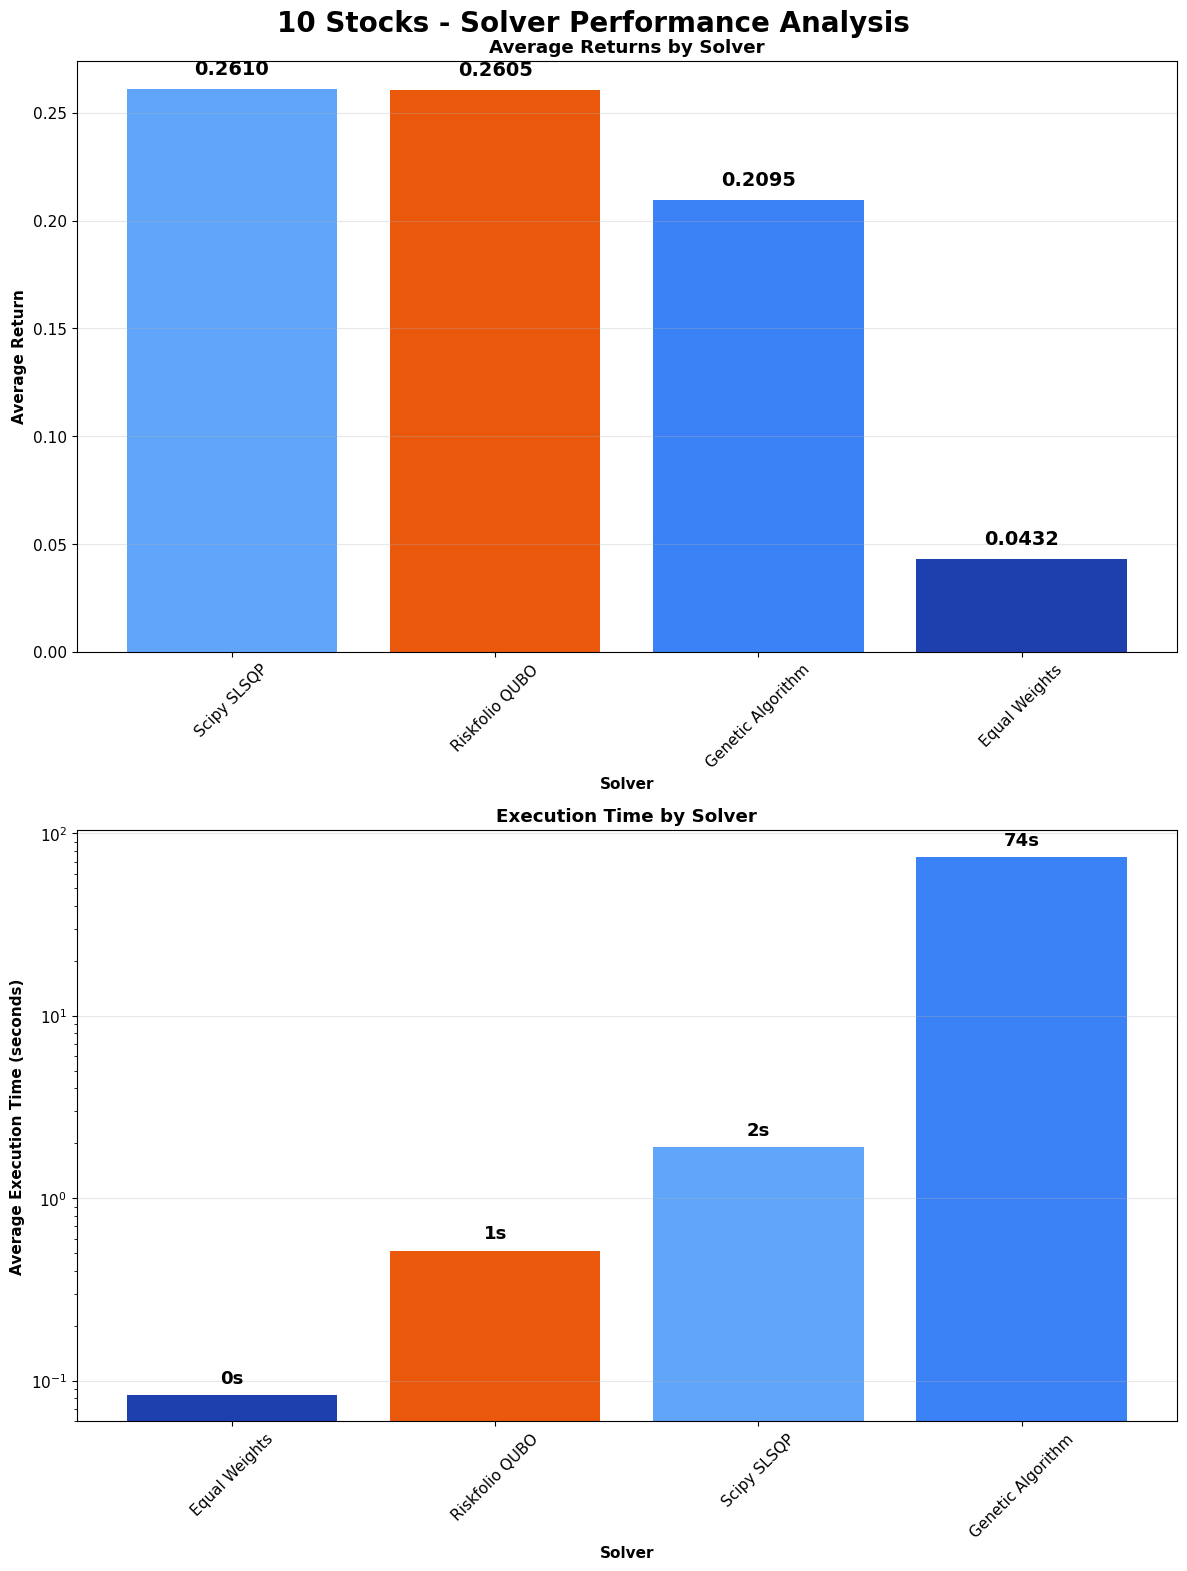

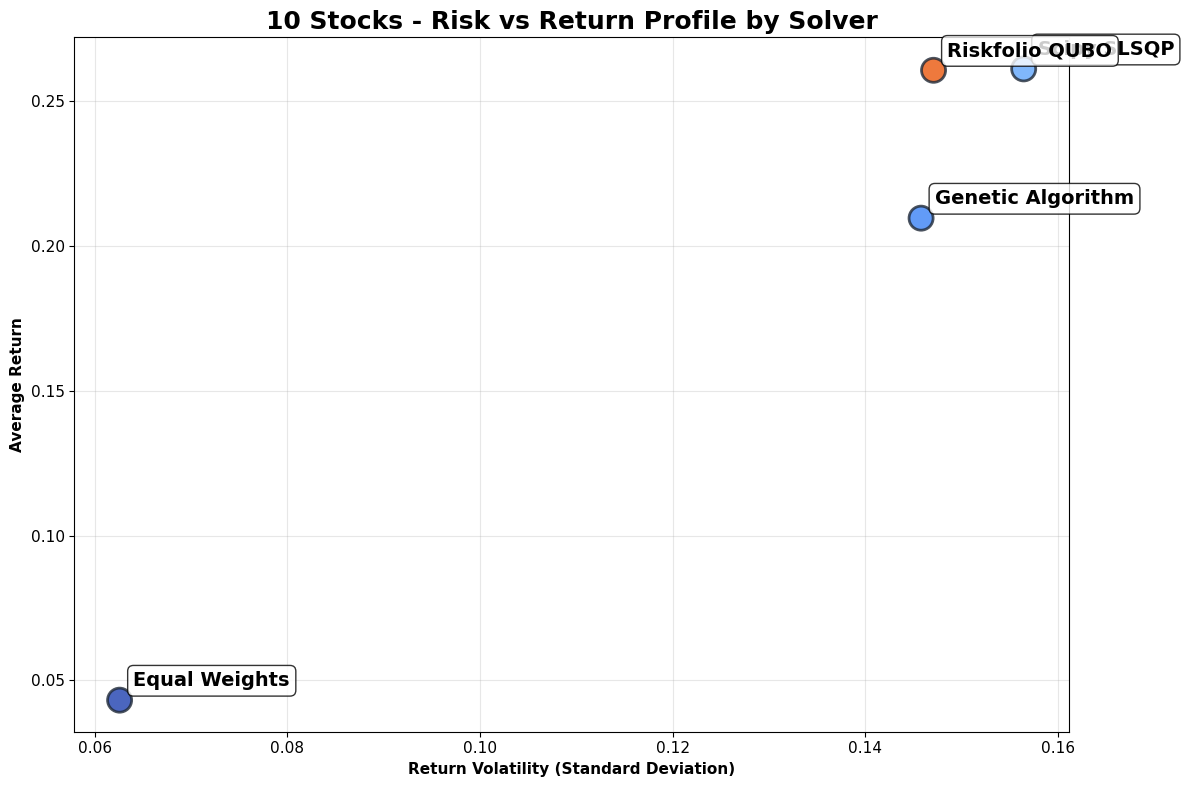

Found weights for Scipy SLSQP: 330 positions, sum=30.000000
Found weights for Riskfolio QUBO: 52 positions, sum=29.999998
Found weights for Equal Weights: 330 positions, sum=30.000000
Found weights for Genetic Algorithm: 330 positions, sum=30.000000

10 Stocks - Weight Distribution Analysis:

Scipy SLSQP:
  Total positions: 3300
  Mean weight: 0.090909 (9.0909%)
  Std weight: 0.245230
  Min weight: 0.001000
  Max weight: 0.990000 (99.0000%)
  Median weight: 0.001000
  Top 5 positions: 4.9500 (495.00%)
  Top 10 positions: 9.9000 (990.00%)
  Top 20 positions: 19.8000 (1980.00%)

Riskfolio QUBO:
  Total positions: 458
  Mean weight: 0.655022 (65.5022%)
  Std weight: 0.347572
  Min weight: 0.000001
  Max weight: 1.000000 (100.0000%)
  Median weight: 0.737952
  Top 5 positions: 5.0000 (500.00%)
  Top 10 positions: 10.0000 (1000.00%)
  Top 20 positions: 20.0000 (2000.00%)

Equal Weights:
  Total positions: 3300
  Mean weight: 0.090909 (9.0909%)
  Std weight: 0.000000
  Min weight: 0.090909
 

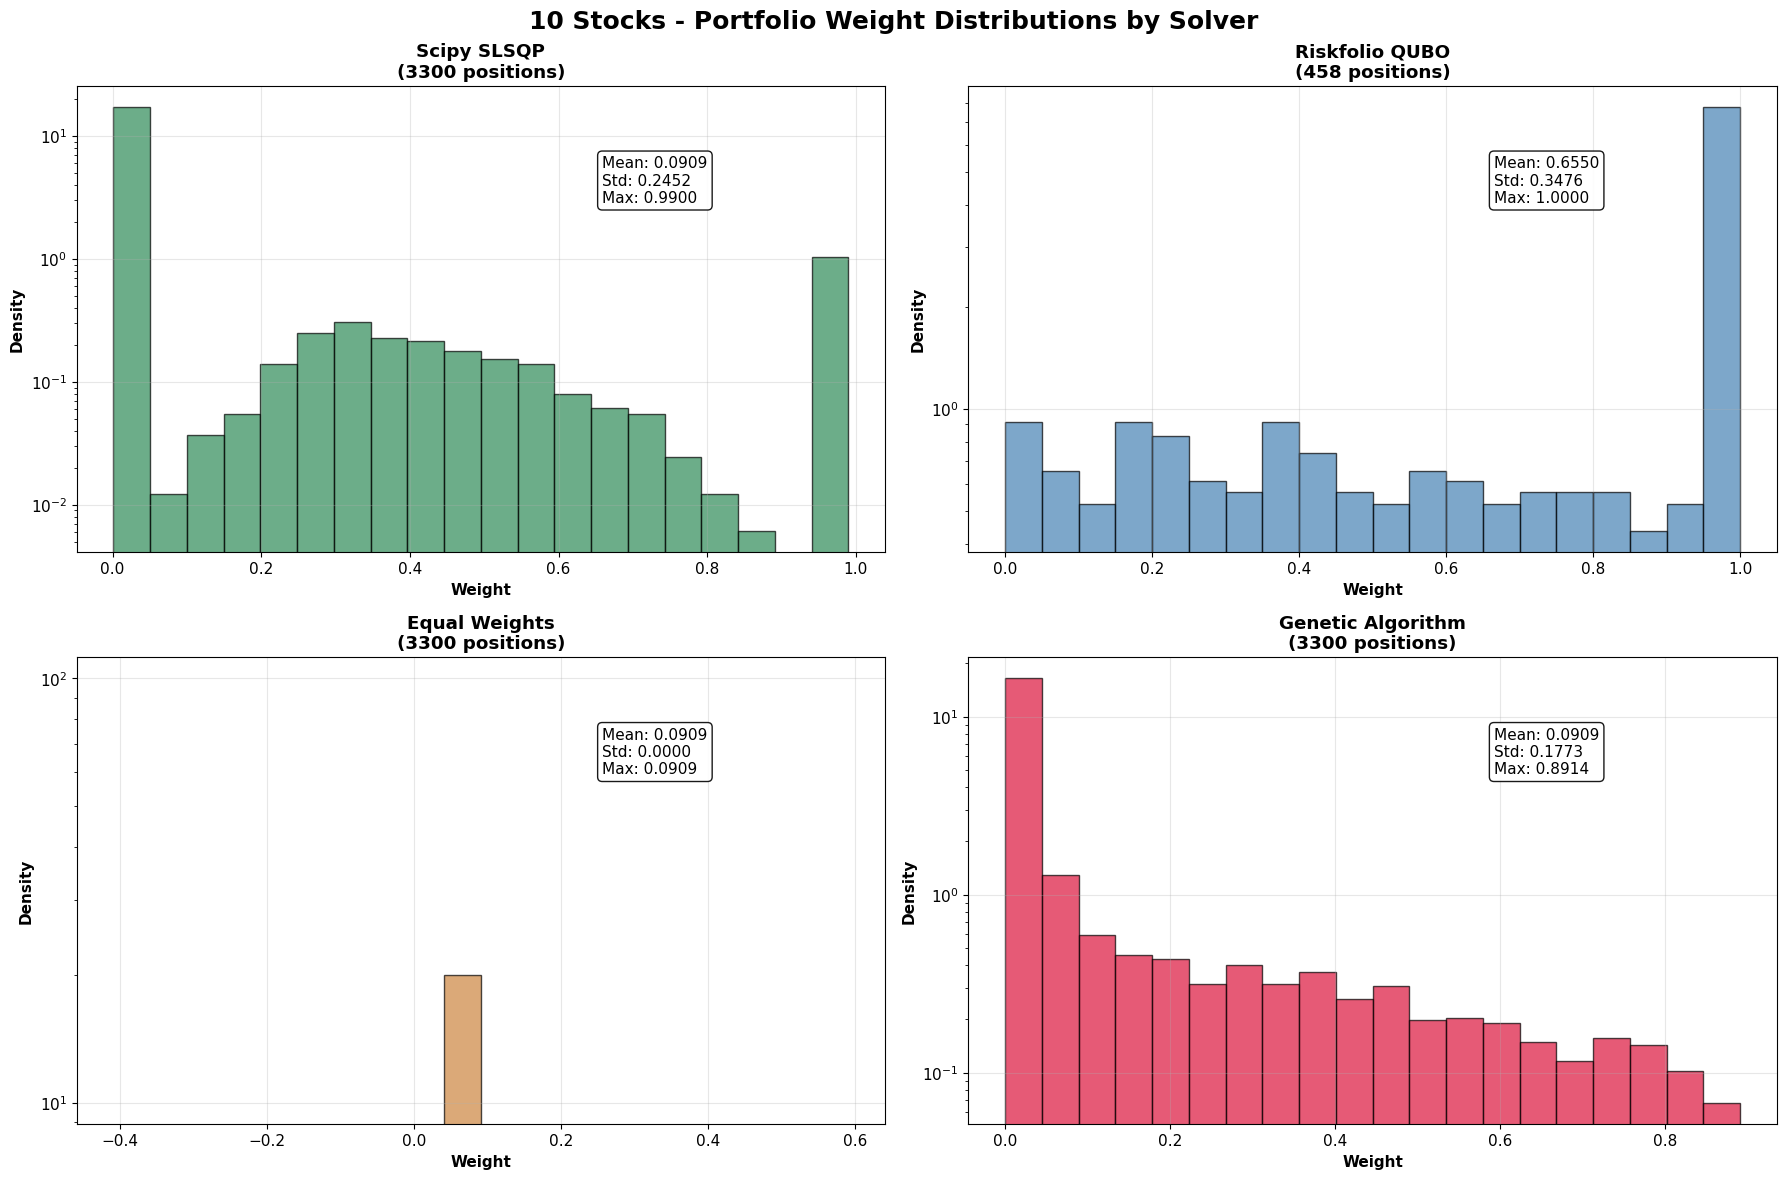

In [29]:
# Performance analysis for 10 stocks
stats_10 = analyze_performance(df_10_stocks, "10 Stocks")
if stats_10 is not None:
    print("\n10 Stocks Performance Summary:")
    print("-" * 50)
    stats_10_sorted = stats_10.sort_values('Avg_Return', ascending=False)
    print(stats_10_sorted.to_string(index=False))
    
    print(f"\nBest performer: {stats_10_sorted.iloc[0]['Solver']} (avg return: {stats_10_sorted.iloc[0]['Avg_Return']:.4f})")
    print(f"Fastest solver: {stats_10.loc[stats_10['Avg_Time'].idxmin(), 'Solver']} ({stats_10['Avg_Time'].min():.2f}s)")
    print(f"Most reliable: {stats_10.loc[stats_10['Success_Rate'].idxmax(), 'Solver']} ({stats_10['Success_Rate'].max():.1f}%)")

    # Create barplot showing average returns for each solver in 10 stocks dataset
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 16))
    fig.suptitle('10 Stocks - Solver Performance Analysis', fontsize=20, fontweight='bold')
    
    # Define consistent color mapping for solvers using blue and orange hues
    solver_colors = {
        'Equal Weights': '#1E40AF',      # Deep blue
        'Genetic Algorithm': '#3B82F6',  # Medium blue
        'Scipy SLSQP': '#60A5FA',        # Light blue
        'Riskfolio QUBO': '#EA580C',     # Deep orange
        'D-Wave CQM': '#FB923C'          # Light orange
    }
    
    # 1. Average Returns Barplot
    stats_10_sorted = stats_10.sort_values('Avg_Return', ascending=False)
    colors_returns = [solver_colors.get(solver, '#1E40AF') for solver in stats_10_sorted['Solver']]
    bars = ax1.bar(stats_10_sorted['Solver'], stats_10_sorted['Avg_Return'], 
                   color=colors_returns)
    
    ax1.set_xlabel('Solver', fontweight='bold')
    ax1.set_ylabel('Average Return', fontweight='bold')
    ax1.set_title('Average Returns by Solver', fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, value in zip(bars, stats_10_sorted['Avg_Return']):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{value:.4f}',
                ha='center', va='bottom', fontweight='bold', fontsize=14)
    
    # 2. Execution Time Comparison (same solvers, same colors)
    stats_10_time = stats_10.sort_values('Avg_Time', ascending=True)
    colors_time = [solver_colors.get(solver, '#1E40AF') for solver in stats_10_time['Solver']]
    bars2 = ax2.bar(stats_10_time['Solver'], stats_10_time['Avg_Time'], 
                    color=colors_time)
    
    ax2.set_xlabel('Solver', fontweight='bold')
    ax2.set_ylabel('Average Execution Time (seconds)', fontweight='bold')
    ax2.set_title('Execution Time by Solver', fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_yscale('log')  # Log scale due to large differences
    
    # Add value labels on bars
    for bar, value in zip(bars2, stats_10_time['Avg_Time']):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height * 1.1,
                f'{value:.0f}s',
                ha='center', va='bottom', fontweight='bold', fontsize=13)
    
    plt.tight_layout()
    plt.show()
    
    # Additional risk-return analysis for 10 stocks dataset
    plt.figure(figsize=(12, 8))
    colors_scatter = [solver_colors.get(solver, '#1E40AF') for solver in stats_10['Solver']]
    scatter = plt.scatter(stats_10['Std_Return'], stats_10['Avg_Return'], 
                         s=300, alpha=0.8, c=colors_scatter, 
                         edgecolors='#1F2937', linewidth=2)
    
    for i, row in stats_10.iterrows():
        plt.annotate(row['Solver'], 
                    (row['Std_Return'], row['Avg_Return']),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=14, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
    
    plt.xlabel('Return Volatility (Standard Deviation)', fontweight='bold')
    plt.ylabel('Average Return', fontweight='bold')
    plt.title('10 Stocks - Risk vs Return Profile by Solver', fontsize=18, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Weight Distribution Analysis for 10 Stocks using the new function
    plot_weight_distribution_histograms(df_10_stocks, "10 Stocks", bins=20)

else:
    print("No valid data available for 10 stocks analysis")

## 100 Stocks Analysis

This section provides detailed analysis of the 100 stocks dataset, comparing the performance of different QUBO solvers.

In [30]:
# Overview of all datasets
print("=" * 100)
print("COMPREHENSIVE OVERVIEW - ALL DATASETS AND SOLVERS")
print("=" * 100)

for dataset in sorted(df_results['dataset'].unique()):
    dataset_data = df_results[df_results['dataset'] == dataset]
    dataset_name = dataset_info.get(dataset, dataset)
    
    print(f"\n{dataset_name}:")
    print("-" * 50)
    
    stats = analyze_performance(dataset_data, dataset_name)
    if stats is not None:
        stats_sorted = stats.sort_values('Avg_Return', ascending=False)
        for _, row in stats_sorted.iterrows():
            print(f"{row['Solver']:<20}: Return={row['Avg_Return']:>8.4f}, Time={row['Avg_Time']:>8.2f}s, Success={row['Success_Rate']:>6.1f}%")
    else:
        print("  No valid results found")

# Create dataset comparison
dataset_comparison = []
for dataset in sorted(df_results['dataset'].unique()):
    dataset_data = df_results[df_results['dataset'] == dataset]
    valid_data = dataset_data[dataset_data['final_return'].notna()]
    
    if len(valid_data) > 0:
        dataset_comparison.append({
            'Dataset': dataset_info.get(dataset, dataset),
            'Total_Results': len(dataset_data),
            'Valid_Results': len(valid_data),
            'Avg_Return': valid_data['final_return'].mean(),
            'Avg_Execution_Time': valid_data['execution_time'].mean(),
            'Success_Rate': len(valid_data) / len(dataset_data) * 100
        })

if dataset_comparison:
    df_comparison = pd.DataFrame(dataset_comparison)
    print("\n" + "=" * 80)
    print("DATASET COMPARISON SUMMARY")
    print("=" * 80)
    print(df_comparison.round(4).to_string(index=False))

COMPREHENSIVE OVERVIEW - ALL DATASETS AND SOLVERS

10 Stocks:
--------------------------------------------------

Analyzing performance for 10 Stocks...
Scipy SLSQP         : Return=  0.2610, Time=    1.90s, Success= 100.0%
Riskfolio QUBO      : Return=  0.2605, Time=    0.52s, Success= 100.0%
Genetic Algorithm   : Return=  0.2095, Time=   73.92s, Success= 100.0%
Equal Weights       : Return=  0.0432, Time=    0.08s, Success= 100.0%

100 Stocks:
--------------------------------------------------

Analyzing performance for 100 Stocks...
Riskfolio QUBO      : Return=  0.3198, Time=    2.53s, Success= 100.0%
Scipy SLSQP         : Return=  0.2953, Time=   45.83s, Success= 100.0%
Genetic Algorithm   : Return=  0.1264, Time=  166.42s, Success= 100.0%
Equal Weights       : Return=  0.0361, Time=    0.07s, Success= 100.0%

439 Stocks (Full):
--------------------------------------------------

Analyzing performance for 439 Stocks (Full)...
Riskfolio QUBO      : Return=  0.3263, Time=   32.86s, 

100 STOCKS - DETAILED ANALYSIS
Found 40 results for 100 stocks dataset
Solvers: ['Equal Weights', 'Genetic Algorithm', 'Riskfolio QUBO', 'Scipy SLSQP']
Periods: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Results with valid portfolio returns: 40

Analyzing performance for 100 Stocks...

100 Stocks Performance Summary:
--------------------------------------------------
           Solver  Periods  Avg_Return  Std_Return  Min_Return  Max_Return   Avg_Time  Std_Time  Success_Rate
   Riskfolio QUBO       10    0.319771    0.133805    0.116417    0.517431   2.526699  0.101919         100.0
      Scipy SLSQP       10    0.295275    0.133909    0.114973    0.513792  45.834771  7.574188         100.0
Genetic Algorithm       10    0.126425    0.072779    0.037287    0.286158 166.415861  4.918976         100.0
    Equal Weights       10    0.036126    0.043258   -0.027865    0.094331   0.074614  0.002052       

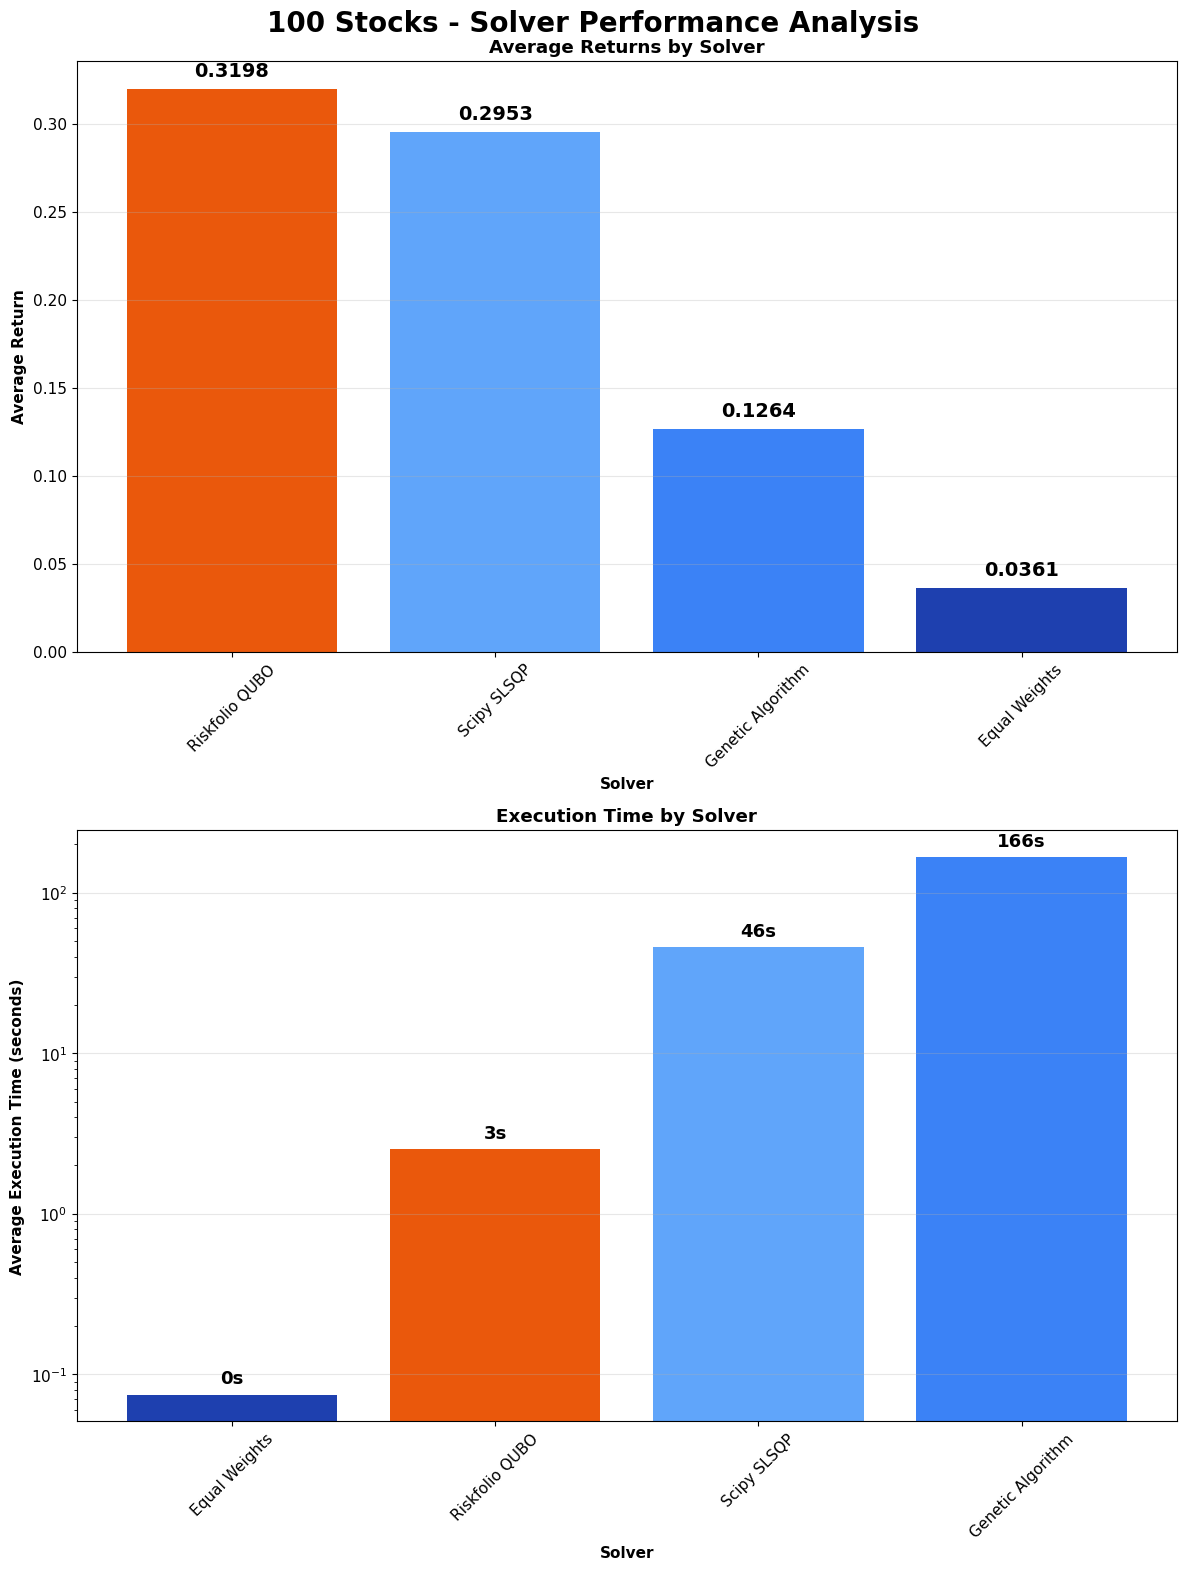

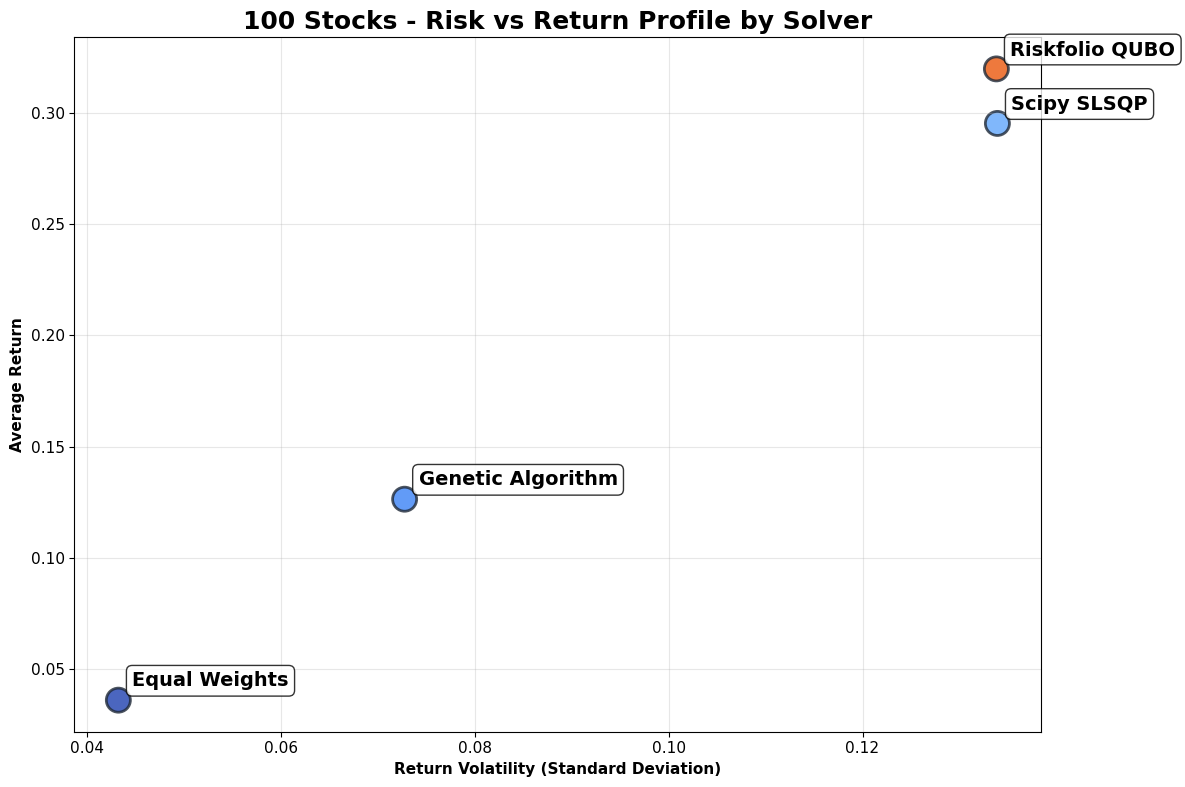

Found weights for Riskfolio QUBO: 64 positions, sum=29.999999
Found weights for Scipy SLSQP: 3030 positions, sum=30.000000
Found weights for Equal Weights: 3030 positions, sum=30.000000
Found weights for Genetic Algorithm: 3030 positions, sum=30.000000

100 Stocks - Weight Distribution Analysis:

Riskfolio QUBO:
  Total positions: 489
  Mean weight: 0.613497 (61.3497%)
  Std weight: 0.346067
  Min weight: 0.000004
  Max weight: 1.000000 (100.0000%)
  Median weight: 0.613024
  Top 5 positions: 5.0000 (500.00%)
  Top 10 positions: 10.0000 (1000.00%)
  Top 20 positions: 20.0000 (2000.00%)

Scipy SLSQP:
  Total positions: 30300
  Mean weight: 0.009901 (0.9901%)
  Std weight: 0.079448
  Min weight: 0.001000
  Max weight: 0.900000 (90.0000%)
  Median weight: 0.001000
  Top 5 positions: 4.5000 (450.00%)
  Top 10 positions: 9.0000 (900.00%)
  Top 20 positions: 18.0000 (1800.00%)

Equal Weights:
  Total positions: 30300
  Mean weight: 0.009901 (0.9901%)
  Std weight: 0.000000
  Min weight: 0.00

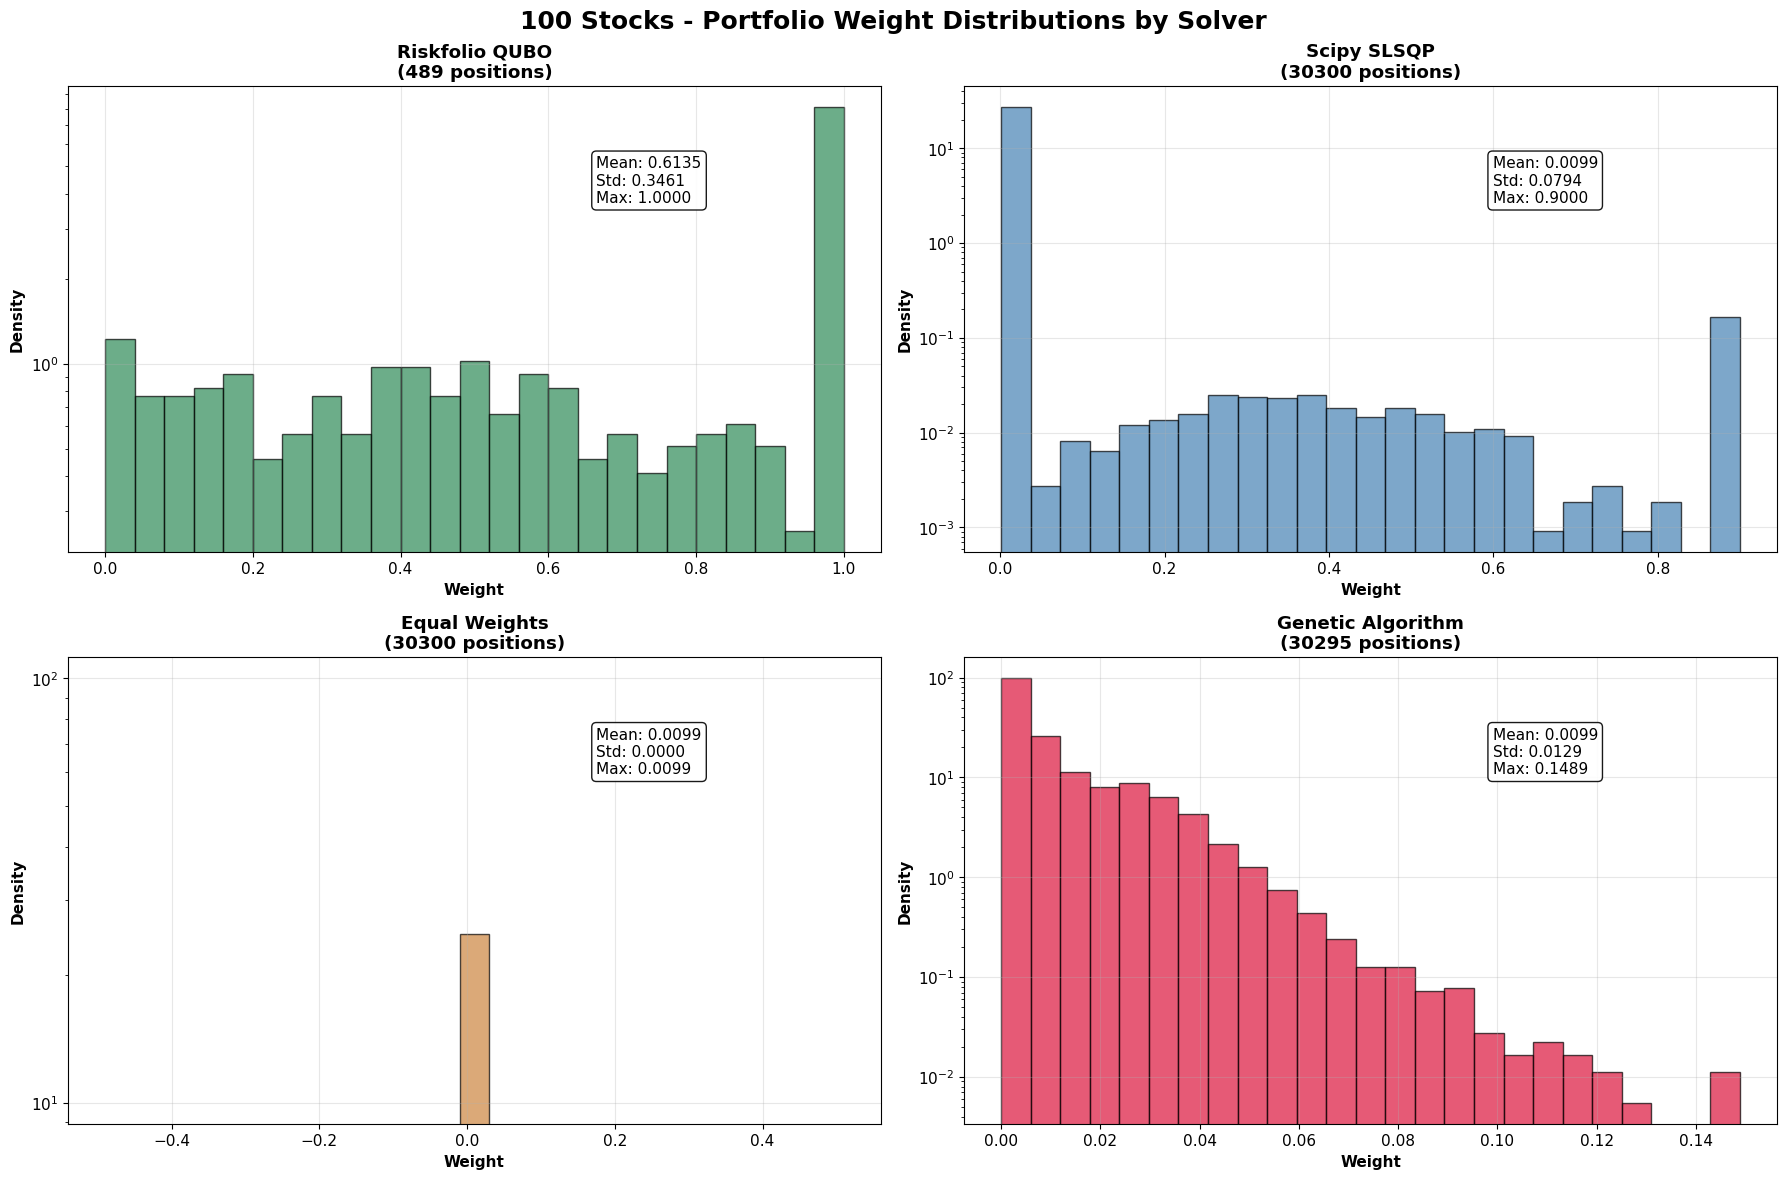

In [31]:
# Filter for 100 stocks results
df_100_stocks = df_results[df_results['dataset'] == '100'].copy()

print("=" * 80)
print("100 STOCKS - DETAILED ANALYSIS")
print("=" * 80)

print(f"Found {len(df_100_stocks)} results for 100 stocks dataset")
print(f"Solvers: {sorted(df_100_stocks['solver_name'].unique())}")
print(f"Periods: {sorted(df_100_stocks['period'].unique())}")

# Check data availability
valid_results_100 = df_100_stocks[df_100_stocks['final_return'].notna()]
print(f"Results with valid portfolio returns: {len(valid_results_100)}")

# Performance analysis for 100 stocks dataset
stats_100 = analyze_performance(df_100_stocks, "100 Stocks")
if stats_100 is not None:
    print("\n100 Stocks Performance Summary:")
    print("-" * 50)
    stats_100_sorted = stats_100.sort_values('Avg_Return', ascending=False)
    print(stats_100_sorted.to_string(index=False))
    
    print(f"\nBest performer: {stats_100_sorted.iloc[0]['Solver']} (avg return: {stats_100_sorted.iloc[0]['Avg_Return']:.4f})")
    print(f"Fastest solver: {stats_100.loc[stats_100['Avg_Time'].idxmin(), 'Solver']} ({stats_100['Avg_Time'].min():.2f}s)")
    print(f"Most reliable: {stats_100.loc[stats_100['Success_Rate'].idxmax(), 'Solver']} ({stats_100['Success_Rate'].max():.1f}%)")

    # Create barplot showing average returns for each solver in 100 stocks dataset
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 16))
    fig.suptitle('100 Stocks - Solver Performance Analysis', fontsize=20, fontweight='bold')
    
    # Define consistent color mapping for solvers using blue and orange hues
    solver_colors = {
        'Equal Weights': '#1E40AF',      # Deep blue
        'Genetic Algorithm': '#3B82F6',  # Medium blue
        'Scipy SLSQP': '#60A5FA',        # Light blue
        'Riskfolio QUBO': '#EA580C',     # Deep orange
        'D-Wave CQM': '#FB923C'          # Light orange
    }
    
    # 1. Average Returns Barplot
    stats_100_sorted = stats_100.sort_values('Avg_Return', ascending=False)
    colors_returns = [solver_colors.get(solver, '#1E40AF') for solver in stats_100_sorted['Solver']]
    bars = ax1.bar(stats_100_sorted['Solver'], stats_100_sorted['Avg_Return'], 
                   color=colors_returns)
    
    ax1.set_xlabel('Solver', fontweight='bold')
    ax1.set_ylabel('Average Return', fontweight='bold')
    ax1.set_title('Average Returns by Solver', fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, value in zip(bars, stats_100_sorted['Avg_Return']):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{value:.4f}',
                ha='center', va='bottom', fontweight='bold', fontsize=14)
    
    # 2. Execution Time Comparison (same solvers, same colors)
    stats_100_time = stats_100.sort_values('Avg_Time', ascending=True)
    colors_time = [solver_colors.get(solver, '#1E40AF') for solver in stats_100_time['Solver']]
    bars2 = ax2.bar(stats_100_time['Solver'], stats_100_time['Avg_Time'], 
                    color=colors_time)
    
    ax2.set_xlabel('Solver', fontweight='bold')
    ax2.set_ylabel('Average Execution Time (seconds)', fontweight='bold')
    ax2.set_title('Execution Time by Solver', fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_yscale('log')  # Log scale due to large differences
    
    # Add value labels on bars
    for bar, value in zip(bars2, stats_100_time['Avg_Time']):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height * 1.1,
                f'{value:.0f}s',
                ha='center', va='bottom', fontweight='bold', fontsize=13)
    
    plt.tight_layout()
    plt.show()
    
    # Additional risk-return analysis for 100 stocks dataset
    plt.figure(figsize=(12, 8))
    colors_scatter = [solver_colors.get(solver, '#1E40AF') for solver in stats_100['Solver']]
    scatter = plt.scatter(stats_100['Std_Return'], stats_100['Avg_Return'], 
                         s=300, alpha=0.8, c=colors_scatter, 
                         edgecolors='#1F2937', linewidth=2)
    
    for i, row in stats_100.iterrows():
        plt.annotate(row['Solver'], 
                    (row['Std_Return'], row['Avg_Return']),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=14, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
    
    plt.xlabel('Return Volatility (Standard Deviation)', fontweight='bold')
    plt.ylabel('Average Return', fontweight='bold')
    plt.title('100 Stocks - Risk vs Return Profile by Solver', fontsize=18, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Weight Distribution Analysis for 100 Stocks using the new function
    plot_weight_distribution_histograms(df_100_stocks, "100 Stocks", bins=25)

else:
    print("No valid data available for 100 stocks analysis")

In [32]:
# Filter for full dataset results first
df_full = df_results[df_results['dataset'] == 'full'].copy()

# Create solver comparison plots for full dataset across all periods
if len(df_full) > 0:
    print("Creating analysis for full dataset...")
    print(f"Found {len(df_full)} results for full dataset")
    print(f"Solvers: {sorted(df_full['solver_name'].unique())}")
    print(f"Periods: {sorted(df_full['period'].unique())}")
else:
    print("No data available for full dataset comparison")

Creating analysis for full dataset...
Found 50 results for full dataset
Solvers: ['D-Wave CQM', 'Equal Weights', 'Genetic Algorithm', 'Riskfolio QUBO', 'Scipy SLSQP']
Periods: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


FULL DATASET (439 STOCKS) - DETAILED ANALYSIS
Found 50 results for full dataset
Solvers: ['D-Wave CQM', 'Equal Weights', 'Genetic Algorithm', 'Riskfolio QUBO', 'Scipy SLSQP']
Periods: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Results with valid portfolio returns: 50

Analyzing performance for Full Dataset...

Full Dataset Performance Summary:
--------------------------------------------------
           Solver  Periods  Avg_Return  Std_Return  Min_Return  Max_Return    Avg_Time   Std_Time  Success_Rate
   Riskfolio QUBO       10    0.326283    0.185313    0.136920    0.622888   32.856497   1.212175         100.0
      Scipy SLSQP       10    0.219370    0.137066    0.075699    0.461197 1737.847789 273.625496         100.0
Genetic Algorithm       10    0.077606    0.046827    0.021712    0.158042 1831.975170   2.283231         100.0
    Equal Weights       10    0.028768    0.036209   -0.022137    0

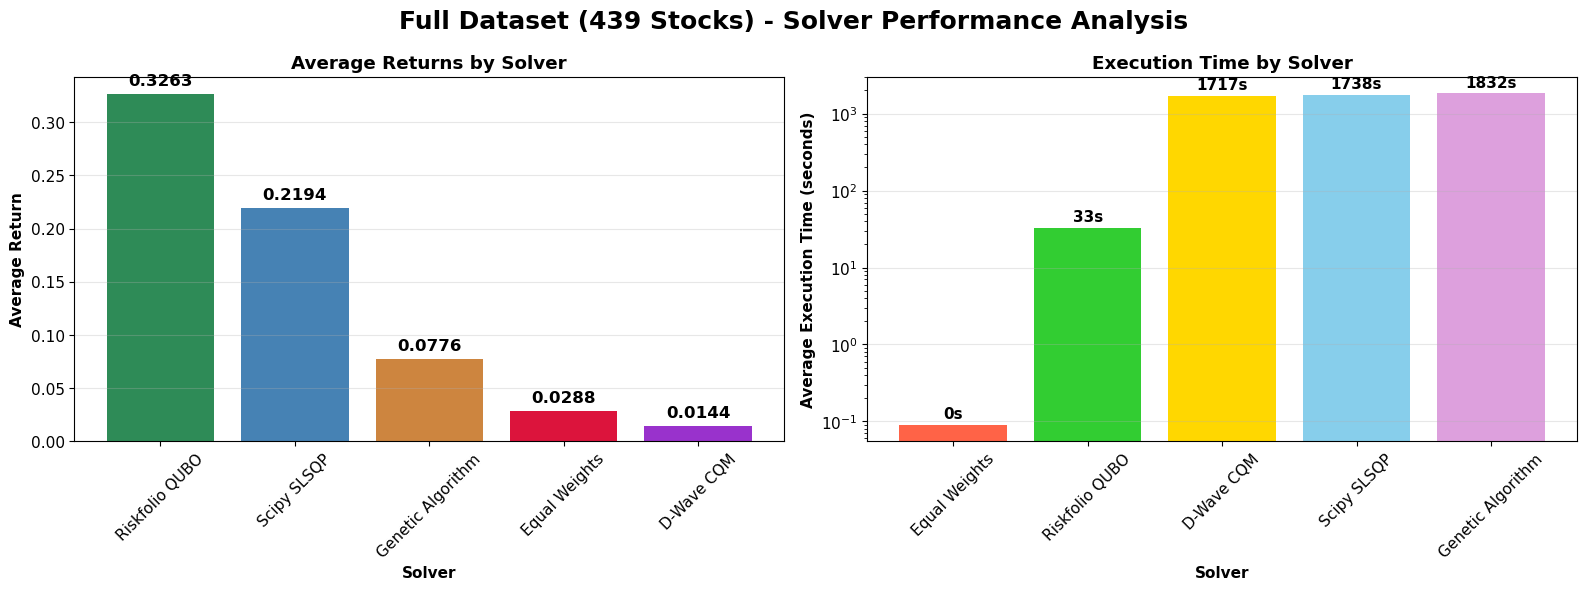

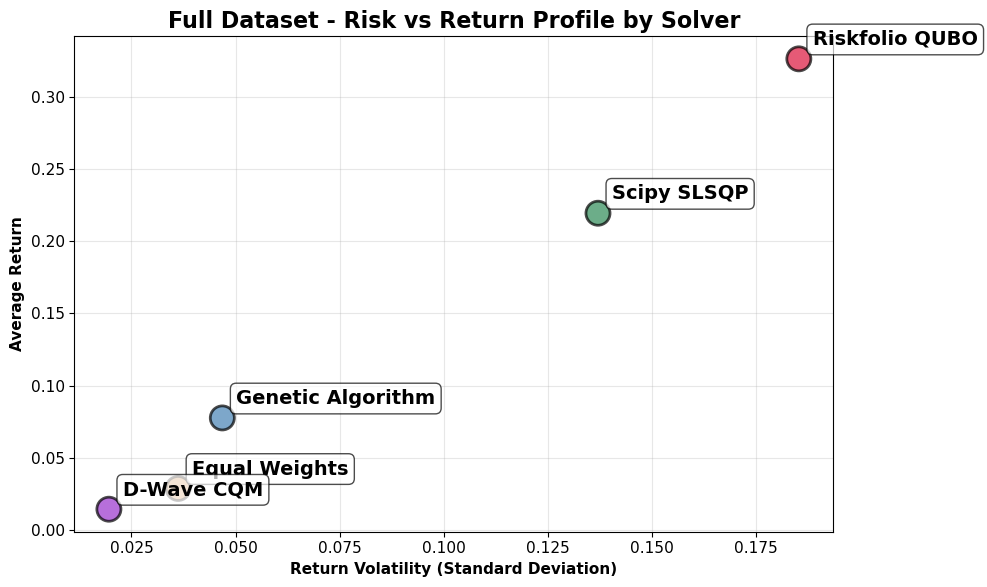

In [33]:
def multi_comparison(solver_configs, n_periods, title_prefix="Portfolio Optimization", show_benchmark=True):
    """
    Compare multiple portfolio optimization solvers across periods.
    
    Args:
        solver_configs (list): List of dictionaries with 'path_template' and 'name' keys
        n_periods (int): Number of periods to compare
        title_prefix (str): Prefix for plot titles
        show_benchmark (bool): Whether to show benchmark comparison
    """
    
    for period in range(n_periods):
        period_data = []
        benchmark_data = None
        
        # Load data for all solvers for this period
        for config in solver_configs:
            path_template = config['path_template']
            solver_name = config['name']
            file_path = path_template.format(period)
            
            try:
                result_data = load_pickle_result(file_path)
                if result_data is not None:
                    portfolio_returns = result_data.get('portfolio_cumulative_returns', [])
                    benchmark_returns = result_data.get('benchmark_cumulative_returns', [])
                    start_date = result_data.get('start_date', 'Unknown')
                    execution_time = result_data.get('total_run_time', 0)
                    
                    # Check if portfolio_returns has data (handle NumPy arrays properly)
                    has_portfolio_data = False
                    if portfolio_returns is not None:
                        try:
                            has_portfolio_data = len(portfolio_returns) > 0
                        except TypeError:
                            # Handle case where portfolio_returns is not a sequence
                            has_portfolio_data = portfolio_returns is not None
                    
                    if has_portfolio_data:
                        period_data.append({
                            'name': solver_name,
                            'portfolio_returns': portfolio_returns,
                            'benchmark_returns': benchmark_returns,
                            'start_date': start_date,
                            'execution_time': execution_time,
                            'file_path': file_path
                        })
                        
                        # Store benchmark from first successful load
                        if benchmark_data is None and benchmark_returns is not None:
                            try:
                                if len(benchmark_returns) > 0:
                                    benchmark_data = benchmark_returns
                            except (TypeError, AttributeError):
                                pass
                        
                        print(f'Period {period}: Loaded {solver_name} (exec_time: {execution_time:.2f}s)')
                    else:
                        print(f'Period {period}: {solver_name} has no portfolio returns data')
                else:
                    print(f'Period {period}: Could not load {solver_name} from {file_path}')
                    
            except Exception as e:
                print(f'Period {period}: Error loading {solver_name} from {file_path}: {e}')
        
        # Plot results if we have any data
        if period_data:
            plt.figure(figsize=(15, 8))
            
            # Color palette for better distinction
            colors = plt.cm.Set1(np.linspace(0, 1, len(period_data)))
            
            # Plot portfolio returns for each solver
            for i, data in enumerate(period_data):
                plt.plot(data['portfolio_returns'], 
                        label=f"{data['name']} (t={data['execution_time']:.1f}s)", 
                        color=colors[i], 
                        linewidth=2, 
                        alpha=0.8)
            
            # Plot benchmark if available and requested
            if show_benchmark and benchmark_data is not None:
                plt.plot(benchmark_data, 
                        label='S&P 500 Benchmark', 
                        linestyle='--', 
                        color='black', 
                        linewidth=2, 
                        alpha=0.7)
            
            plt.title(f'{title_prefix} Comparison - Period {period}\n'
                     f'Start Date: {period_data[0]["start_date"]} | Solvers: {len(period_data)}')
            plt.xlabel('Trading Days')
            plt.ylabel('Cumulative Returns')
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            # Print summary statistics
            print(f"\nPeriod {period} Summary:")
            print("-" * 50)
            for data in period_data:
                try:
                    final_return = data['portfolio_returns'][-1] if len(data['portfolio_returns']) > 0 else 0
                except (IndexError, TypeError):
                    final_return = 0
                print(f"{data['name']:<25}: {final_return:>8.4f} ({data['execution_time']:>6.2f}s)")
            if benchmark_data is not None:
                try:
                    benchmark_final = benchmark_data[-1] if len(benchmark_data) > 0 else 0
                except (IndexError, TypeError):
                    benchmark_final = 0
                print(f"{'Benchmark':<25}: {benchmark_final:>8.4f}")
            print()
            
        else:
            print(f'No data available for any solver in period {period}')

print("=" * 80)
print("FULL DATASET (439 STOCKS) - DETAILED ANALYSIS")
print("=" * 80)

print(f"Found {len(df_full)} results for full dataset")
print(f"Solvers: {sorted(df_full['solver_name'].unique())}")
print(f"Periods: {sorted(df_full['period'].unique())}")

# Check data availability
valid_results_full = df_full[df_full['final_return'].notna()]
print(f"Results with valid portfolio returns: {len(valid_results_full)}")

# Performance analysis for full dataset
stats_full = analyze_performance(df_full, "Full Dataset")
if stats_full is not None:
    print("\nFull Dataset Performance Summary:")
    print("-" * 50)
    stats_full_sorted = stats_full.sort_values('Avg_Return', ascending=False)
    print(stats_full_sorted.to_string(index=False))
    
    print(f"\nBest performer: {stats_full_sorted.iloc[0]['Solver']} (avg return: {stats_full_sorted.iloc[0]['Avg_Return']:.4f})")
    print(f"Fastest solver: {stats_full.loc[stats_full['Avg_Time'].idxmin(), 'Solver']} ({stats_full['Avg_Time'].min():.2f}s)")
    print(f"Most reliable: {stats_full.loc[stats_full['Success_Rate'].idxmax(), 'Solver']} ({stats_full['Success_Rate'].max():.1f}%)")

    # Create barplot showing average returns for each solver in full dataset
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Full Dataset (439 Stocks) - Solver Performance Analysis', fontsize=18, fontweight='bold')
    
    # 1. Average Returns Barplot
    stats_full_sorted = stats_full.sort_values('Avg_Return', ascending=False)
    bars = ax1.bar(stats_full_sorted['Solver'], stats_full_sorted['Avg_Return'], 
                   color=['#2E8B57', '#4682B4', '#CD853F', '#DC143C', '#9932CC'][:len(stats_full_sorted)])
    
    ax1.set_xlabel('Solver', fontweight='bold')
    ax1.set_ylabel('Average Return', fontweight='bold')
    ax1.set_title('Average Returns by Solver', fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, value in zip(bars, stats_full_sorted['Avg_Return']):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{value:.4f}',
                ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    # 2. Execution Time Comparison
    stats_full_time = stats_full.sort_values('Avg_Time', ascending=True)
    bars2 = ax2.bar(stats_full_time['Solver'], stats_full_time['Avg_Time'], 
                    color=['#FF6347', '#32CD32', '#FFD700', '#87CEEB', '#DDA0DD'][:len(stats_full_time)])
    
    ax2.set_xlabel('Solver', fontweight='bold')
    ax2.set_ylabel('Average Execution Time (seconds)', fontweight='bold')
    ax2.set_title('Execution Time by Solver', fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_yscale('log')  # Log scale due to large differences
    
    # Add value labels on bars
    for bar, value in zip(bars2, stats_full_time['Avg_Time']):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height * 1.1,
                f'{value:.0f}s',
                ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    # Additional risk-return analysis for full dataset
    plt.figure(figsize=(10, 6))
    colors = ['#2E8B57', '#4682B4', '#CD853F', '#DC143C', '#9932CC'][:len(stats_full)]
    scatter = plt.scatter(stats_full['Std_Return'], stats_full['Avg_Return'], 
                         s=300, alpha=0.7, c=colors, edgecolors='black', linewidth=2)
    
    for i, row in stats_full.iterrows():
        plt.annotate(row['Solver'], 
                    (row['Std_Return'], row['Avg_Return']),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=14, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7))
    
    plt.xlabel('Return Volatility (Standard Deviation)', fontweight='bold')
    plt.ylabel('Average Return', fontweight='bold')
    plt.title('Full Dataset - Risk vs Return Profile by Solver', fontsize=16, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print("No valid data available for full dataset analysis")

## Full Dataset Analysis (439 Stocks)

This section provides detailed analysis of the full dataset containing 439 stocks, comparing the performance of different QUBO solvers.


FULL DATASET - MULTI-PERIOD SOLVER COMPARISON INCLUDING CQM
Running comparison across 10 periods: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Period 0: Loaded Equal Weights (exec_time: 0.10s)
Period 0: Loaded Genetic Algorithm (exec_time: 1831.56s)
Period 0: Loaded Scipy SLSQP (exec_time: 1486.65s)
Period 0: Loaded Riskfolio QUBO (exec_time: 32.63s)
Period 0: Loaded D-Wave CQM (exec_time: 813.60s)


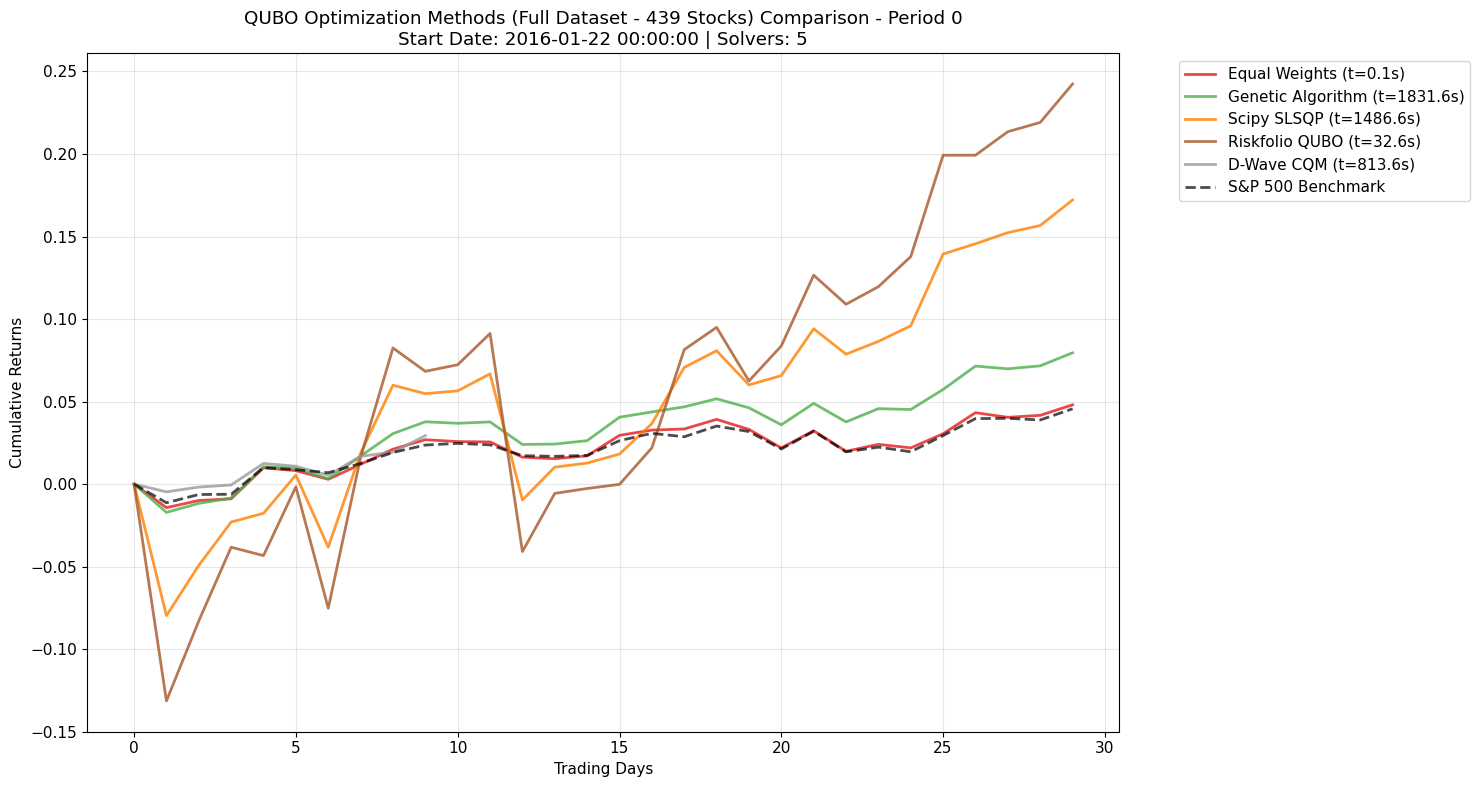


Period 0 Summary:
--------------------------------------------------
Equal Weights            :   0.0480 (  0.10s)
Genetic Algorithm        :   0.0795 (1831.56s)
Scipy SLSQP              :   0.1721 (1486.65s)
Riskfolio QUBO           :   0.2424 ( 32.63s)
D-Wave CQM               :   0.0293 (813.60s)
Benchmark                :   0.0456

Period 1: Loaded Equal Weights (exec_time: 0.09s)
Period 1: Loaded Genetic Algorithm (exec_time: 1831.29s)
Period 1: Loaded Scipy SLSQP (exec_time: 1919.28s)
Period 1: Loaded Riskfolio QUBO (exec_time: 31.24s)
Period 1: Loaded D-Wave CQM (exec_time: 1548.03s)


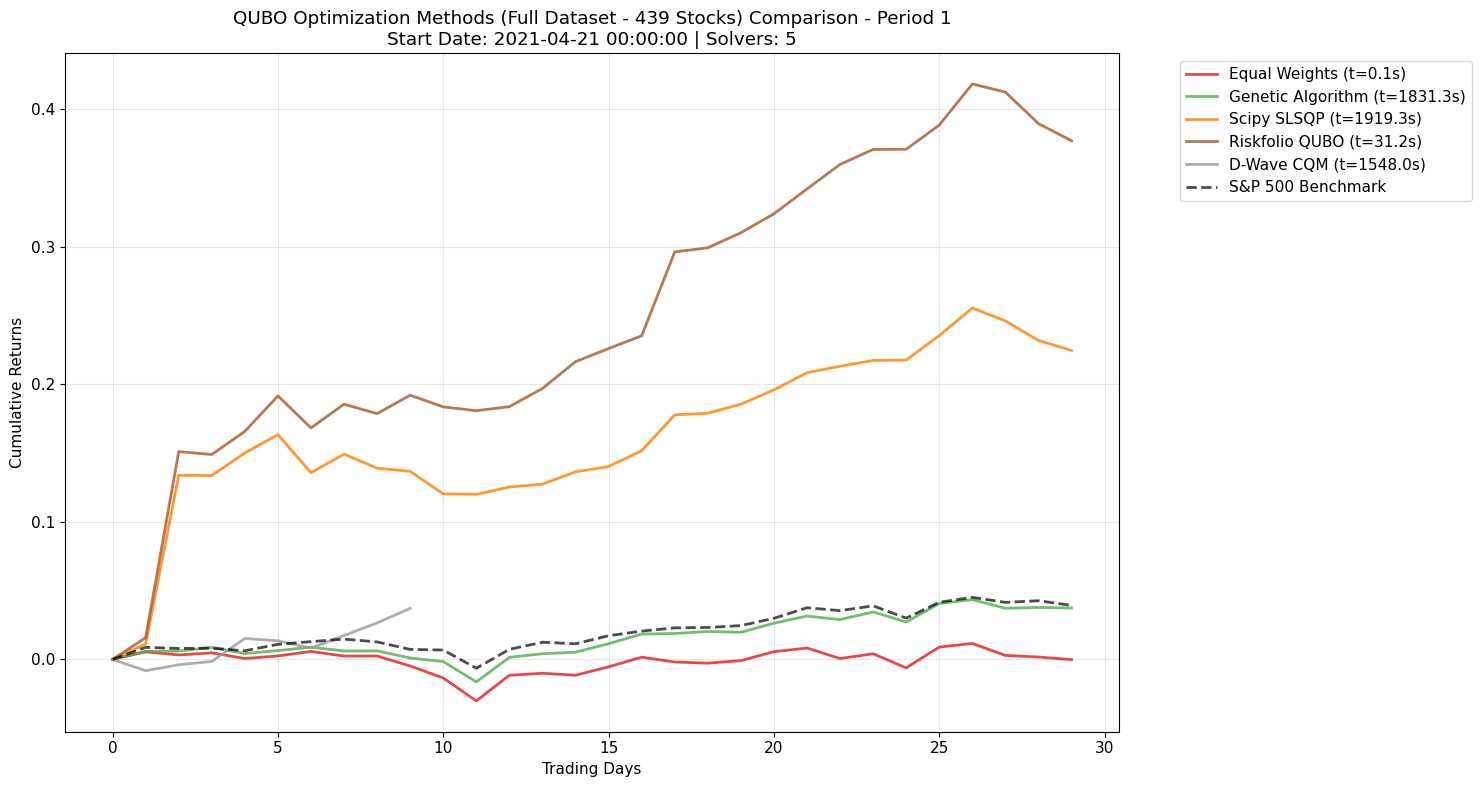


Period 1 Summary:
--------------------------------------------------
Equal Weights            :  -0.0001 (  0.09s)
Genetic Algorithm        :   0.0374 (1831.29s)
Scipy SLSQP              :   0.2246 (1919.28s)
Riskfolio QUBO           :   0.3769 ( 31.24s)
D-Wave CQM               :   0.0371 (1548.03s)
Benchmark                :   0.0392

Period 2: Loaded Equal Weights (exec_time: 0.08s)
Period 2: Loaded Genetic Algorithm (exec_time: 1829.10s)
Period 2: Loaded Scipy SLSQP (exec_time: 1556.18s)
Period 2: Loaded Riskfolio QUBO (exec_time: 32.03s)
Period 2: Loaded D-Wave CQM (exec_time: 2538.99s)


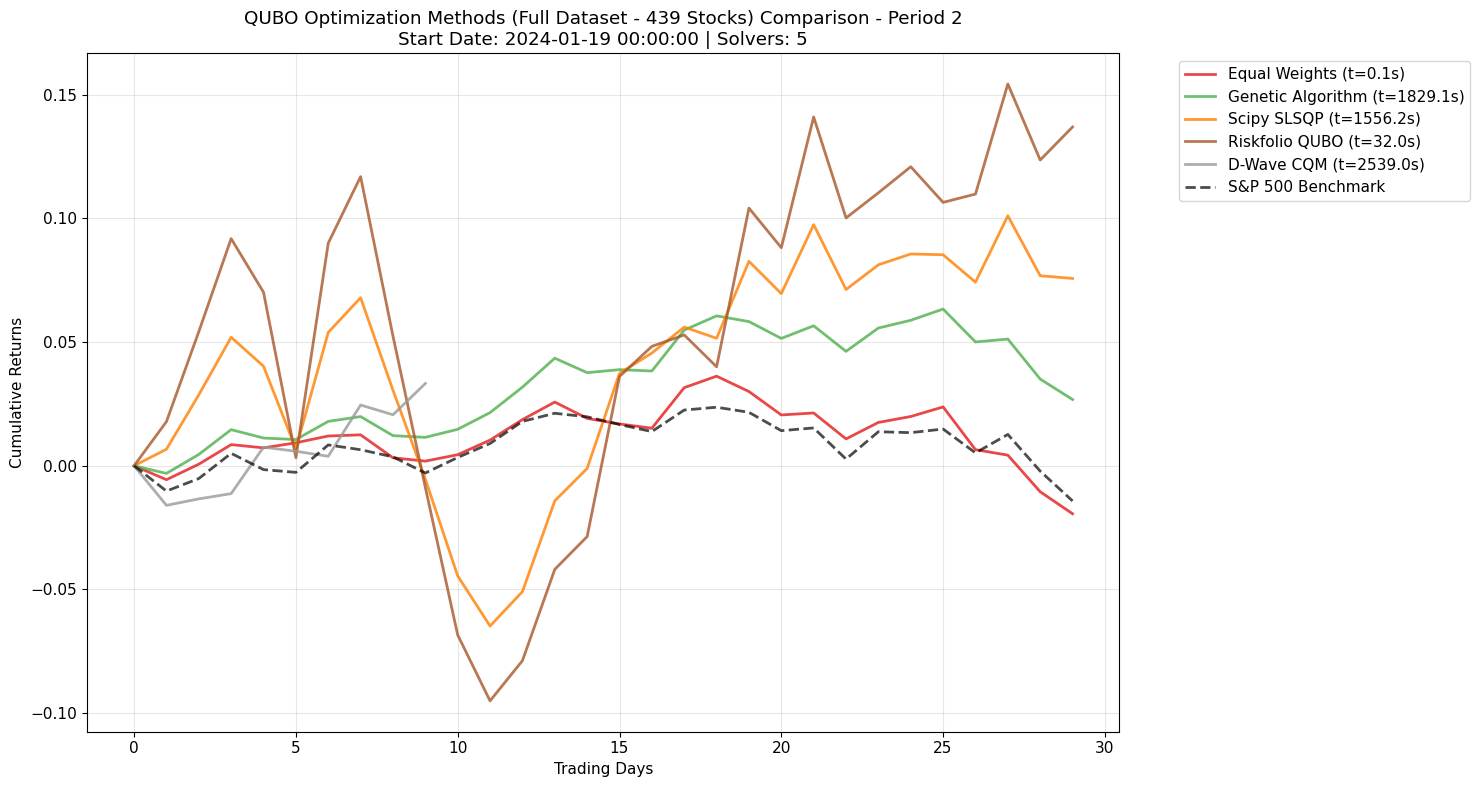


Period 2 Summary:
--------------------------------------------------
Equal Weights            :  -0.0194 (  0.08s)
Genetic Algorithm        :   0.0268 (1829.10s)
Scipy SLSQP              :   0.0757 (1556.18s)
Riskfolio QUBO           :   0.1369 ( 32.03s)
D-Wave CQM               :   0.0332 (2538.99s)
Benchmark                :  -0.0142

Period 3: Loaded Equal Weights (exec_time: 0.08s)
Period 3: Loaded Genetic Algorithm (exec_time: 1832.13s)
Period 3: Loaded Scipy SLSQP (exec_time: 1539.09s)
Period 3: Loaded Riskfolio QUBO (exec_time: 33.79s)
Period 3: Loaded D-Wave CQM (exec_time: 2515.01s)


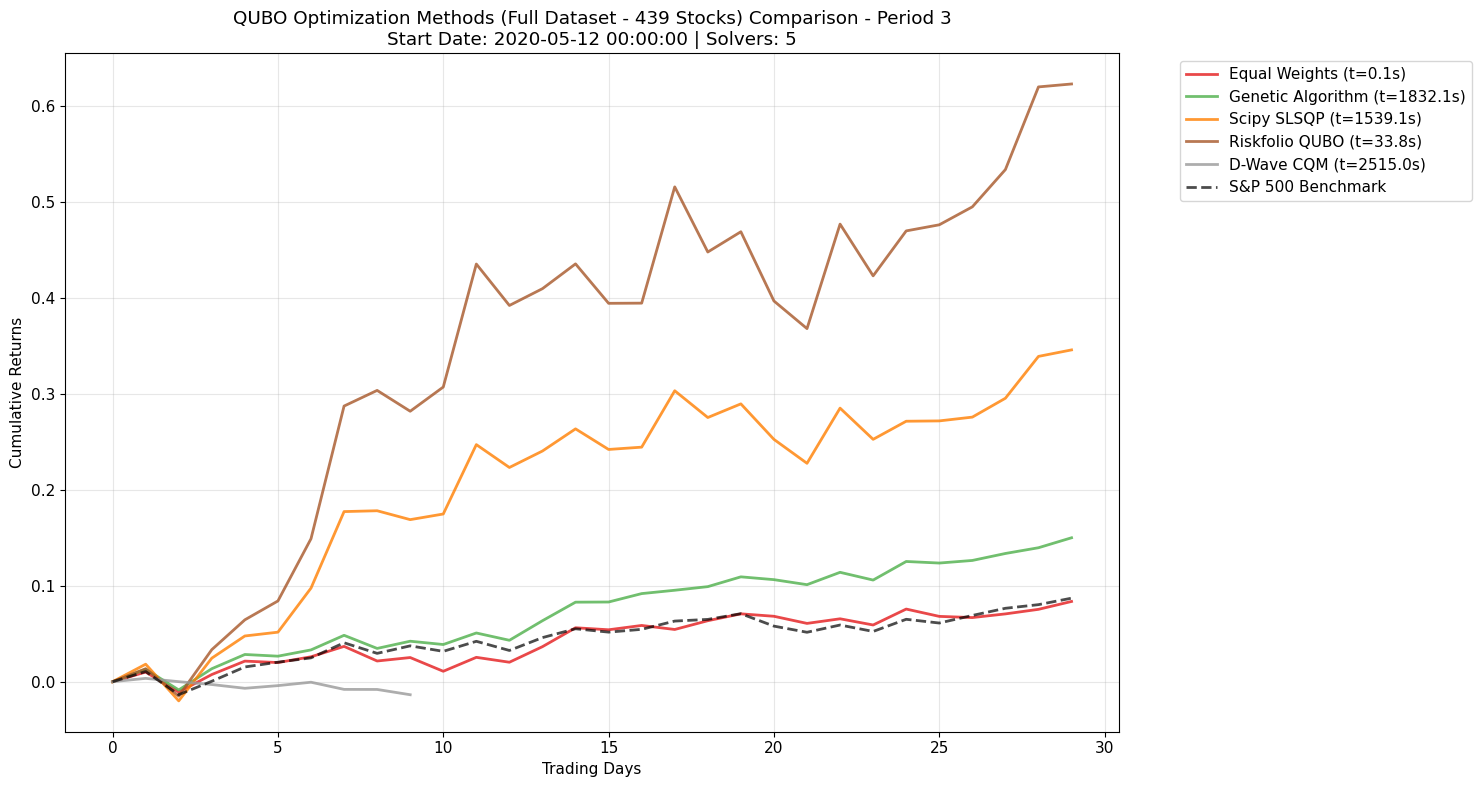


Period 3 Summary:
--------------------------------------------------
Equal Weights            :   0.0836 (  0.08s)
Genetic Algorithm        :   0.1500 (1832.13s)
Scipy SLSQP              :   0.3458 (1539.09s)
Riskfolio QUBO           :   0.6229 ( 33.79s)
D-Wave CQM               :  -0.0136 (2515.01s)
Benchmark                :   0.0870

Period 4: Loaded Equal Weights (exec_time: 0.08s)
Period 4: Loaded Genetic Algorithm (exec_time: 1829.72s)
Period 4: Loaded Scipy SLSQP (exec_time: 1737.52s)
Period 4: Loaded Riskfolio QUBO (exec_time: 31.87s)
Period 4: Loaded D-Wave CQM (exec_time: 1697.87s)


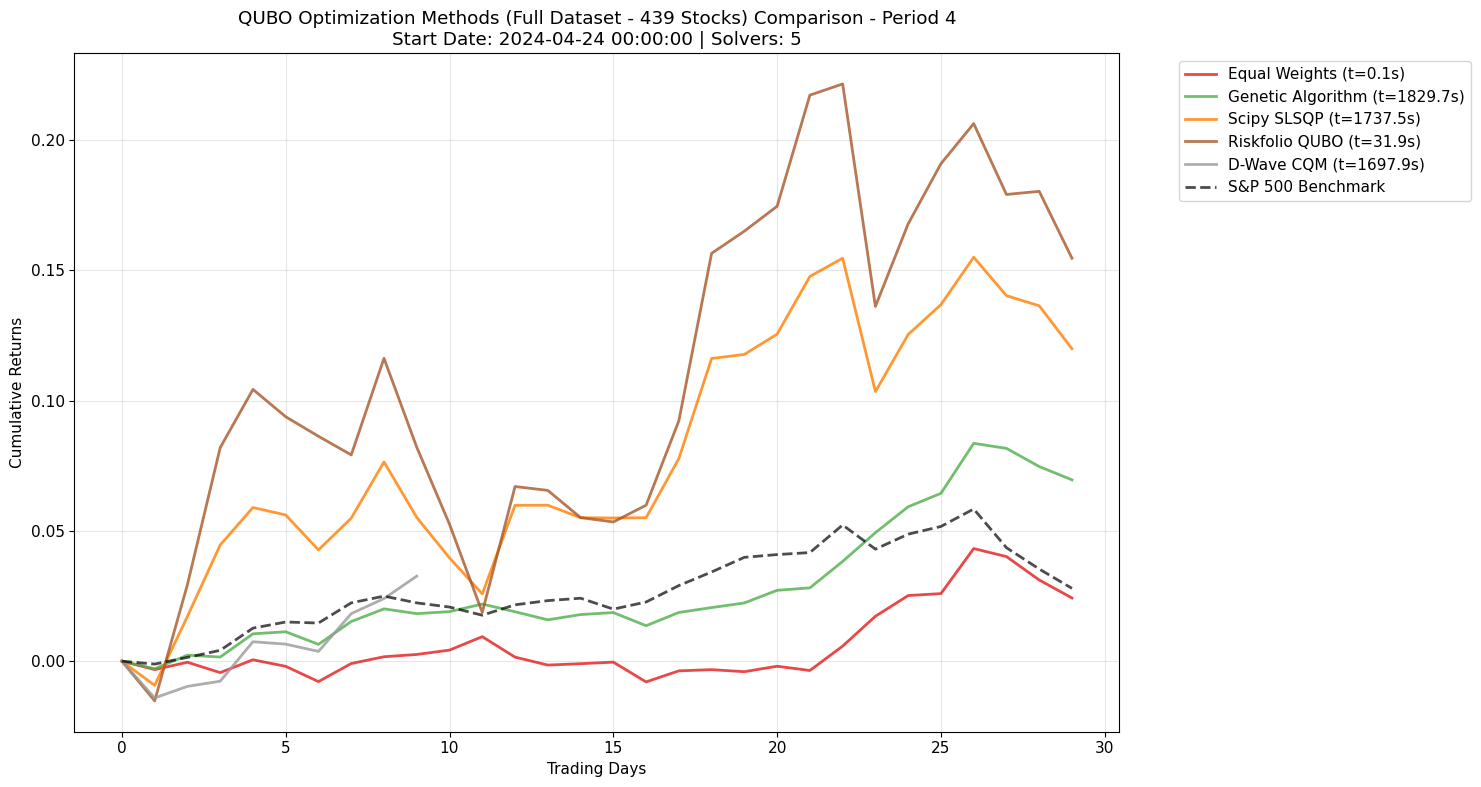


Period 4 Summary:
--------------------------------------------------
Equal Weights            :   0.0243 (  0.08s)
Genetic Algorithm        :   0.0696 (1829.72s)
Scipy SLSQP              :   0.1199 (1737.52s)
Riskfolio QUBO           :   0.1546 ( 31.87s)
D-Wave CQM               :   0.0326 (1697.87s)
Benchmark                :   0.0279

Period 5: Loaded Equal Weights (exec_time: 0.08s)
Period 5: Loaded Genetic Algorithm (exec_time: 1828.71s)
Period 5: Loaded Scipy SLSQP (exec_time: 2041.04s)
Period 5: Loaded Riskfolio QUBO (exec_time: 32.72s)
Period 5: Loaded D-Wave CQM (exec_time: 1594.25s)


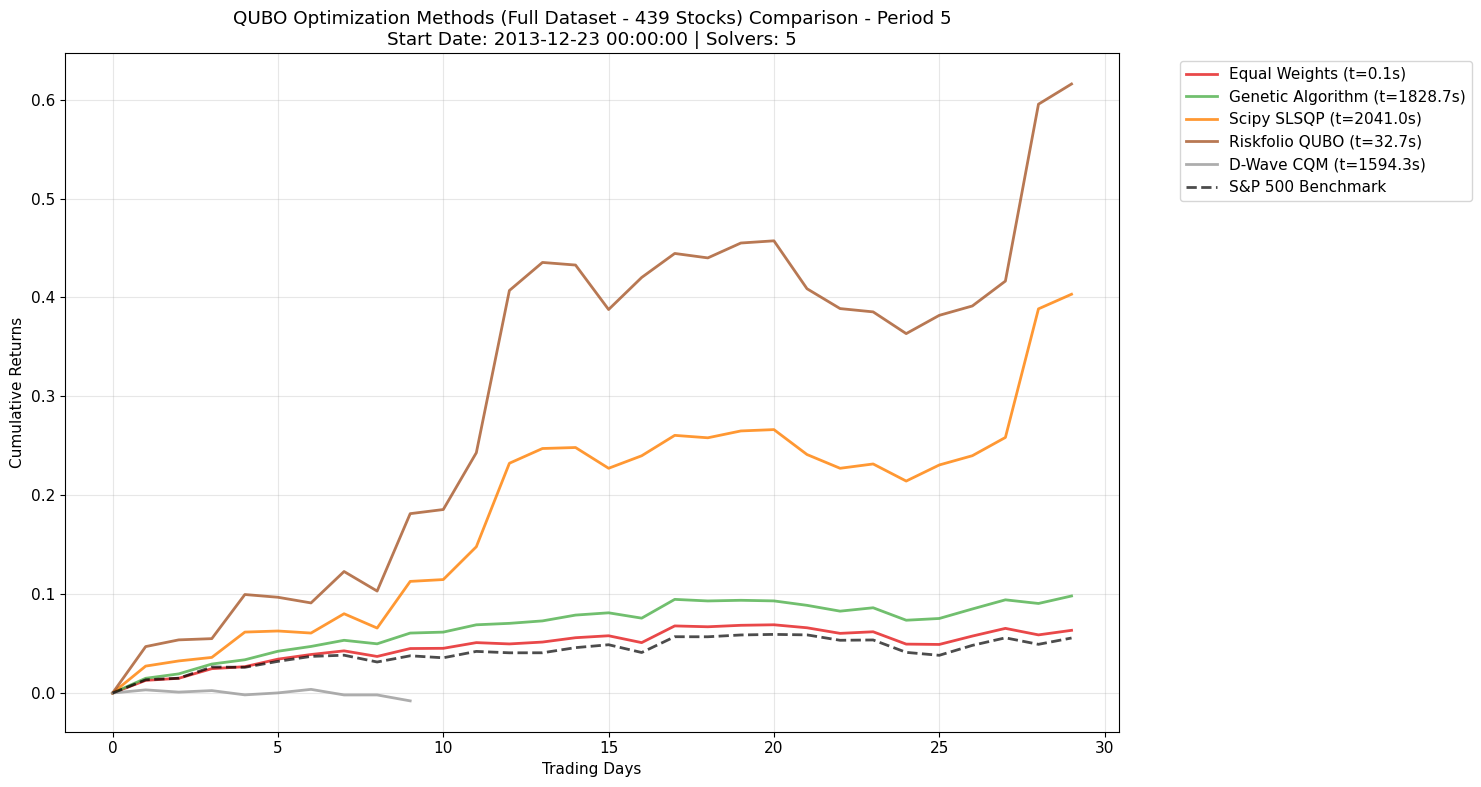


Period 5 Summary:
--------------------------------------------------
Equal Weights            :   0.0634 (  0.08s)
Genetic Algorithm        :   0.0981 (1828.71s)
Scipy SLSQP              :   0.4033 (2041.04s)
Riskfolio QUBO           :   0.6159 ( 32.72s)
D-Wave CQM               :  -0.0079 (1594.25s)
Benchmark                :   0.0556

Period 6: Loaded Equal Weights (exec_time: 0.08s)
Period 6: Loaded Genetic Algorithm (exec_time: 1834.68s)
Period 6: Loaded Scipy SLSQP (exec_time: 1814.00s)
Period 6: Loaded Riskfolio QUBO (exec_time: 32.65s)
Period 6: Loaded D-Wave CQM (exec_time: 1619.90s)


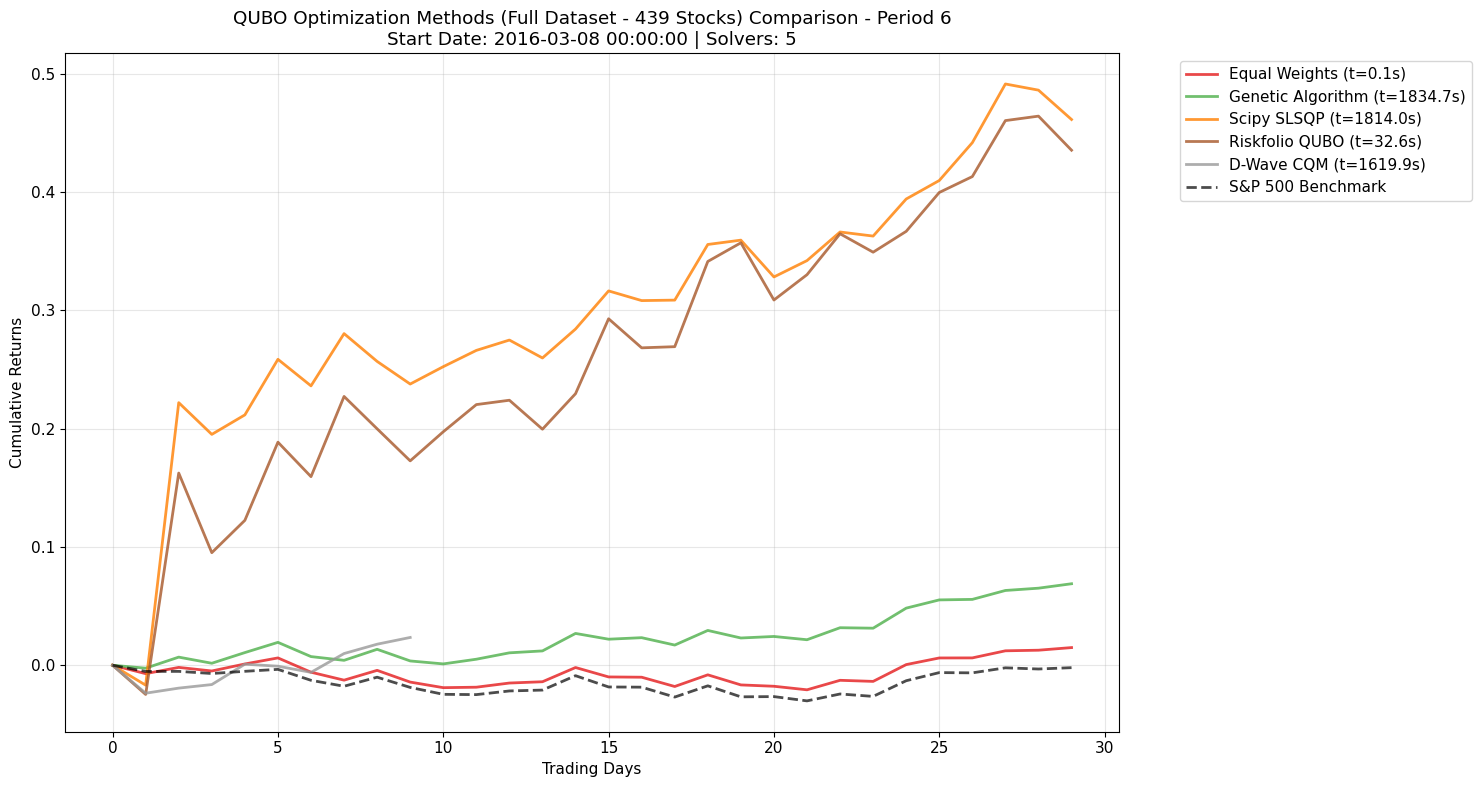


Period 6 Summary:
--------------------------------------------------
Equal Weights            :   0.0149 (  0.08s)
Genetic Algorithm        :   0.0689 (1834.68s)
Scipy SLSQP              :   0.4612 (1814.00s)
Riskfolio QUBO           :   0.4352 ( 32.65s)
D-Wave CQM               :   0.0235 (1619.90s)
Benchmark                :  -0.0020

Period 7: Loaded Equal Weights (exec_time: 0.10s)
Period 7: Loaded Genetic Algorithm (exec_time: 1833.86s)
Period 7: Loaded Scipy SLSQP (exec_time: 1264.55s)
Period 7: Loaded Riskfolio QUBO (exec_time: 33.11s)
Period 7: Loaded D-Wave CQM (exec_time: 1613.81s)


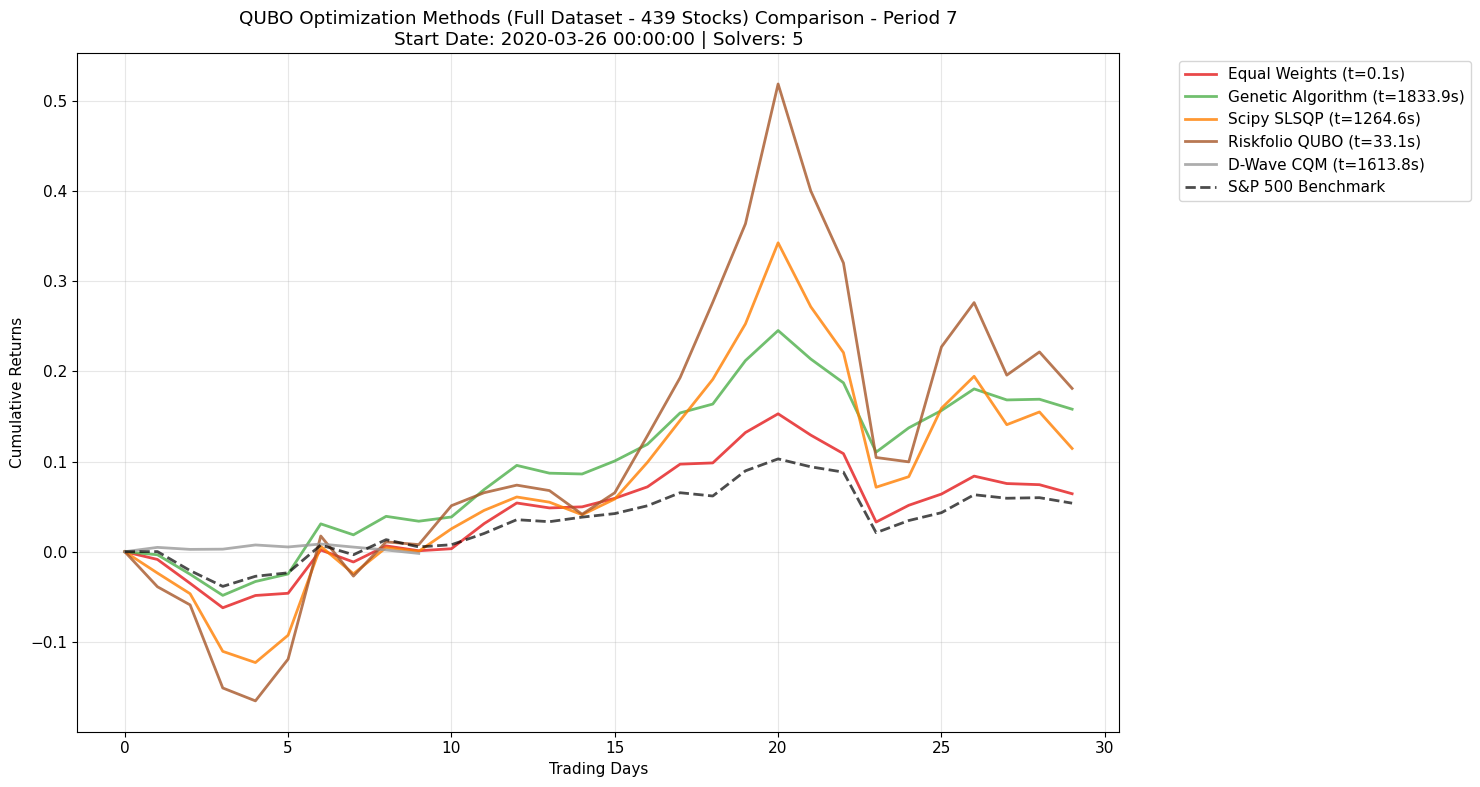


Period 7 Summary:
--------------------------------------------------
Equal Weights            :   0.0643 (  0.10s)
Genetic Algorithm        :   0.1580 (1833.86s)
Scipy SLSQP              :   0.1145 (1264.55s)
Riskfolio QUBO           :   0.1811 ( 33.11s)
D-Wave CQM               :  -0.0019 (1613.81s)
Benchmark                :   0.0538

Period 8: Loaded Equal Weights (exec_time: 0.10s)
Period 8: Loaded Genetic Algorithm (exec_time: 1834.17s)
Period 8: Loaded Scipy SLSQP (exec_time: 1877.14s)
Period 8: Loaded Riskfolio QUBO (exec_time: 35.67s)
Period 8: Loaded D-Wave CQM (exec_time: 1612.88s)


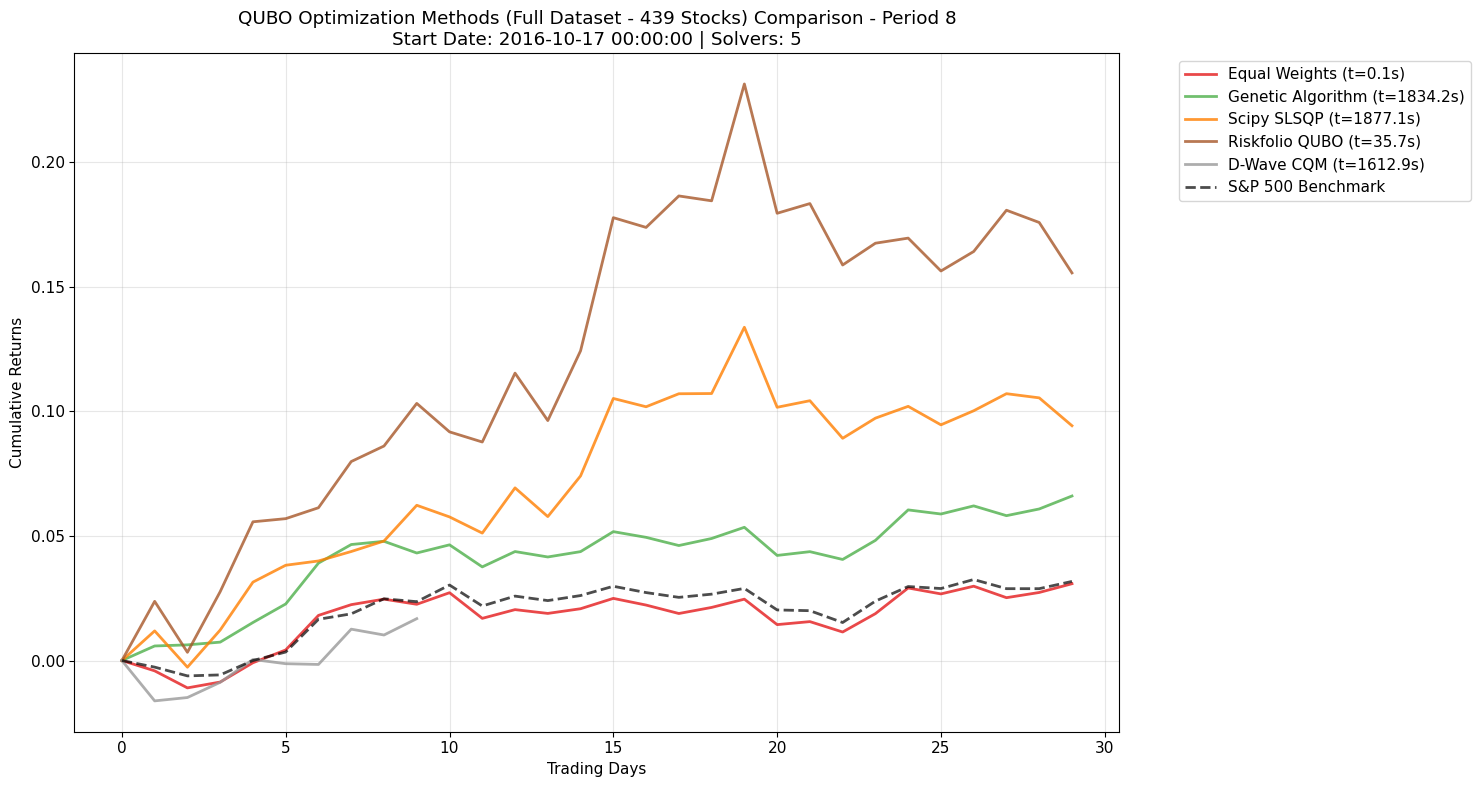


Period 8 Summary:
--------------------------------------------------
Equal Weights            :   0.0308 (  0.10s)
Genetic Algorithm        :   0.0660 (1834.17s)
Scipy SLSQP              :   0.0943 (1877.14s)
Riskfolio QUBO           :   0.1556 ( 35.67s)
D-Wave CQM               :   0.0168 (1612.88s)
Benchmark                :   0.0317

Period 9: Loaded Equal Weights (exec_time: 0.10s)
Period 9: Loaded Genetic Algorithm (exec_time: 1834.54s)
Period 9: Loaded Scipy SLSQP (exec_time: 2143.04s)
Period 9: Loaded Riskfolio QUBO (exec_time: 32.85s)
Period 9: Loaded D-Wave CQM (exec_time: 1612.54s)


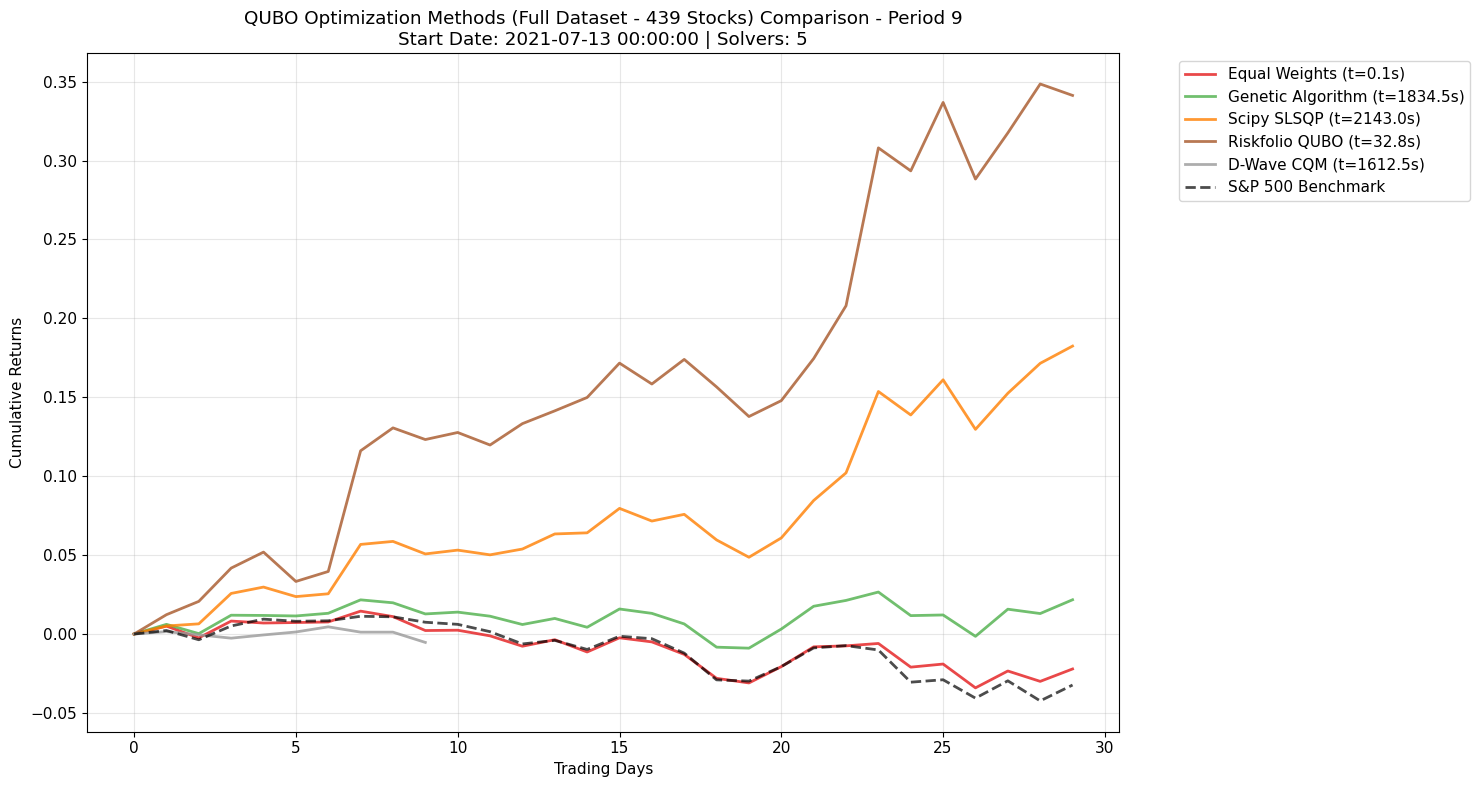


Period 9 Summary:
--------------------------------------------------
Equal Weights            :  -0.0221 (  0.10s)
Genetic Algorithm        :   0.0217 (1834.54s)
Scipy SLSQP              :   0.1825 (2143.04s)
Riskfolio QUBO           :   0.3413 ( 32.85s)
D-Wave CQM               :  -0.0053 (1612.54s)
Benchmark                :  -0.0323


COMPREHENSIVE PERFORMANCE SUMMARY - QUBO Methods (Full Dataset) Including CQM
           Solver  Periods  Avg_Return  Std_Return  Min_Return  Max_Return  Avg_Time  Std_Time  Success_Rate
   Riskfolio QUBO       10      0.3263      0.1758      0.1369      0.6229   32.8565    1.1500         100.0
      Scipy SLSQP       10      0.2194      0.1300      0.0757      0.4612 1737.8478  259.5839         100.0
Genetic Algorithm       10      0.0776      0.0444      0.0217      0.1580 1831.9752    2.1661         100.0
    Equal Weights       10      0.0288      0.0344     -0.0221      0.0836    0.0901    0.0106         100.0
       D-Wave CQM       10      0.01

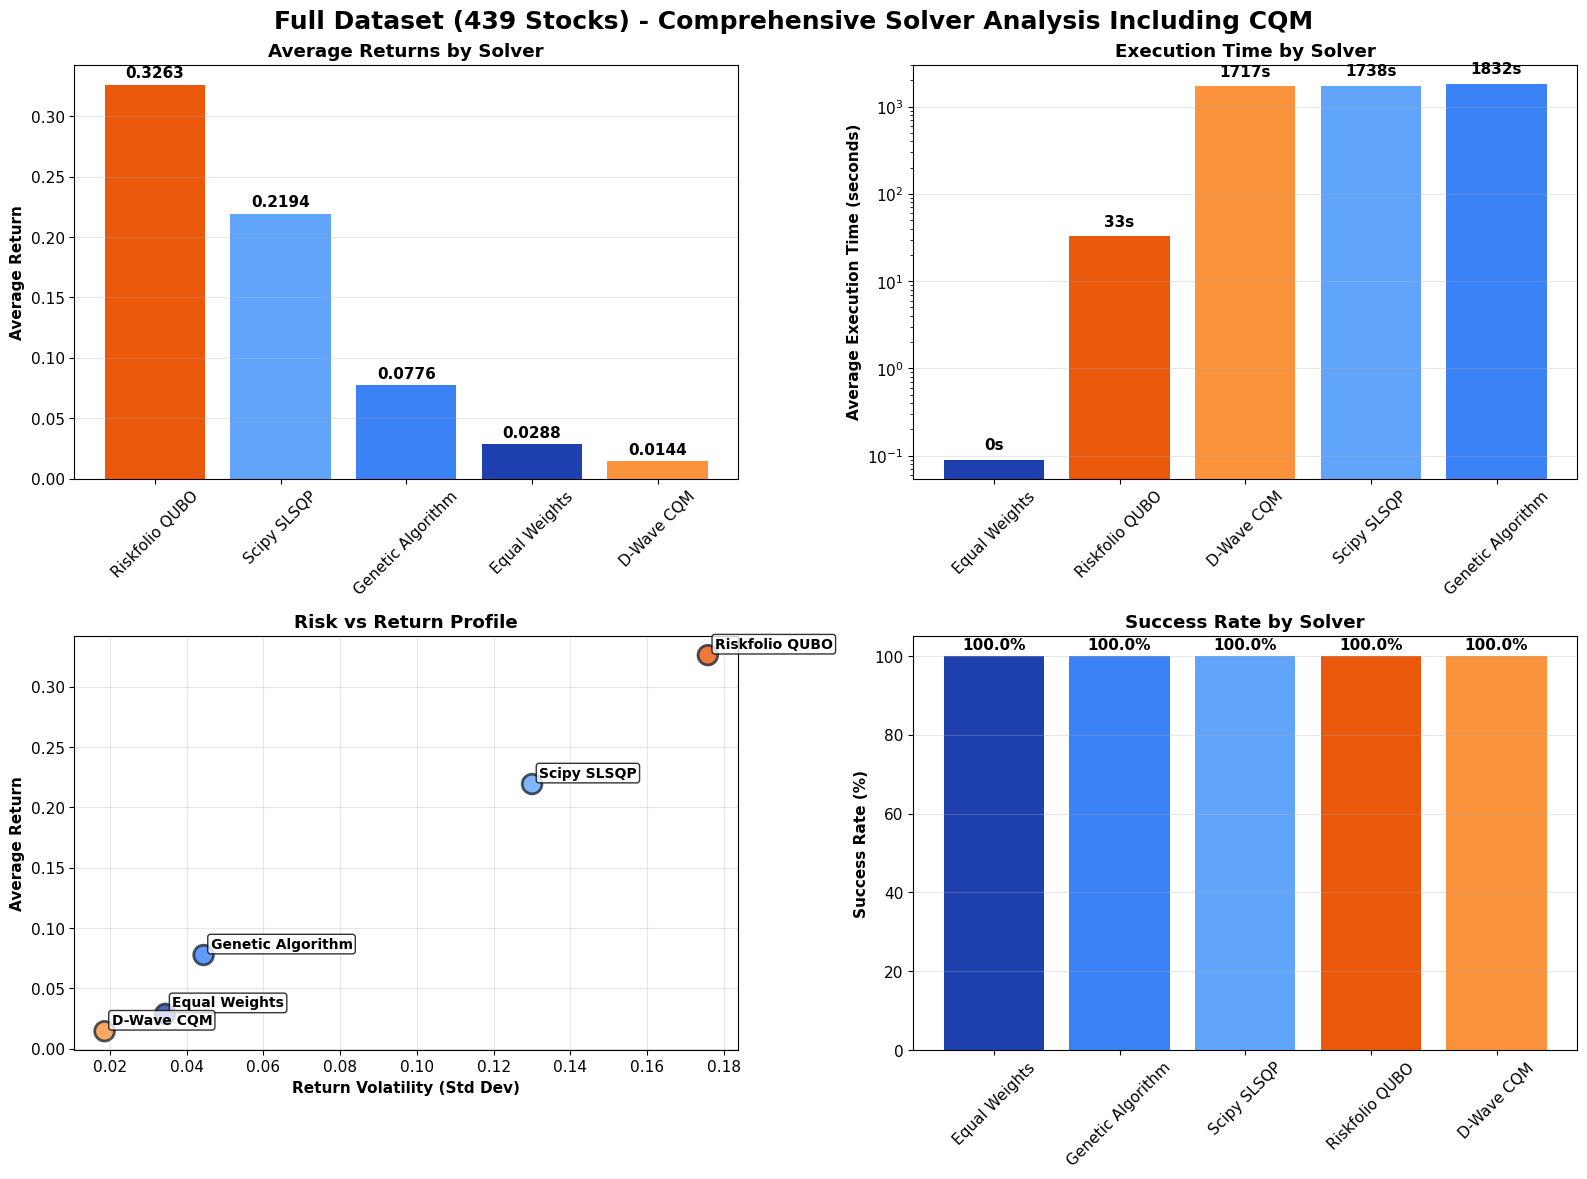

In [34]:
# Multi-period comparison plots for Full Dataset including CQM results
print("\n" + "=" * 100)
print("FULL DATASET - MULTI-PERIOD SOLVER COMPARISON INCLUDING CQM")
print("=" * 100)

# Define solver configurations including CQM with correct path format
full_dataset_solvers = [
    {'path_template': '../../results/qubo_unrestricted/results_full_{}_ew.pkl', 'name': 'Equal Weights'},
    {'path_template': '../../results/qubo_unrestricted/results_full_{}_ga.pkl', 'name': 'Genetic Algorithm'},
    {'path_template': '../../results/qubo_unrestricted/results_full_{}_bf.pkl', 'name': 'Scipy SLSQP'},
    {'path_template': '../../results/qubo_unrestricted/results_full_{}_hrp.pkl', 'name': 'Riskfolio QUBO'},
    {'path_template': '../../results/qubo_unrestricted/results_full_{}_dwave_cqm.pkl', 'name': 'D-Wave CQM'}
]

# Check available periods based on df_full dataset
available_periods = sorted(df_full['period'].unique())
n_periods = len(available_periods)

print(f"Running comparison across {n_periods} periods: {available_periods}")

# Run the multi-comparison analysis
multi_comparison(full_dataset_solvers, n_periods, "QUBO Optimization Methods (Full Dataset - 439 Stocks)")

# Generate comprehensive performance summary including CQM
def performance_summary_extended(solver_configs, n_periods):
    """Generate performance summary across all periods for multiple solvers."""
    summary_data = []
    
    for config in solver_configs:
        solver_name = config['name']
        path_template = config['path_template']
        
        returns_data = []
        execution_times = []
        successful_periods = 0
        
        for period in range(n_periods):
            file_path = path_template.format(period)
            try:
                result_data = load_pickle_result(file_path)
                if result_data is not None:
                    portfolio_returns = result_data.get('portfolio_cumulative_returns', [])
                    execution_time = result_data.get('total_run_time', 0)
                    
                    # Safe check for portfolio returns data
                    try:
                        if portfolio_returns is not None and len(portfolio_returns) > 0:
                            final_return = portfolio_returns[-1]
                            returns_data.append(final_return)
                            execution_times.append(execution_time)
                            successful_periods += 1
                    except (TypeError, IndexError):
                        pass
            except Exception as e:
                print(f'Could not process {file_path}: {e}')
        
        if returns_data:
            summary_data.append({
                'Solver': solver_name,
                'Periods': successful_periods,
                'Avg_Return': np.mean(returns_data),
                'Std_Return': np.std(returns_data),
                'Min_Return': np.min(returns_data),
                'Max_Return': np.max(returns_data),
                'Avg_Time': np.mean(execution_times),
                'Std_Time': np.std(execution_times),
                'Success_Rate': successful_periods / n_periods * 100
            })
    
    if summary_data:
        df = pd.DataFrame(summary_data)
        df = df.round(4)
        return df
    else:
        return pd.DataFrame()

print("\n" + "="*100)
print("COMPREHENSIVE PERFORMANCE SUMMARY - QUBO Methods (Full Dataset) Including CQM")
print("="*100)
summary_df_full = performance_summary_extended(full_dataset_solvers, n_periods)
if not summary_df_full.empty:
    # Sort by average return for better readability
    summary_df_sorted = summary_df_full.sort_values('Avg_Return', ascending=False)
    print(summary_df_sorted.to_string(index=False))
    
    # Performance analysis
    print("\nPerformance Analysis:")
    print("-" * 50)
    print(f"Methods compared: {len(summary_df_full)}")
    print(f"Best performer: {summary_df_sorted.iloc[0]['Solver']} (avg return: {summary_df_sorted.iloc[0]['Avg_Return']:.4f})")
    print(f"Fastest method: {summary_df_full.loc[summary_df_full['Avg_Time'].idxmin(), 'Solver']} ({summary_df_full['Avg_Time'].min():.2f}s)")
    print(f"Most reliable: {summary_df_full.loc[summary_df_full['Success_Rate'].idxmax(), 'Solver']} ({summary_df_full['Success_Rate'].max():.1f}%)")
    
    # Create comparison visualization with consistent colors
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Full Dataset (439 Stocks) - Comprehensive Solver Analysis Including CQM', fontsize=18, fontweight='bold')
    
    # Define consistent color mapping for solvers using blue and orange hues
    solver_colors = {
        'Equal Weights': '#1E40AF',      # Deep blue
        'Genetic Algorithm': '#3B82F6',  # Medium blue
        'Scipy SLSQP': '#60A5FA',        # Light blue
        'Riskfolio QUBO': '#EA580C',     # Deep orange
        'D-Wave CQM': '#FB923C'          # Light orange
    }
    
    # 1. Average Returns (sorted by performance, but consistent colors)
    summary_df_sorted = summary_df_full.sort_values('Avg_Return', ascending=False)
    colors_returns = [solver_colors.get(solver, '#1E40AF') for solver in summary_df_sorted['Solver']]
    bars1 = ax1.bar(summary_df_sorted['Solver'], summary_df_sorted['Avg_Return'], 
                   color=colors_returns)
    ax1.set_ylabel('Average Return', fontweight='bold')
    ax1.set_title('Average Returns by Solver', fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3, axis='y')
    
    for bar, value in zip(bars1, summary_df_sorted['Avg_Return']):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.003,
                f'{value:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # 2. Execution Time (sorted by time, but consistent colors)
    summary_df_time = summary_df_full.sort_values('Avg_Time', ascending=True)
    colors_time = [solver_colors.get(solver, '#1E40AF') for solver in summary_df_time['Solver']]
    bars2 = ax2.bar(summary_df_time['Solver'], summary_df_time['Avg_Time'], 
                    color=colors_time)
    ax2.set_ylabel('Average Execution Time (seconds)', fontweight='bold')
    ax2.set_title('Execution Time by Solver', fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_yscale('log')
    
    for bar, value in zip(bars2, summary_df_time['Avg_Time']):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height * 1.2,
                f'{value:.0f}s', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # 3. Risk-Return Scatter (consistent colors)
    colors_scatter = [solver_colors.get(solver, '#1E40AF') for solver in summary_df_full['Solver']]
    scatter = ax3.scatter(summary_df_full['Std_Return'], summary_df_full['Avg_Return'], 
                         s=200, alpha=0.8, c=colors_scatter, 
                         edgecolors='#1F2937', linewidth=2)
    
    for i, row in summary_df_full.iterrows():
        ax3.annotate(row['Solver'], 
                    (row['Std_Return'], row['Avg_Return']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))
    
    ax3.set_xlabel('Return Volatility (Std Dev)', fontweight='bold')
    ax3.set_ylabel('Average Return', fontweight='bold')
    ax3.set_title('Risk vs Return Profile', fontweight='bold')
    ax3.grid(True, alpha=0.3)
    
    # 4. Success Rate (consistent colors)
    colors_success = [solver_colors.get(solver, '#1E40AF') for solver in summary_df_full['Solver']]
    bars4 = ax4.bar(summary_df_full['Solver'], summary_df_full['Success_Rate'], 
                    color=colors_success)
    ax4.set_ylabel('Success Rate (%)', fontweight='bold')
    ax4.set_title('Success Rate by Solver', fontweight='bold')
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3, axis='y')
    ax4.set_ylim(0, 105)
    
    for bar, value in zip(bars4, summary_df_full['Success_Rate']):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{value:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    plt.tight_layout()
    plt.show()
else:
    print("No summary data available")


FULL DATASET (439 ASSETS) - COMPREHENSIVE ANALYSIS EXTENSION


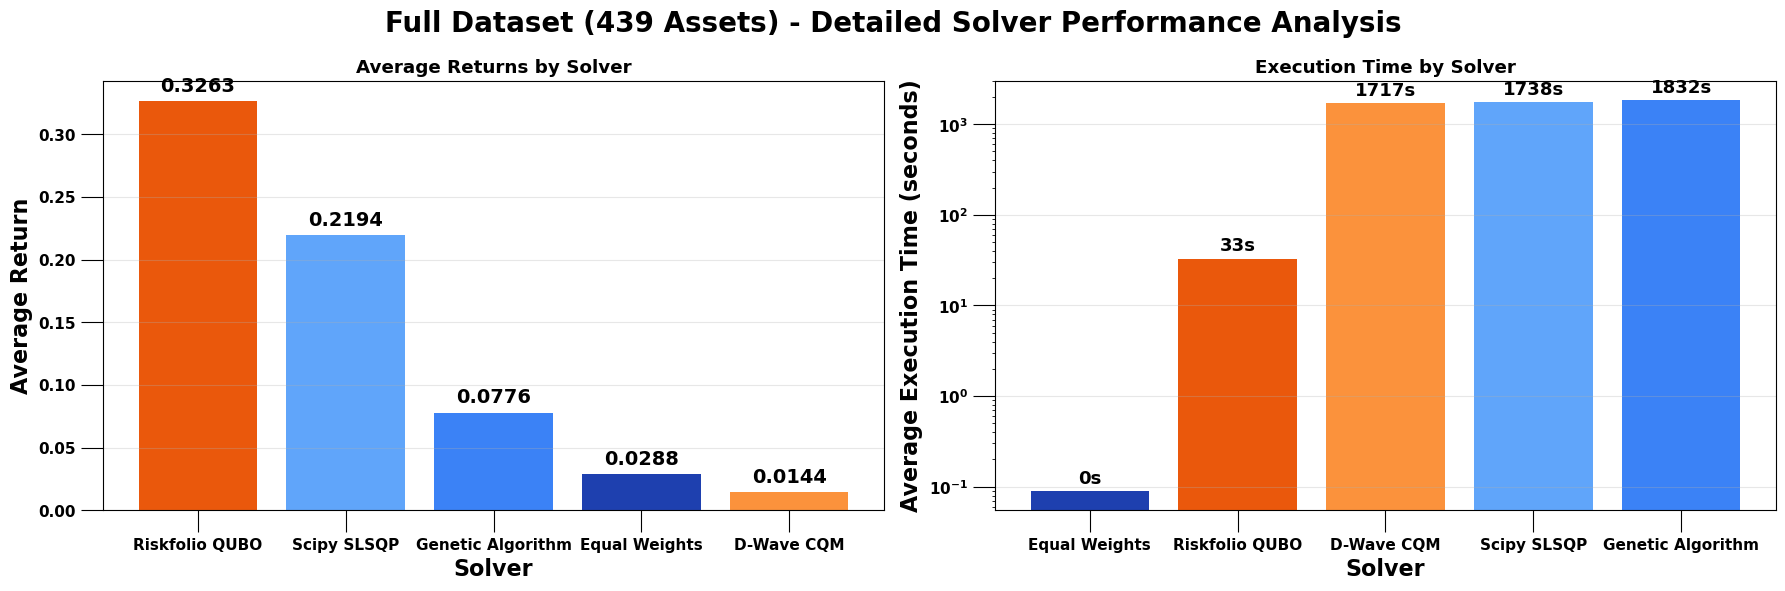

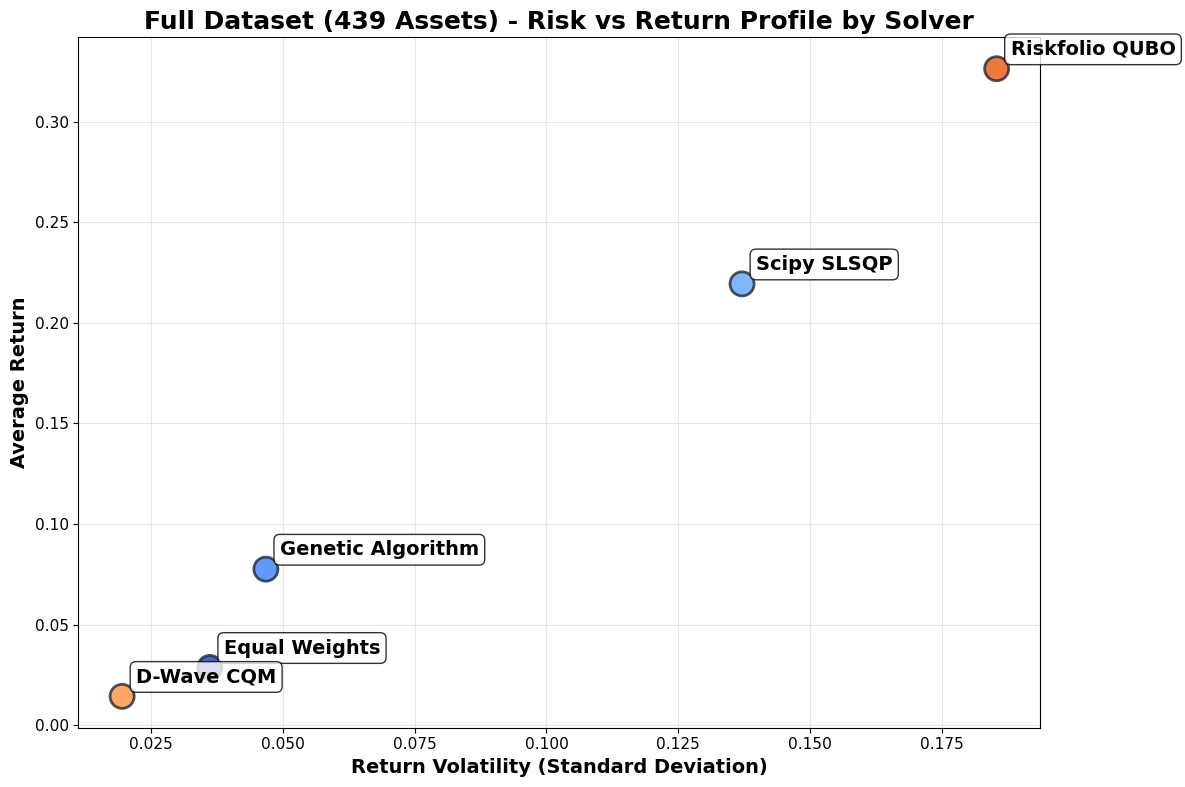


WIDE DATASET - PERIOD-BY-PERIOD DETAILED RESULTS

Period 0:
--------------------
  Equal Weights       : Return=  0.0480, Time=    0.10s
  Scipy SLSQP         : Return=  0.1721, Time= 1486.65s
  D-Wave CQM          : Return=  0.0293, Time=  813.60s
  Genetic Algorithm   : Return=  0.0795, Time= 1831.56s
  Riskfolio QUBO      : Return=  0.2424, Time=   32.63s
  Best performer: Riskfolio QUBO (0.2424)

Period 1:
--------------------
  Riskfolio QUBO      : Return=  0.3769, Time=   31.24s
  Equal Weights       : Return= -0.0001, Time=    0.09s
  Genetic Algorithm   : Return=  0.0374, Time= 1831.29s
  D-Wave CQM          : Return=  0.0371, Time= 1548.03s
  Scipy SLSQP         : Return=  0.2246, Time= 1919.28s
  Best performer: Riskfolio QUBO (0.3769)

Period 2:
--------------------
  Scipy SLSQP         : Return=  0.0757, Time= 1556.18s
  Riskfolio QUBO      : Return=  0.1369, Time=   32.03s
  D-Wave CQM          : Return=  0.0332, Time= 2538.99s
  Equal Weights       : Return= -0.0194, T

In [35]:
# Additional comprehensive analysis specifically for wide dataset
print("\n" + "=" * 100)
print("FULL DATASET (439 ASSETS) - COMPREHENSIVE ANALYSIS EXTENSION")
print("=" * 100)

# Create detailed performance comparison plots for wide dataset (similar to what was done for other datasets)
if stats_full is not None:
    # Create comprehensive barplot showing average returns for each solver in wide dataset
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    plt.subplots_adjust(wspace=0.2)
    fig.suptitle('Full Dataset (439 Assets) - Detailed Solver Performance Analysis', fontsize=20, fontweight='bold')
    
    # Define consistent color mapping for solvers using blue and orange hues
    solver_colors = {
        'Equal Weights': '#1E40AF',      # Deep blue
        'Genetic Algorithm': '#3B82F6',  # Medium blue
        'Scipy SLSQP': '#60A5FA',        # Light blue
        'Riskfolio QUBO': '#EA580C',     # Deep orange
        'D-Wave CQM': '#FB923C'          # Light orange
    }
    
    # 1. Average Returns Barplot
    stats_wide_sorted = stats_full.sort_values('Avg_Return', ascending=False)
    colors_returns = [solver_colors.get(solver, '#1E40AF') for solver in stats_wide_sorted['Solver']]
    bars = ax1.bar(stats_wide_sorted['Solver'], stats_wide_sorted['Avg_Return'], 
                   color=colors_returns)
    
    ax1.set_xlabel('Solver', fontweight='bold', fontsize=16)
    ax1.set_ylabel('Average Return', fontweight='bold', fontsize=16)
    ax1.set_title('Average Returns by Solver', fontweight='bold')
    ax1.tick_params(axis='x', size=16, which='major')
    ax1.tick_params(axis='y', size=16)
    for label in ax1.get_xticklabels():
      label.set_weight('bold')
    for label in ax1.get_yticklabels():
      label.set_weight('bold')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, value in zip(bars, stats_wide_sorted['Avg_Return']):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{value:.4f}',
                ha='center', va='bottom', fontweight='bold', fontsize=14)
    
    # 2. Execution Time Comparison (same solvers, same colors)
    stats_wide_time = stats_full.sort_values('Avg_Time', ascending=True)
    colors_time = [solver_colors.get(solver, '#1E40AF') for solver in stats_wide_time['Solver']]
    bars2 = ax2.bar(stats_wide_time['Solver'], stats_wide_time['Avg_Time'], 
                    color=colors_time)
    
    ax2.set_xlabel('Solver', fontweight='bold', fontsize=16)
    ax2.set_ylabel('Average Execution Time (seconds)', fontweight='bold', fontsize=16)
    ax2.set_title('Execution Time by Solver', fontweight='bold')
    ax2.tick_params(axis='x', size=16, which='major')
    ax2.tick_params(axis='y', size=16)
    for label in ax2.get_xticklabels():
      label.set_weight('bold')
    for label in ax2.get_yticklabels():
      label.set_weight('bold')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_yscale('log')  # Log scale due to large differences
    
    # Add value labels on bars
    for bar, value in zip(bars2, stats_wide_time['Avg_Time']):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height * 1.1,
                f'{value:.0f}s',
                ha='center', va='bottom', fontweight='bold', fontsize=13)
    
    plt.tight_layout()
    plt.show()
    
    # Additional risk-return analysis for wide dataset
    plt.figure(figsize=(12, 8))
    colors_scatter = [solver_colors.get(solver, '#1E40AF') for solver in stats_full['Solver']]
    scatter = plt.scatter(stats_full['Std_Return'], stats_full['Avg_Return'], 
                         s=300, alpha=0.8, c=colors_scatter, 
                         edgecolors='#1F2937', linewidth=2)
    
    for i, row in stats_full.iterrows():
        plt.annotate(row['Solver'], 
                    (row['Std_Return'], row['Avg_Return']),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=14, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
    
    plt.xlabel('Return Volatility (Standard Deviation)', fontweight='bold', fontsize=14)
    plt.ylabel('Average Return', fontweight='bold', fontsize=14)
    plt.title('Full Dataset (439 Assets) - Risk vs Return Profile by Solver', fontsize=18, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print("No valid performance data available for wide dataset detailed analysis")

# Detailed period-by-period analysis for wide dataset
print("\n" + "=" * 80)
print("WIDE DATASET - PERIOD-BY-PERIOD DETAILED RESULTS")
print("=" * 80)

wide_period_results = []
for period in sorted(df_full['period'].unique()):
    period_data = df_full[df_full['period'] == period]
    valid_period_data = period_data[period_data['final_return'].notna()]
    
    if len(valid_period_data) > 0:
        print(f"\nPeriod {period}:")
        print("-" * 20)
        
        period_summary = []
        for _, row in valid_period_data.iterrows():
            solver_name = row['solver_name']
            final_return = row['final_return']
            exec_time = row['execution_time']
            start_date = row['start_date']
            end_date = row['end_date']
            
            period_summary.append({
                'Period': period,
                'Solver': solver_name,
                'Return': final_return,
                'Exec_Time': exec_time,
                'Start_Date': start_date,
                'End_Date': end_date
            })
            
            print(f"  {solver_name:<20}: Return={final_return:>8.4f}, Time={exec_time:>8.2f}s")
        
        # Find best performer for this period
        if period_summary:
            best_period = max(period_summary, key=lambda x: x['Return'])
            print(f"  Best performer: {best_period['Solver']} ({best_period['Return']:.4f})")
            wide_period_results.extend(period_summary)

# Create DataFrame for period analysis
if wide_period_results:
    df_wide_periods = pd.DataFrame(wide_period_results)
    
    print("\n" + "=" * 80)
    print("FULL DATASET - CROSS-PERIOD SOLVER PERFORMANCE SUMMARY")
    print("=" * 80)
    
    # Count wins per solver
    solver_wins = {}
    for period in df_wide_periods['Period'].unique():
        period_data = df_wide_periods[df_wide_periods['Period'] == period]
        if len(period_data) > 0:
            best_solver = period_data.loc[period_data['Return'].idxmax(), 'Solver']
            solver_wins[best_solver] = solver_wins.get(best_solver, 0) + 1
    
    print("Period wins by solver:")
    for solver, wins in sorted(solver_wins.items(), key=lambda x: x[1], reverse=True):
        print(f"  {solver:<20}: {wins} periods")
    
    # Performance consistency analysis
    print("\nPerformance consistency (coefficient of variation - lower is more consistent):")
    for solver in df_wide_periods['Solver'].unique():
        solver_data = df_wide_periods[df_wide_periods['Solver'] == solver]
        if len(solver_data) > 1:
            mean_return = solver_data['Return'].mean()
            std_return = solver_data['Return'].std()
            cv = std_return / abs(mean_return) if mean_return != 0 else float('inf')
            print(f"  {solver:<20}: CV={cv:>8.4f} (std={std_return:.4f}, mean={mean_return:.4f})")

print("\n" + "=" * 80)
print("FULL DATASET ANALYSIS COMPLETE")
print("=" * 80)

In [36]:
# Filter for wide dataset results
df_wide = df_results[df_results['dataset'] == 'wide'].copy()

print("=" * 80)
print("WIDE DATASET (680 ASSETS) - DETAILED ANALYSIS")
print("=" * 80)

print(f"Found {len(df_wide)} results for wide dataset")
print(f"Solvers: {sorted(df_wide['solver_name'].unique())}")
print(f"Periods: {sorted(df_wide['period'].unique())}")

# Check data availability
valid_results_wide = df_wide[df_wide['final_return'].notna()]
print(f"Results with valid portfolio returns: {len(valid_results_wide)}")

# Performance analysis for wide dataset
stats_wide = analyze_performance(df_wide, "Wide Dataset")
if stats_wide is not None:
    print("\nWide Dataset Performance Summary:")
    print("-" * 50)
    stats_wide_sorted = stats_wide.sort_values('Avg_Return', ascending=False)
    print(stats_wide_sorted.to_string(index=False))
    
    print(f"\nBest performer: {stats_wide_sorted.iloc[0]['Solver']} (avg return: {stats_wide_sorted.iloc[0]['Avg_Return']:.4f})")
    print(f"Fastest solver: {stats_wide.loc[stats_wide['Avg_Time'].idxmin(), 'Solver']} ({stats_wide['Avg_Time'].min():.2f}s)")
    print(f"Most reliable: {stats_wide.loc[stats_wide['Success_Rate'].idxmax(), 'Solver']} ({stats_wide['Success_Rate'].max():.1f}%)")

WIDE DATASET (680 ASSETS) - DETAILED ANALYSIS
Found 50 results for wide dataset
Solvers: ['D-Wave CQM', 'Equal Weights', 'Genetic Algorithm', 'Riskfolio QUBO', 'Scipy SLSQP']
Periods: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Results with valid portfolio returns: 50

Analyzing performance for Wide Dataset...

Wide Dataset Performance Summary:
--------------------------------------------------
           Solver  Periods  Avg_Return  Std_Return  Min_Return  Max_Return    Avg_Time   Std_Time  Success_Rate
      Scipy SLSQP       10    0.180130    0.245560    0.020156    0.868911 5354.728797 752.748472         100.0
   Riskfolio QUBO       10    0.071855    0.195376   -0.078645    0.618592   29.526356  16.606512         100.0
Genetic Algorithm       10    0.047508    0.039315   -0.047946    0.096569 4183.915608   4.396421         100.0
    Equal Weights       10    0.007686    0.037216   -0.078645    0

Found weights for Riskfolio QUBO: 20400 positions, sum=30.000000
Found weights for Scipy SLSQP: 20400 positions, sum=30.000000
Found weights for Equal Weights: 20400 positions, sum=30.000000
Found weights for Genetic Algorithm: 20384 positions, sum=29.999993
Found weights for D-Wave CQM: 20400 positions, sum=30.000000
\n================================================================================
WIDE DATASET - WEIGHT DISTRIBUTION ANALYSIS
\nRiskfolio QUBO:
  Total positions: 183681
  Mean weight: 0.001633 (0.1633%)
  Std weight: 0.009405
  Min weight: 0.001094
  Max weight: 1.000000 (100.0000%)
  Median weight: 0.001471
  Top 5 positions sum: 4.5846 (458.46%)
  Top 10 positions sum: 8.1985 (819.85%)
  Top 20 positions sum: 14.5207 (1452.07%)
  Top 50 positions sum: 26.2330 (2623.30%)
\nScipy SLSQP:
  Total positions: 204000
  Mean weight: 0.001471 (0.1471%)
  Std weight: 0.010696
  Min weight: 0.001000
  Max weight: 0.321000 (32.1000%)
  Median weight: 0.001000
  Top 5 positions su

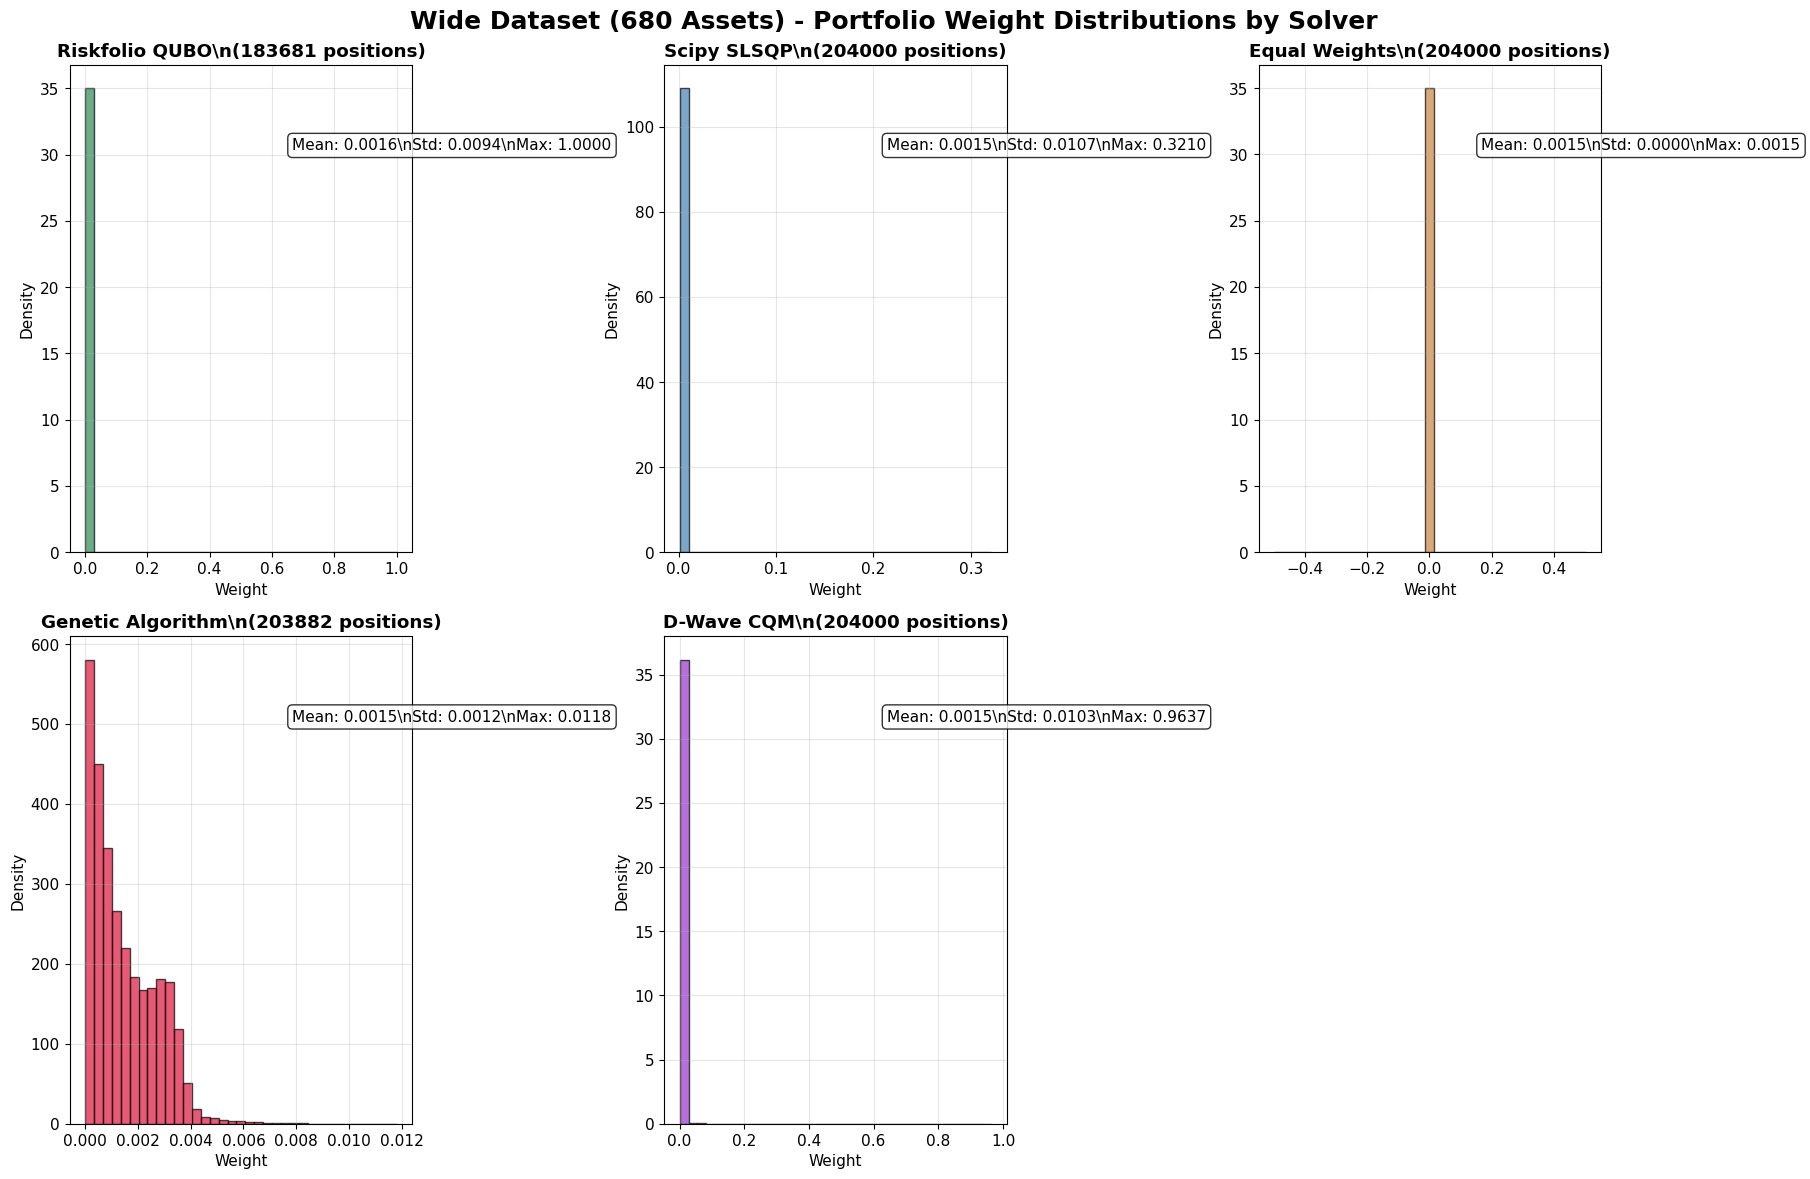

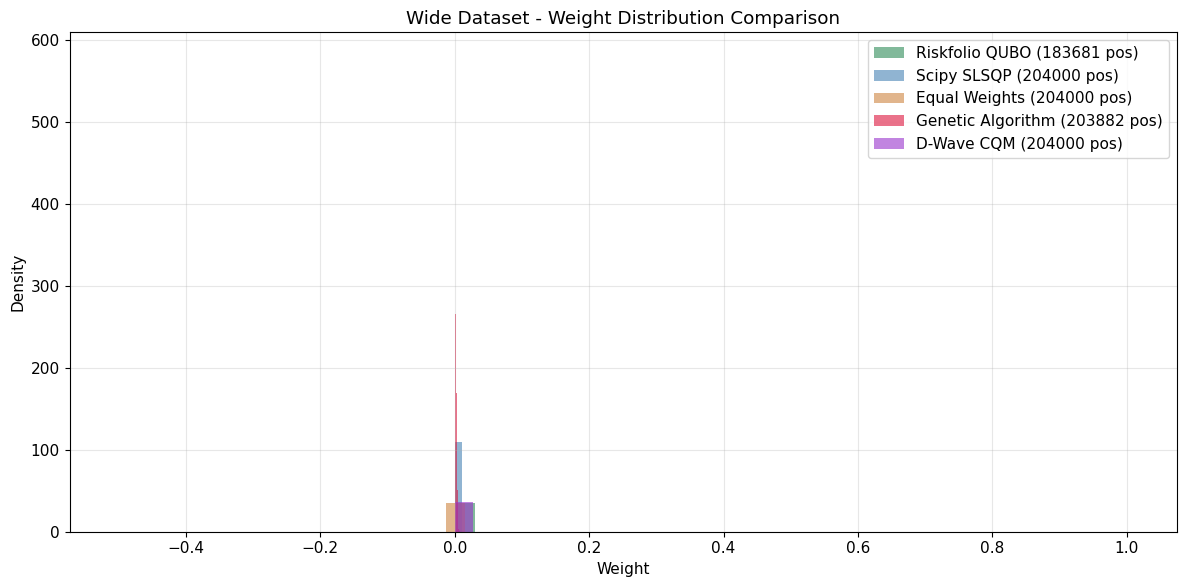

In [37]:
    # Weight Distribution Analysis for Wide Dataset
    weights_wide_stocks = extract_weights_from_results(df_wide)

    if weights_wide_stocks:
        print("\\n" + "=" * 80)
        print("WIDE DATASET - WEIGHT DISTRIBUTION ANALYSIS")
        print("=" * 80)
        
        # Create weight distribution plots
        n_solvers = len(weights_wide_stocks)
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('Wide Dataset (680 Assets) - Portfolio Weight Distributions by Solver', fontsize=18, fontweight='bold')
        
        axes_flat = axes.flatten()
        colors = ['#2E8B57', '#4682B4', '#CD853F', '#DC143C', '#9932CC', '#FF6347']
        
        for idx, (solver_name, weights) in enumerate(weights_wide_stocks.items()):
            if idx >= len(axes_flat):
                break
                
            ax = axes_flat[idx]
            weights_array = np.array(weights)
            
            # Plot histogram
            ax.hist(weights_array, bins=35, alpha=0.7, color=colors[idx % len(colors)], 
                    edgecolor='black', density=True)
            
            # Calculate statistics
            mean_weight = np.mean(weights_array)
            std_weight = np.std(weights_array)
            max_weight = np.max(weights_array)
            n_positions = len(weights_array)
            
            ax.set_xlabel('Weight')
            ax.set_ylabel('Density')
            ax.set_title(f'{solver_name}\\n({n_positions} positions)', fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            # Add statistics text
            stats_text = f'Mean: {mean_weight:.4f}\\nStd: {std_weight:.4f}\\nMax: {max_weight:.4f}'
            ax.text(0.65, 0.85, stats_text, transform=ax.transAxes, 
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
                    fontsize=11, verticalalignment='top')
            
            # Print detailed statistics
            print(f"\\n{solver_name}:")
            print(f"  Total positions: {n_positions}")
            print(f"  Mean weight: {mean_weight:.6f} ({mean_weight*100:.4f}%)")
            print(f"  Std weight: {std_weight:.6f}")
            print(f"  Min weight: {np.min(weights_array):.6f}")
            print(f"  Max weight: {max_weight:.6f} ({max_weight*100:.4f}%)")
            print(f"  Median weight: {np.median(weights_array):.6f}")
            
            # Concentration metrics
            sorted_weights = np.sort(weights_array)[::-1]
            if len(sorted_weights) >= 5:
                top5_sum = np.sum(sorted_weights[:5])
                print(f"  Top 5 positions sum: {top5_sum:.4f} ({top5_sum*100:.2f}%)")
            if len(sorted_weights) >= 10:
                top10_sum = np.sum(sorted_weights[:10])
                print(f"  Top 10 positions sum: {top10_sum:.4f} ({top10_sum*100:.2f}%)")
            if len(sorted_weights) >= 20:
                top20_sum = np.sum(sorted_weights[:20])
                print(f"  Top 20 positions sum: {top20_sum:.4f} ({top20_sum*100:.2f}%)")
            if len(sorted_weights) >= 50:
                top50_sum = np.sum(sorted_weights[:50])
                print(f"  Top 50 positions sum: {top50_sum:.4f} ({top50_sum*100:.2f}%)")
        
        # Hide unused subplots
        for idx in range(len(weights_wide_stocks), len(axes_flat)):
            axes_flat[idx].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        
        # Comparison plot
        plt.figure(figsize=(12, 6))
        for idx, (solver_name, weights) in enumerate(weights_wide_stocks.items()):
            weights_array = np.array(weights)
            plt.hist(weights_array, bins=35, alpha=0.6, 
                    label=f'{solver_name} ({len(weights_array)} pos)', 
                    color=colors[idx % len(colors)], density=True)
        
        plt.xlabel('Weight')
        plt.ylabel('Density')
        plt.title('Wide Dataset - Weight Distribution Comparison')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    else:
        print("\\nNo weight data available for wide dataset analysis")


WIDE DATASET - MULTI-PERIOD SOLVER COMPARISON INCLUDING CQM
Running comparison across 10 periods: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Period 0: Loaded Equal Weights (exec_time: 0.11s)
Period 0: Loaded Genetic Algorithm (exec_time: 4191.02s)
Period 0: Loaded Scipy SLSQP (exec_time: 5329.95s)
Period 0: Loaded Riskfolio QUBO (exec_time: 65.53s)
Period 0: Loaded D-Wave CQM (exec_time: 8367.00s)


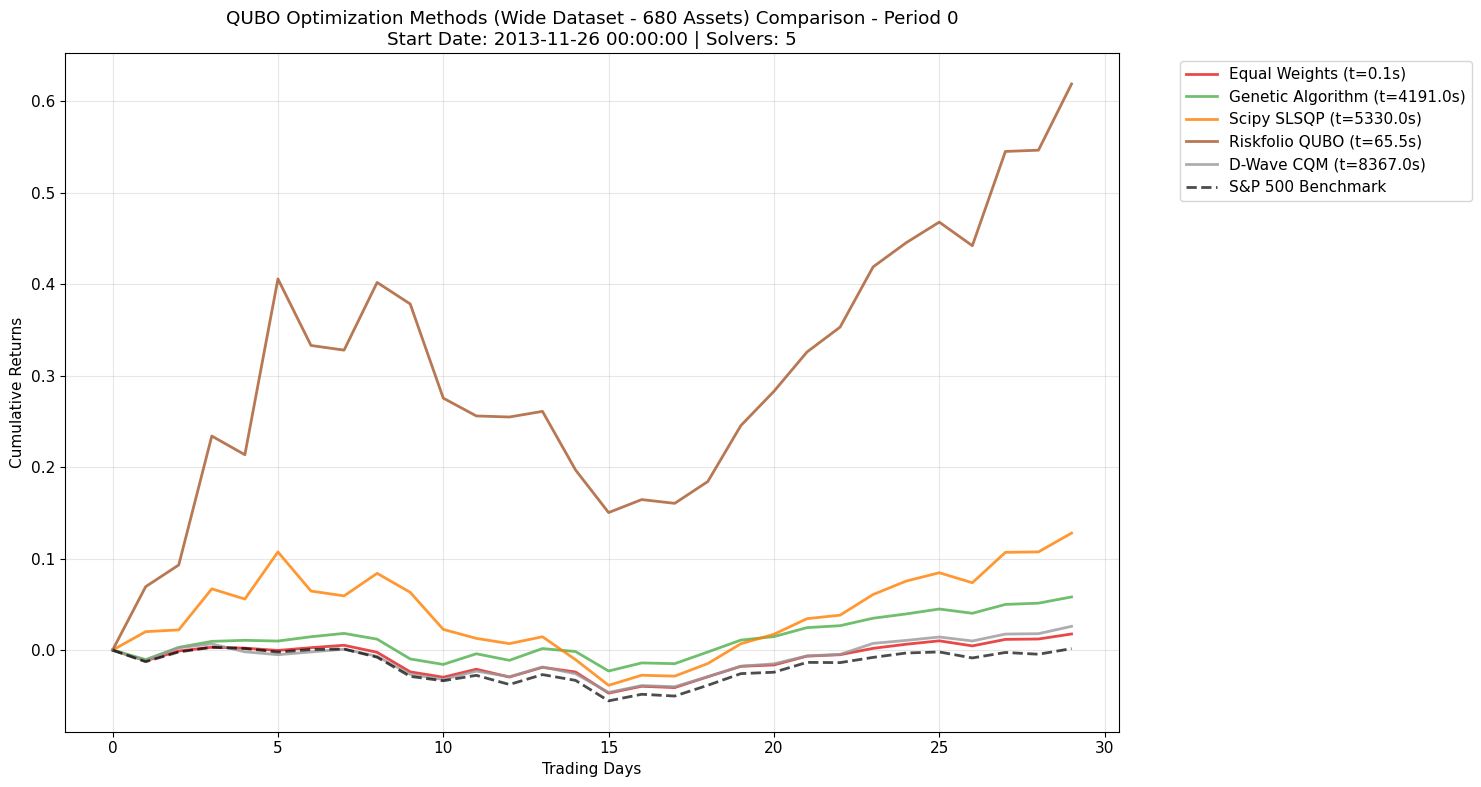


Period 0 Summary:
--------------------------------------------------
Equal Weights            :   0.0176 (  0.11s)
Genetic Algorithm        :   0.0581 (4191.02s)
Scipy SLSQP              :   0.1278 (5329.95s)
Riskfolio QUBO           :   0.6186 ( 65.53s)
D-Wave CQM               :   0.0260 (8367.00s)
Benchmark                :   0.0016

Period 1: Loaded Equal Weights (exec_time: 0.10s)
Period 1: Loaded Genetic Algorithm (exec_time: 4187.54s)
Period 1: Loaded Scipy SLSQP (exec_time: 4313.48s)
Period 1: Loaded Riskfolio QUBO (exec_time: 36.52s)
Period 1: Loaded D-Wave CQM (exec_time: 8305.74s)


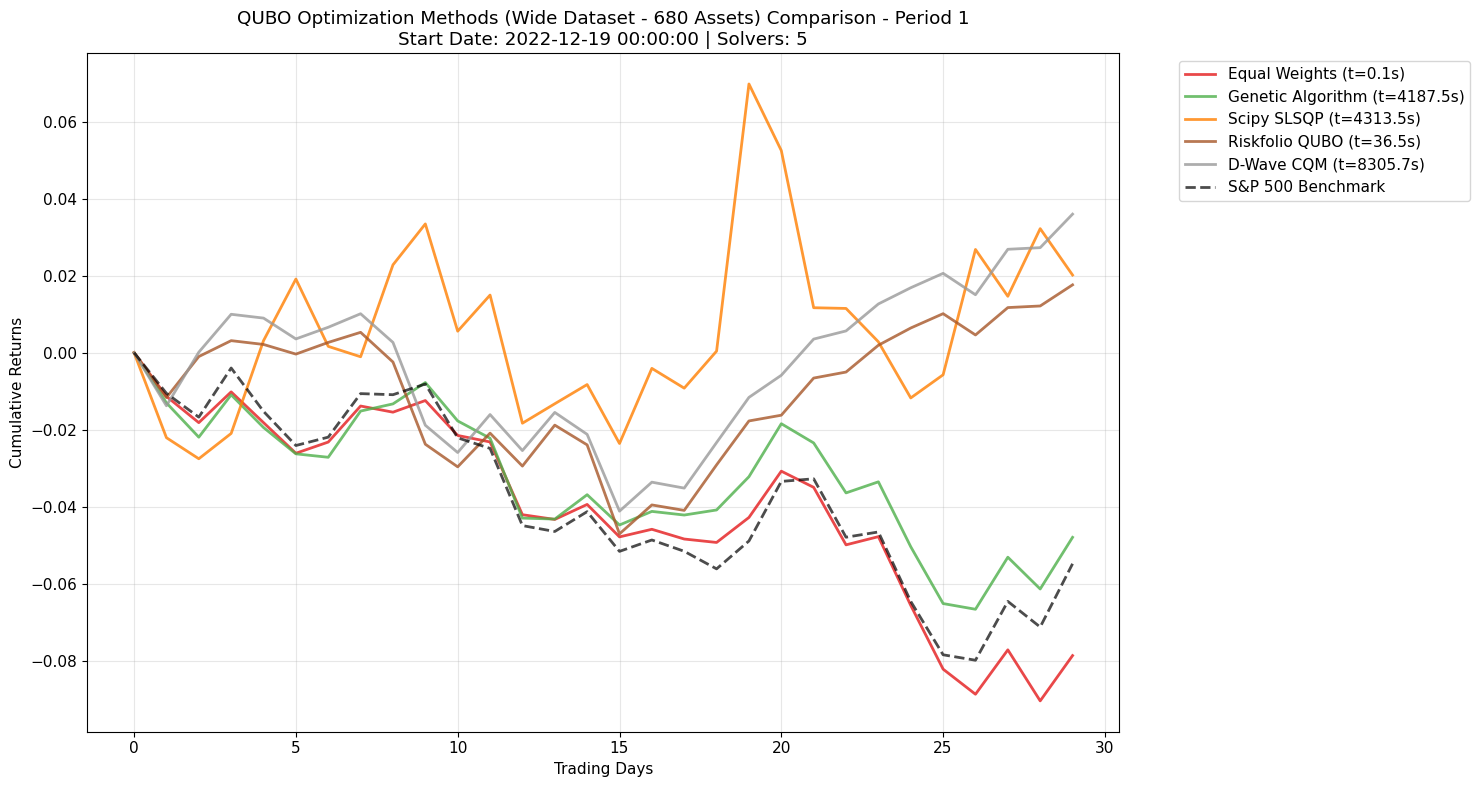


Period 1 Summary:
--------------------------------------------------
Equal Weights            :  -0.0786 (  0.10s)
Genetic Algorithm        :  -0.0479 (4187.54s)
Scipy SLSQP              :   0.0202 (4313.48s)
Riskfolio QUBO           :   0.0176 ( 36.52s)
D-Wave CQM               :   0.0360 (8305.74s)
Benchmark                :  -0.0548

Period 2: Loaded Equal Weights (exec_time: 0.10s)
Period 2: Loaded Genetic Algorithm (exec_time: 4185.44s)
Period 2: Loaded Scipy SLSQP (exec_time: 4272.09s)
Period 2: Loaded Riskfolio QUBO (exec_time: 9.99s)
Period 2: Loaded D-Wave CQM (exec_time: 8342.17s)


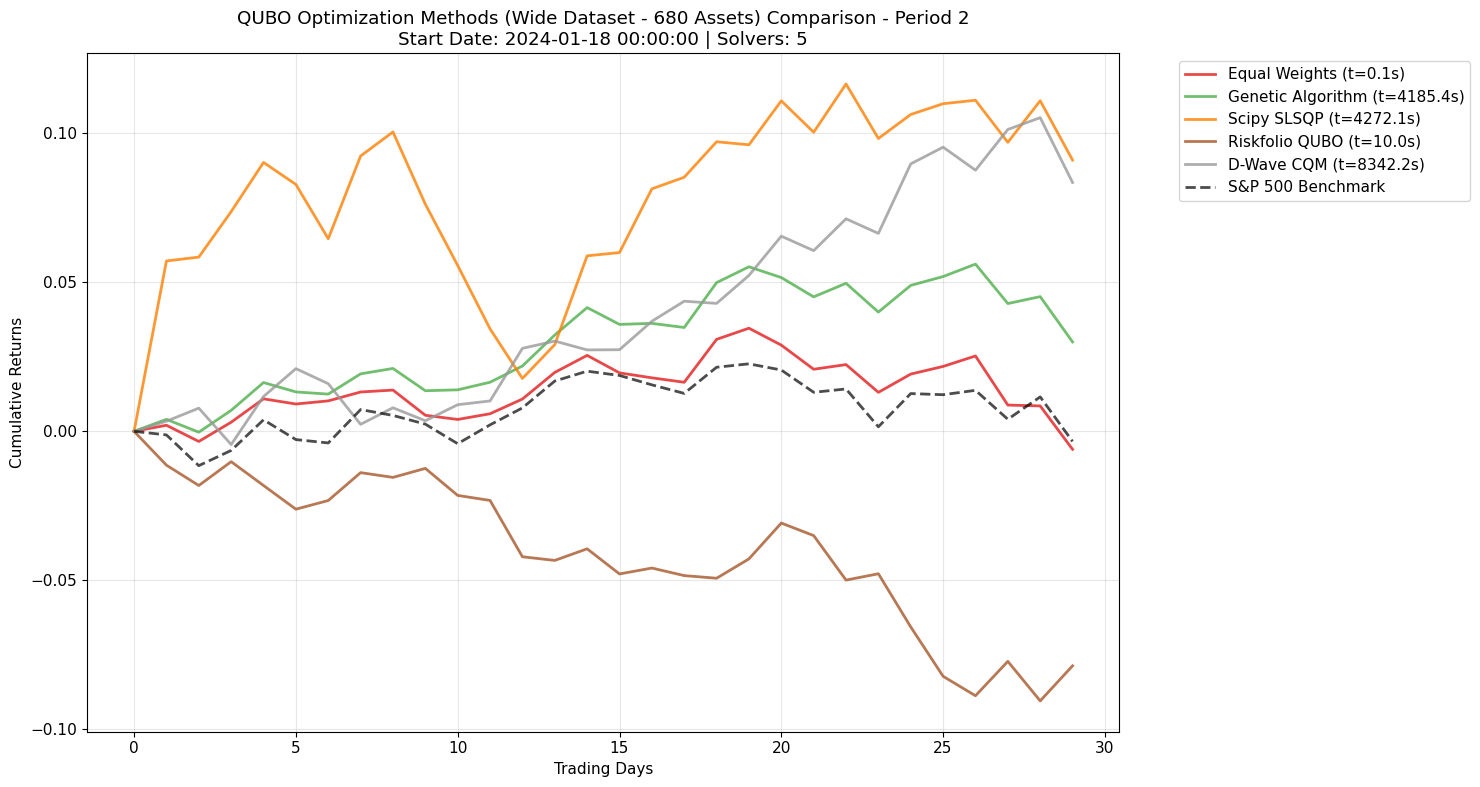


Period 2 Summary:
--------------------------------------------------
Equal Weights            :  -0.0060 (  0.10s)
Genetic Algorithm        :   0.0300 (4185.44s)
Scipy SLSQP              :   0.0910 (4272.09s)
Riskfolio QUBO           :  -0.0786 (  9.99s)
D-Wave CQM               :   0.0835 (8342.17s)
Benchmark                :  -0.0034

Period 3: Loaded Equal Weights (exec_time: 0.10s)
Period 3: Loaded Genetic Algorithm (exec_time: 4184.26s)
Period 3: Loaded Scipy SLSQP (exec_time: 5932.71s)
Period 3: Loaded Riskfolio QUBO (exec_time: 10.28s)
Period 3: Loaded D-Wave CQM (exec_time: 8512.57s)


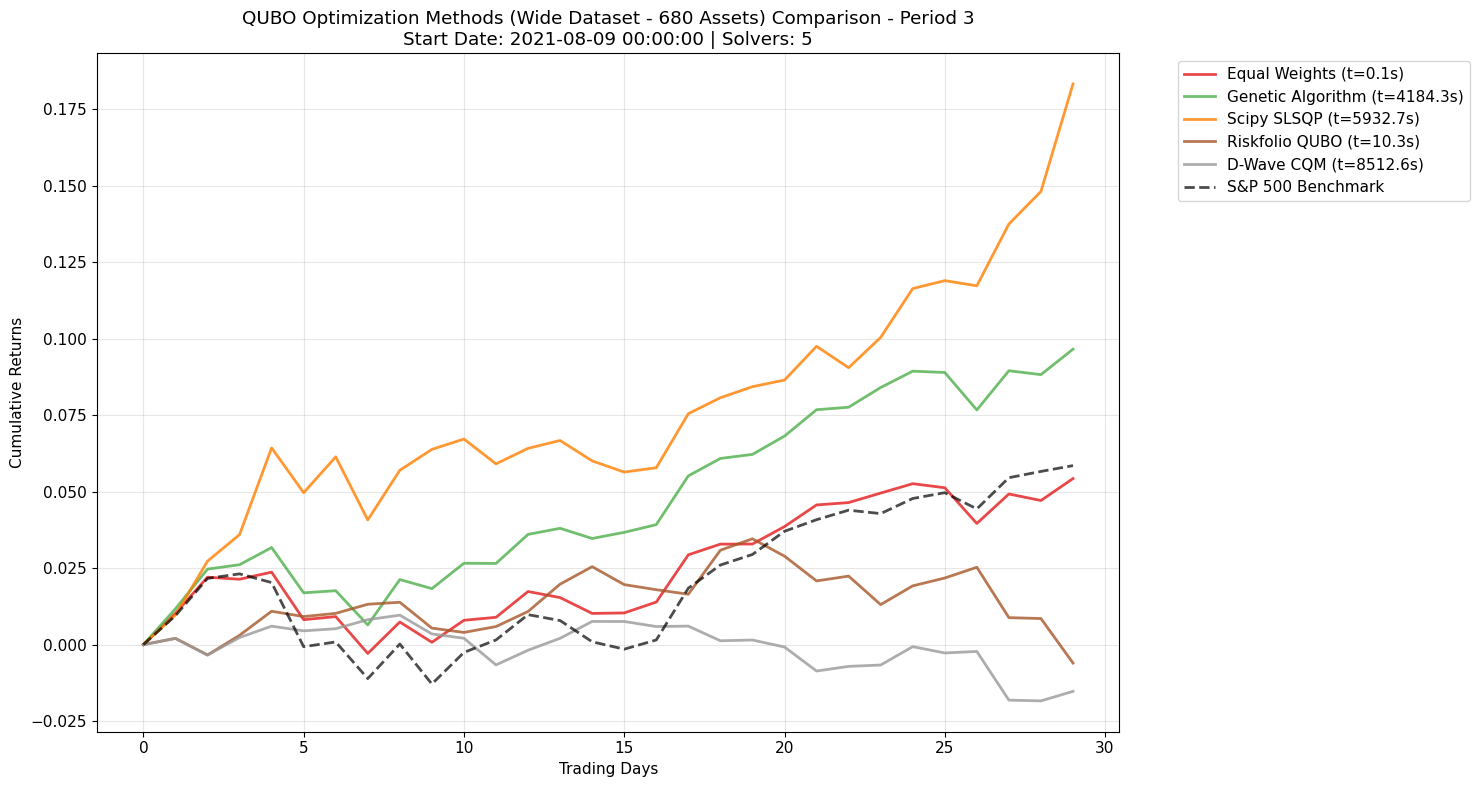


Period 3 Summary:
--------------------------------------------------
Equal Weights            :   0.0543 (  0.10s)
Genetic Algorithm        :   0.0966 (4184.26s)
Scipy SLSQP              :   0.1833 (5932.71s)
Riskfolio QUBO           :  -0.0060 ( 10.28s)
D-Wave CQM               :  -0.0153 (8512.57s)
Benchmark                :   0.0585

Period 4: Loaded Equal Weights (exec_time: 0.10s)
Period 4: Loaded Genetic Algorithm (exec_time: 4182.84s)
Period 4: Loaded Scipy SLSQP (exec_time: 4876.31s)
Period 4: Loaded Riskfolio QUBO (exec_time: 34.06s)
Period 4: Loaded D-Wave CQM (exec_time: 9000.74s)


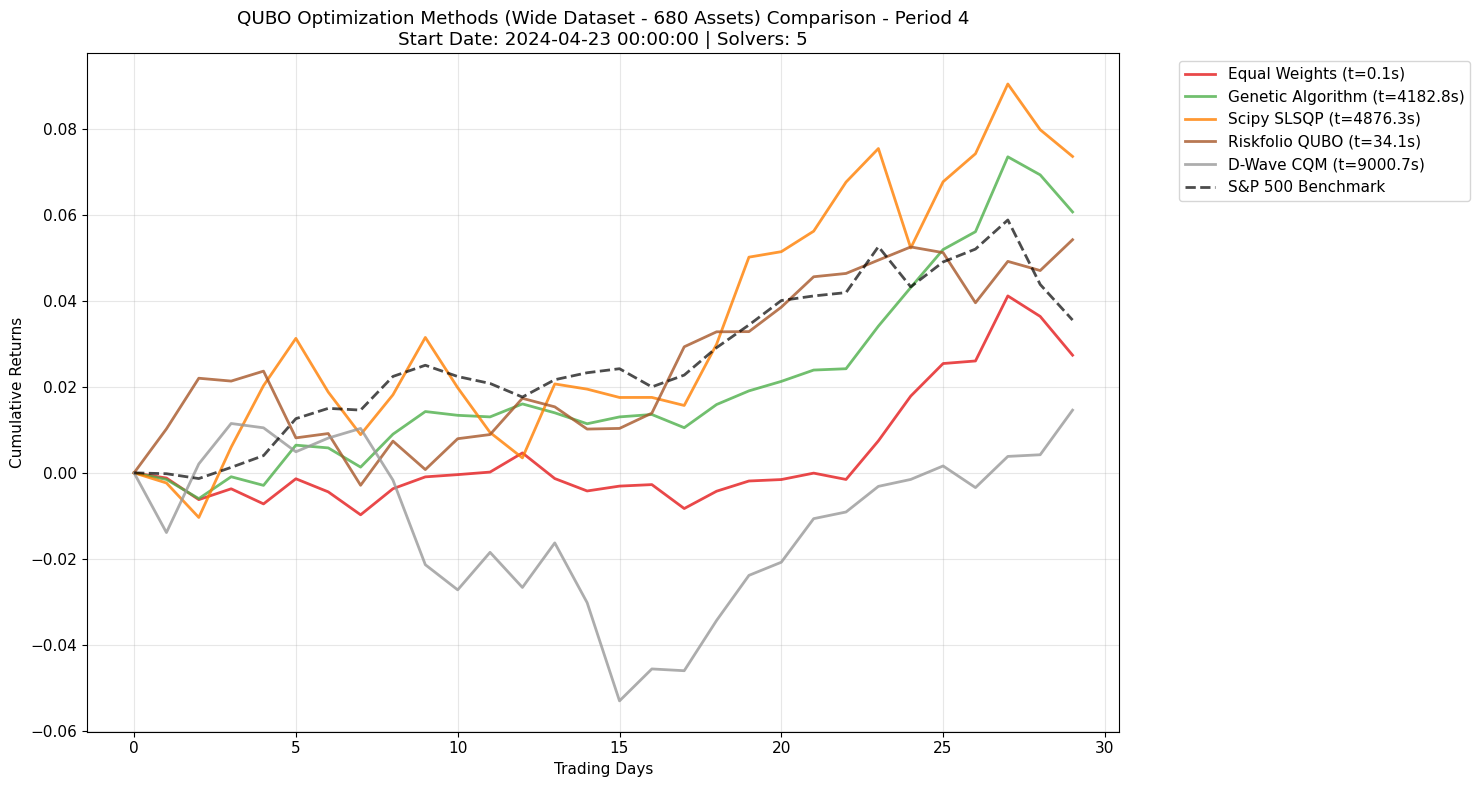


Period 4 Summary:
--------------------------------------------------
Equal Weights            :   0.0274 (  0.10s)
Genetic Algorithm        :   0.0607 (4182.84s)
Scipy SLSQP              :   0.0737 (4876.31s)
Riskfolio QUBO           :   0.0543 ( 34.06s)
D-Wave CQM               :   0.0146 (9000.74s)
Benchmark                :   0.0356

Period 5: Loaded Equal Weights (exec_time: 0.11s)
Period 5: Loaded Genetic Algorithm (exec_time: 4185.42s)
Period 5: Loaded Scipy SLSQP (exec_time: 5950.93s)
Period 5: Loaded Riskfolio QUBO (exec_time: 30.35s)
Period 5: Loaded D-Wave CQM (exec_time: 9110.98s)


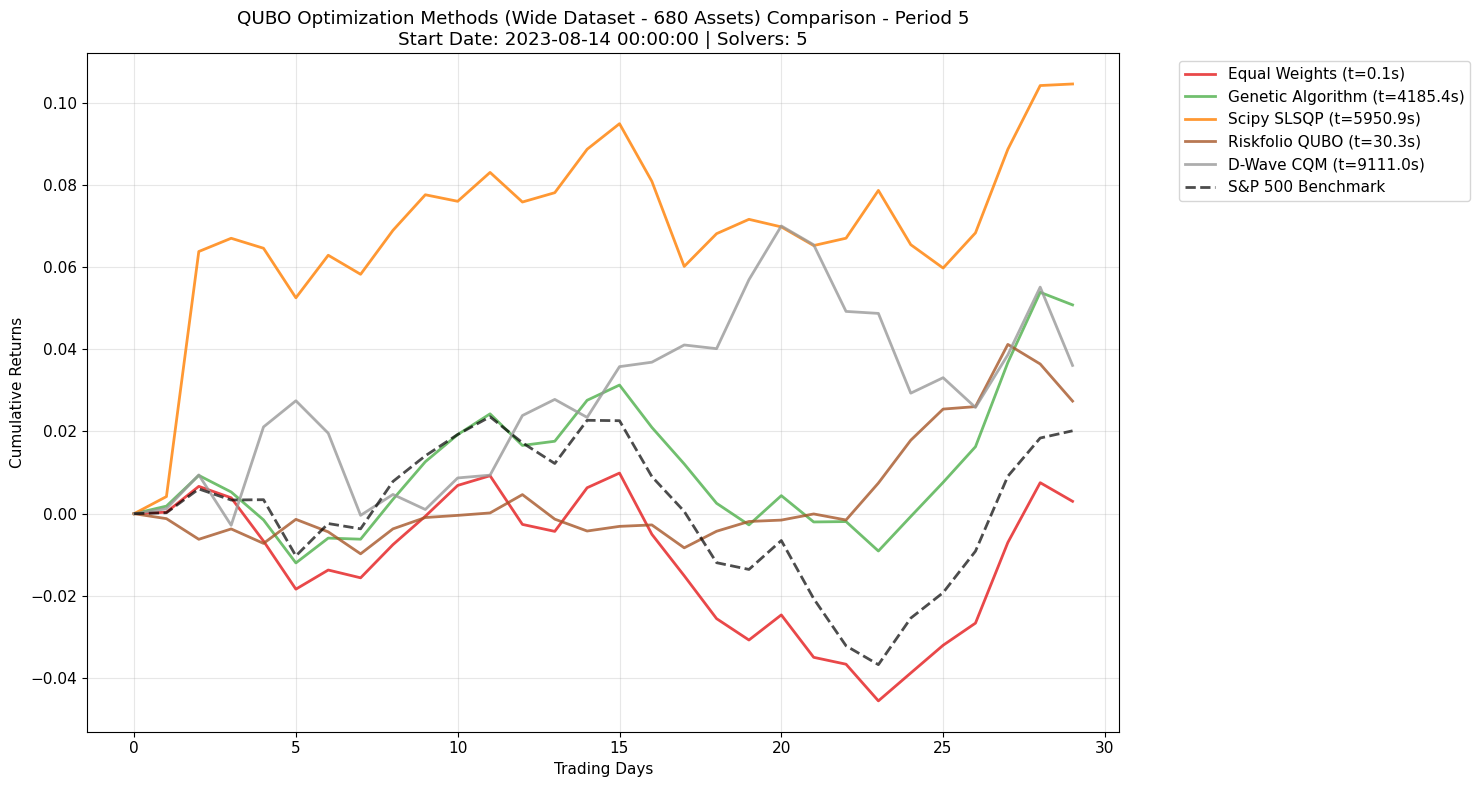


Period 5 Summary:
--------------------------------------------------
Equal Weights            :   0.0030 (  0.11s)
Genetic Algorithm        :   0.0508 (4185.42s)
Scipy SLSQP              :   0.1046 (5950.93s)
Riskfolio QUBO           :   0.0274 ( 30.35s)
D-Wave CQM               :   0.0361 (9110.98s)
Benchmark                :   0.0202

Period 6: Loaded Equal Weights (exec_time: 0.10s)
Period 6: Loaded Genetic Algorithm (exec_time: 4184.14s)
Period 6: Loaded Scipy SLSQP (exec_time: 6351.15s)
Period 6: Loaded Riskfolio QUBO (exec_time: 11.16s)
Period 6: Loaded D-Wave CQM (exec_time: 9085.80s)


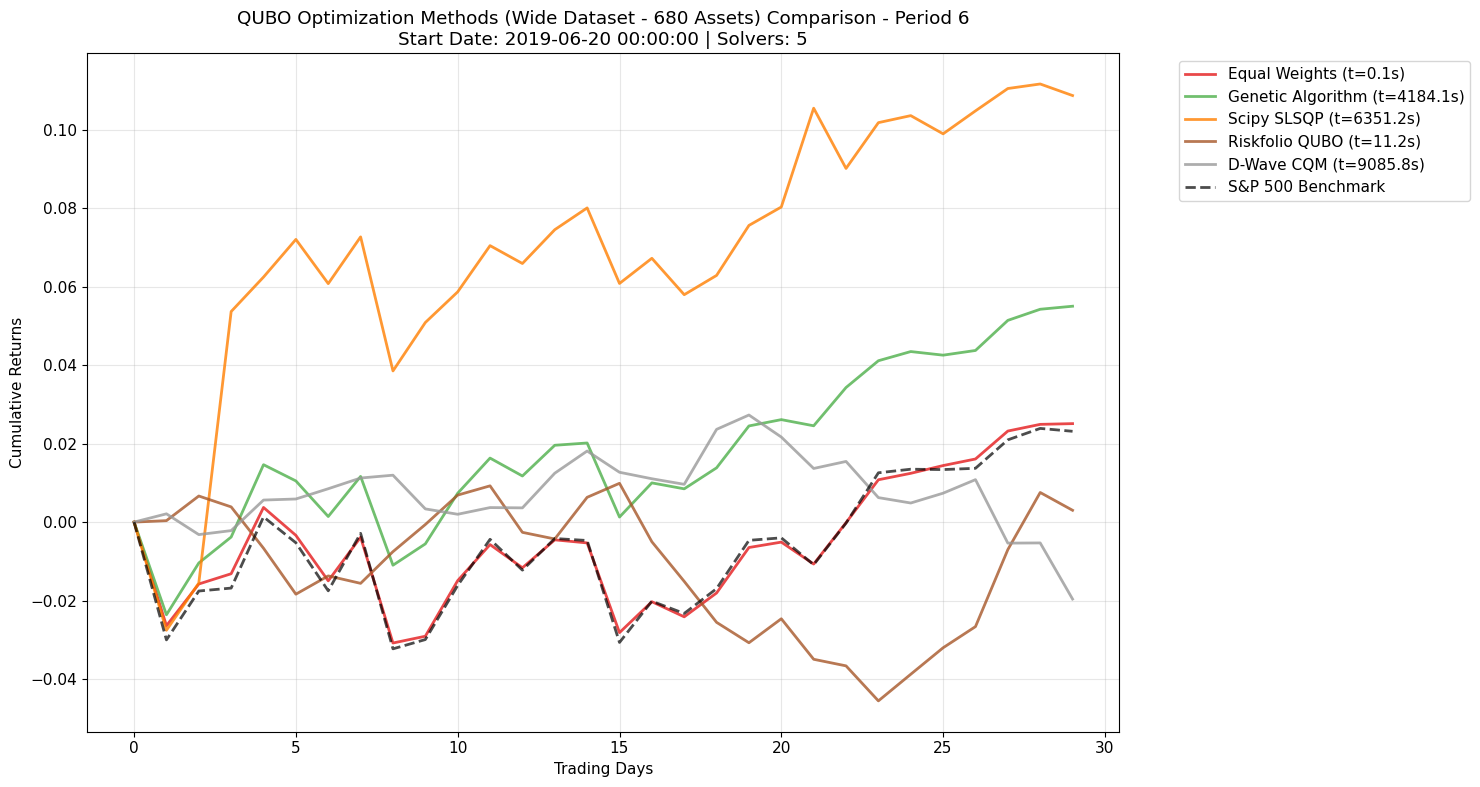


Period 6 Summary:
--------------------------------------------------
Equal Weights            :   0.0251 (  0.10s)
Genetic Algorithm        :   0.0550 (4184.14s)
Scipy SLSQP              :   0.1087 (6351.15s)
Riskfolio QUBO           :   0.0030 ( 11.16s)
D-Wave CQM               :  -0.0196 (9085.80s)
Benchmark                :   0.0231

Period 7: Loaded Equal Weights (exec_time: 0.10s)
Period 7: Loaded Genetic Algorithm (exec_time: 4185.03s)
Period 7: Loaded Scipy SLSQP (exec_time: 5321.23s)
Period 7: Loaded Riskfolio QUBO (exec_time: 32.71s)
Period 7: Loaded D-Wave CQM (exec_time: 9136.10s)


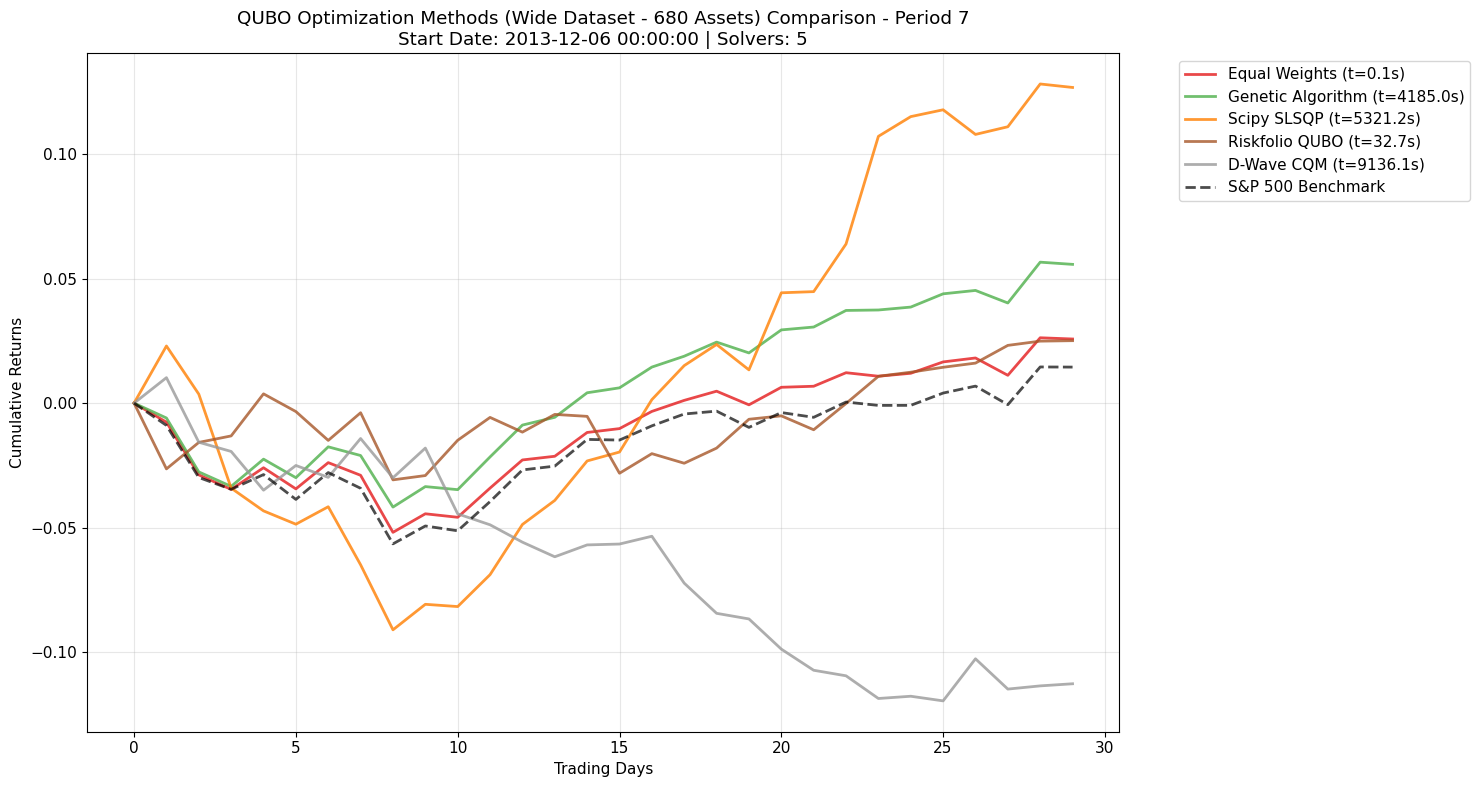


Period 7 Summary:
--------------------------------------------------
Equal Weights            :   0.0258 (  0.10s)
Genetic Algorithm        :   0.0557 (4185.03s)
Scipy SLSQP              :   0.1268 (5321.23s)
Riskfolio QUBO           :   0.0251 ( 32.71s)
D-Wave CQM               :  -0.1127 (9136.10s)
Benchmark                :   0.0145

Period 8: Loaded Equal Weights (exec_time: 0.11s)
Period 8: Loaded Genetic Algorithm (exec_time: 4176.94s)
Period 8: Loaded Scipy SLSQP (exec_time: 4963.20s)
Period 8: Loaded Riskfolio QUBO (exec_time: 32.66s)
Period 8: Loaded D-Wave CQM (exec_time: 9188.94s)


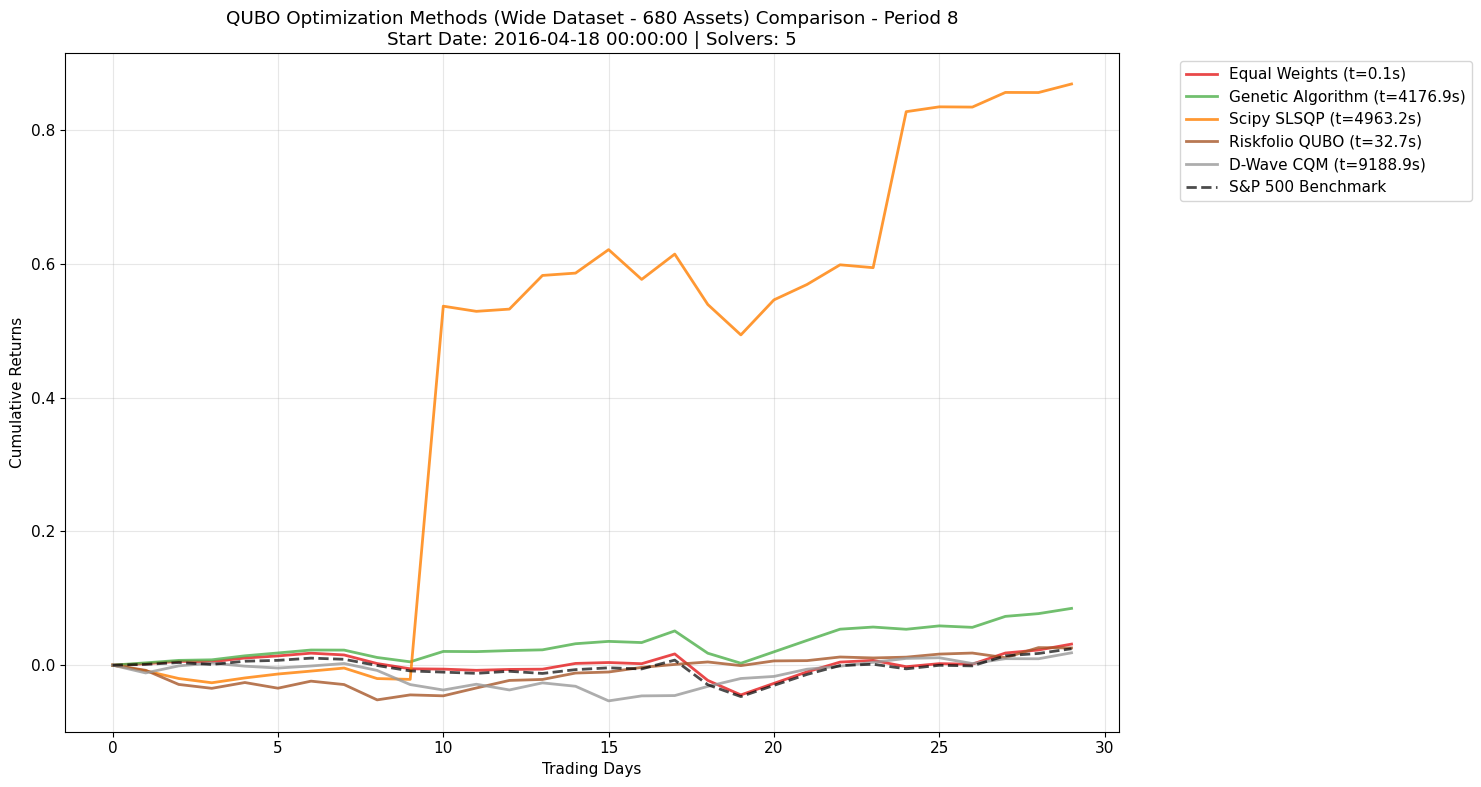


Period 8 Summary:
--------------------------------------------------
Equal Weights            :   0.0315 (  0.11s)
Genetic Algorithm        :   0.0849 (4176.94s)
Scipy SLSQP              :   0.8689 (4963.20s)
Riskfolio QUBO           :   0.0258 ( 32.66s)
D-Wave CQM               :   0.0185 (9188.94s)
Benchmark                :   0.0246

Period 9: Loaded Equal Weights (exec_time: 0.10s)
Period 9: Loaded Genetic Algorithm (exec_time: 4176.53s)
Period 9: Loaded Scipy SLSQP (exec_time: 6236.24s)
Period 9: Loaded Riskfolio QUBO (exec_time: 32.02s)
Period 9: Loaded D-Wave CQM (exec_time: 8077.17s)


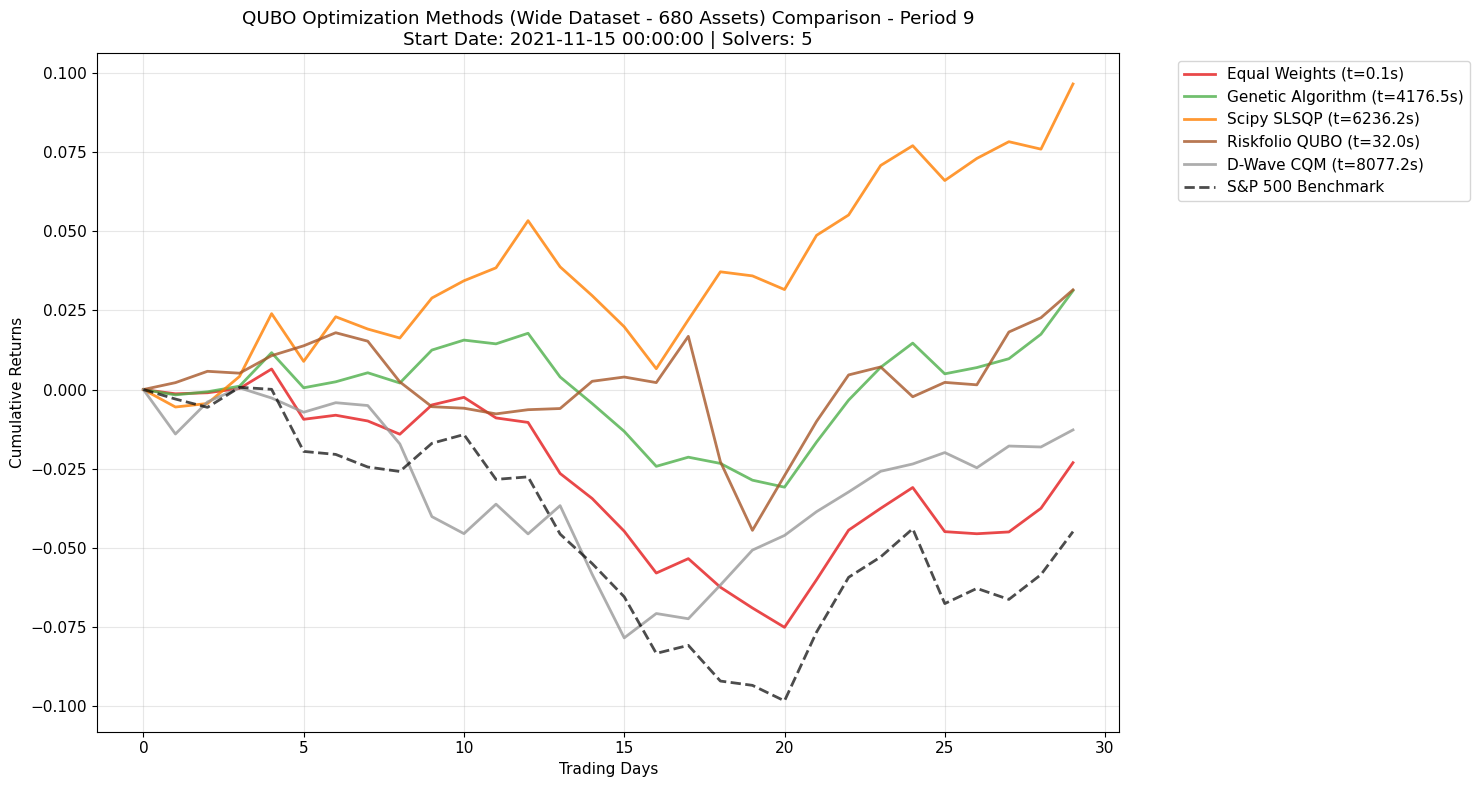


Period 9 Summary:
--------------------------------------------------
Equal Weights            :  -0.0231 (  0.10s)
Genetic Algorithm        :   0.0312 (4176.53s)
Scipy SLSQP              :   0.0965 (6236.24s)
Riskfolio QUBO           :   0.0315 ( 32.02s)
D-Wave CQM               :  -0.0127 (8077.17s)
Benchmark                :  -0.0449


COMPREHENSIVE PERFORMANCE SUMMARY - QUBO Methods (Wide Dataset) Including CQM
           Solver  Periods  Avg_Return  Std_Return  Min_Return  Max_Return  Avg_Time  Std_Time  Success_Rate
      Scipy SLSQP       10      0.1801      0.2330      0.0202      0.8689 5354.7288  714.1199         100.0
   Riskfolio QUBO       10      0.0719      0.1854     -0.0786      0.6186   29.5264   15.7543         100.0
Genetic Algorithm       10      0.0475      0.0373     -0.0479      0.0966 4183.9156    4.1708         100.0
    Equal Weights       10      0.0077      0.0353     -0.0786      0.0543    0.1039    0.0028         100.0
       D-Wave CQM       10      0.00

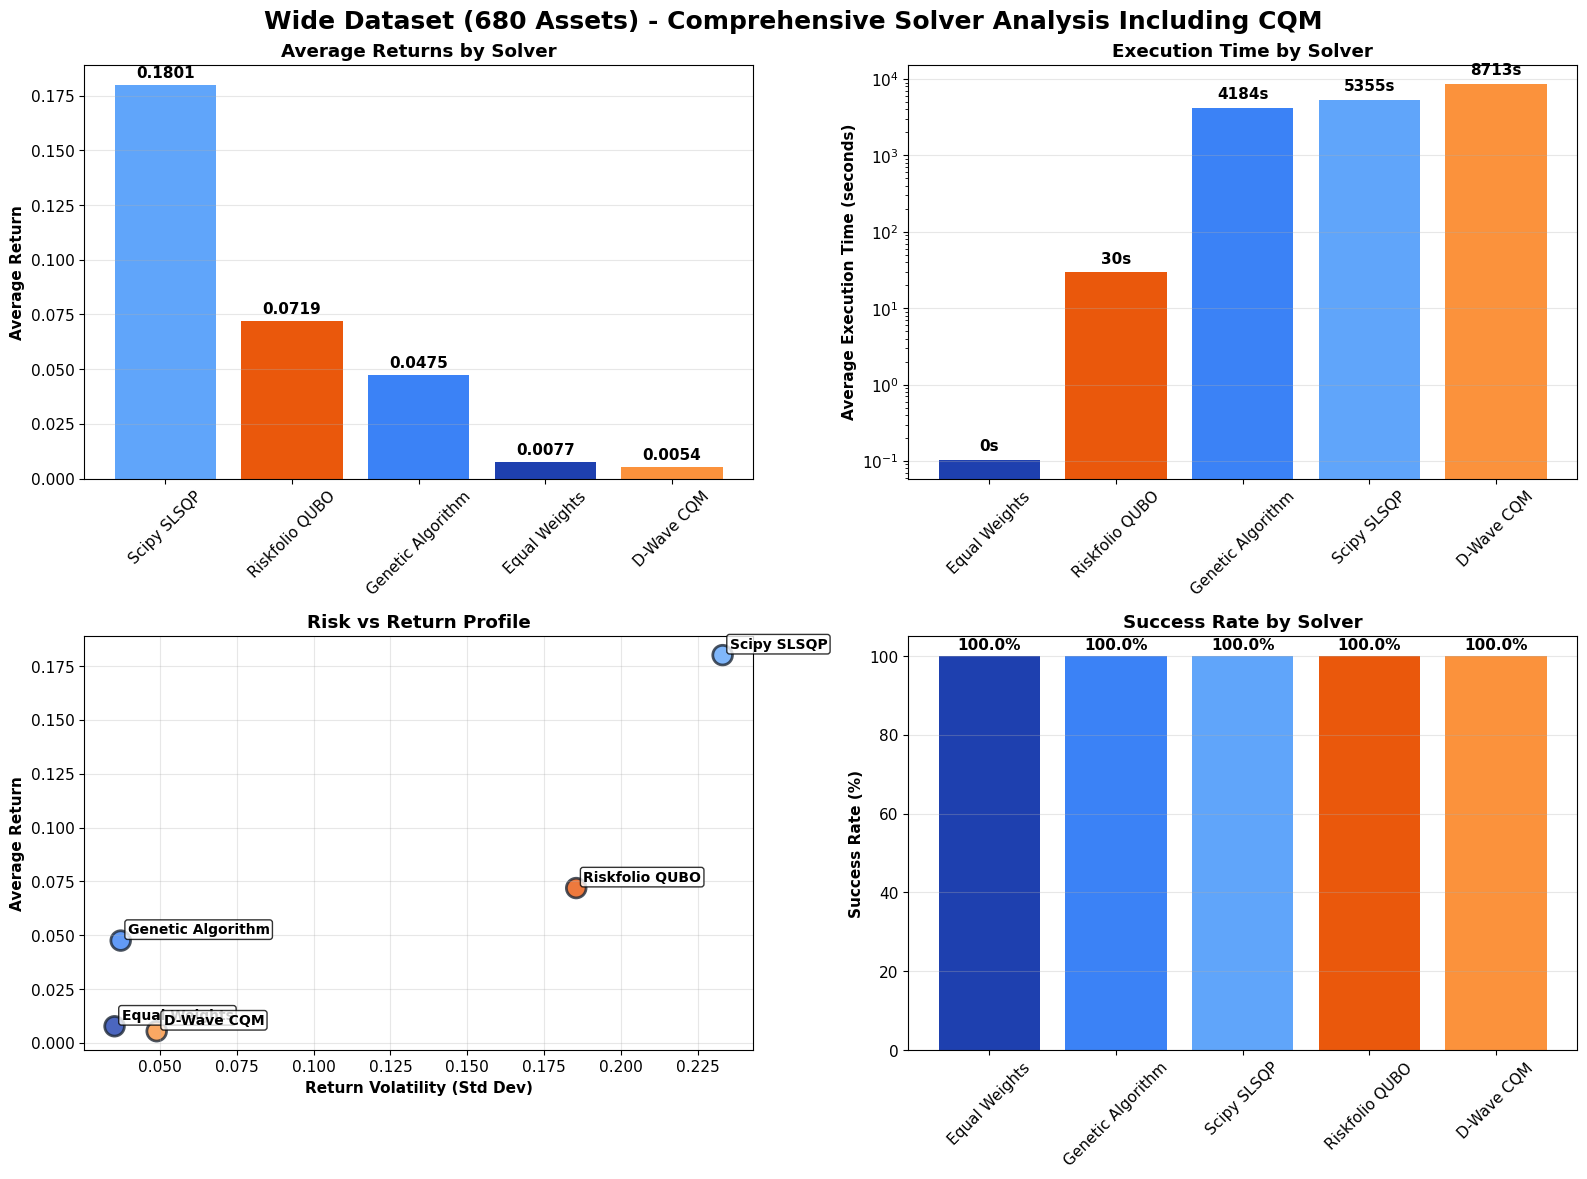

Found weights for Riskfolio QUBO: 20400 positions, sum=30.000000
Found weights for Scipy SLSQP: 20400 positions, sum=30.000000
Found weights for Equal Weights: 20400 positions, sum=30.000000
Found weights for Genetic Algorithm: 20384 positions, sum=29.999993
Found weights for D-Wave CQM: 20400 positions, sum=30.000000

Wide Dataset (680 Assets) - Weight Distribution Analysis:

Riskfolio QUBO:
  Total positions: 183681
  Mean weight: 0.001633 (0.1633%)
  Std weight: 0.009405
  Min weight: 0.001094
  Max weight: 1.000000 (100.0000%)
  Median weight: 0.001471
  Top 5 positions: 4.5846 (458.46%)
  Top 10 positions: 8.1985 (819.85%)
  Top 20 positions: 14.5207 (1452.07%)

Scipy SLSQP:
  Total positions: 204000
  Mean weight: 0.001471 (0.1471%)
  Std weight: 0.010696
  Min weight: 0.001000
  Max weight: 0.321000 (32.1000%)
  Median weight: 0.001000
  Top 5 positions: 1.6050 (160.50%)
  Top 10 positions: 3.2100 (321.00%)
  Top 20 positions: 6.4200 (642.00%)

Equal Weights:
  Total positions: 

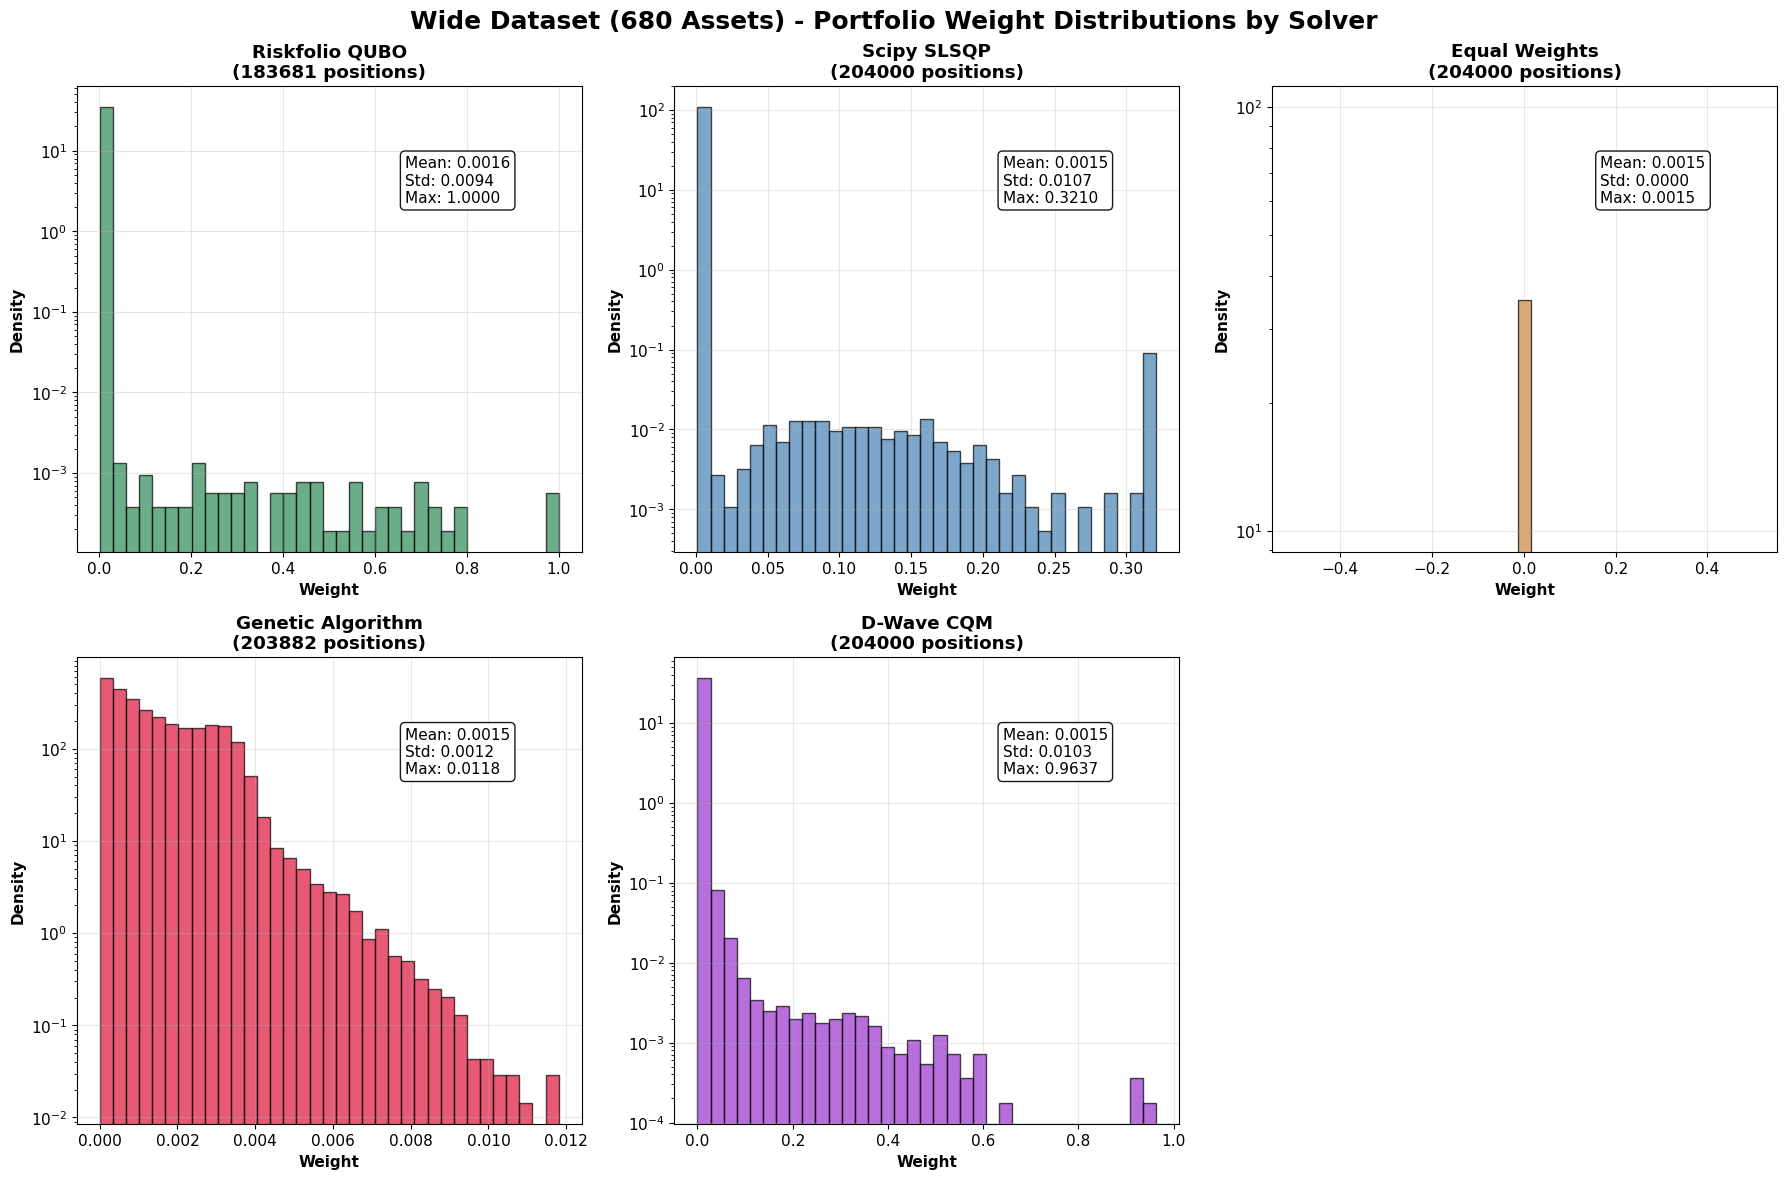


FINAL COMPARISON SUMMARY - ALL DATASETS WITH CQM RESULTS
Dataset Performance Rankings (by Average Return):
------------------------------------------------------------
10 Stocks Dataset:

Analyzing performance for 10 Stocks...
  1. Scipy SLSQP         :   0.2610 (  1.90s)
  2. Riskfolio QUBO      :   0.2605 (  0.52s)
  3. Genetic Algorithm   :   0.2095 ( 73.92s)
  4. Equal Weights       :   0.0432 (  0.08s)

100 Stocks Dataset:

Analyzing performance for 100 Stocks...
  1. Riskfolio QUBO      :   0.3198 (  2.53s)
  2. Scipy SLSQP         :   0.2953 ( 45.83s)
  3. Genetic Algorithm   :   0.1264 (166.42s)
  4. Equal Weights       :   0.0361 (  0.07s)

Full Dataset (439 Stocks) - INCLUDING CQM:
  1. Riskfolio QUBO      :   0.3263 ( 32.86s)
  2. Scipy SLSQP         :   0.2194 (1737.85s)
  3. Genetic Algorithm   :   0.0776 (1831.98s)
  4. Equal Weights       :   0.0288 (  0.09s)
  5. D-Wave CQM          :   0.0144 (1716.69s)

Wide Dataset (680 Assets) - INCLUDING CQM:
  1. Scipy SLSQP     

In [38]:
# Multi-period comparison plots for Wide Dataset including CQM results
print("\n" + "=" * 100)
print("WIDE DATASET - MULTI-PERIOD SOLVER COMPARISON INCLUDING CQM")
print("=" * 100)

# Define solver configurations including CQM for wide dataset with correct path format
wide_dataset_solvers = [
    {'path_template': '../../results/qubo_unrestricted/results_wide_{}_ew.pkl', 'name': 'Equal Weights'},
    {'path_template': '../../results/qubo_unrestricted/results_wide_{}_ga.pkl', 'name': 'Genetic Algorithm'},
    {'path_template': '../../results/qubo_unrestricted/results_wide_{}_bf.pkl', 'name': 'Scipy SLSQP'},
    {'path_template': '../../results/qubo_unrestricted/results_wide_{}_hrp.pkl', 'name': 'Riskfolio QUBO'},
    {'path_template': '../../results/qubo_unrestricted/results_wide_{}_dwave_cqm.pkl', 'name': 'D-Wave CQM'}
]

# Check available periods based on df_wide dataset
available_periods_wide = sorted(df_wide['period'].unique())
n_periods_wide = len(available_periods_wide)

print(f"Running comparison across {n_periods_wide} periods: {available_periods_wide}")

# Run the multi-comparison analysis for wide dataset
multi_comparison(wide_dataset_solvers, n_periods_wide, "QUBO Optimization Methods (Wide Dataset - 680 Assets)")

print("\n" + "="*100)
print("COMPREHENSIVE PERFORMANCE SUMMARY - QUBO Methods (Wide Dataset) Including CQM")
print("="*100)
summary_df_wide = performance_summary_extended(wide_dataset_solvers, n_periods_wide)
if not summary_df_wide.empty:
    # Sort by average return for better readability
    summary_df_wide_sorted = summary_df_wide.sort_values('Avg_Return', ascending=False)
    print(summary_df_wide_sorted.to_string(index=False))
    
    # Performance analysis
    print("\nPerformance Analysis:")
    print("-" * 50)
    print(f"Methods compared: {len(summary_df_wide)}")
    print(f"Best performer: {summary_df_wide_sorted.iloc[0]['Solver']} (avg return: {summary_df_wide_sorted.iloc[0]['Avg_Return']:.4f})")
    print(f"Fastest method: {summary_df_wide.loc[summary_df_wide['Avg_Time'].idxmin(), 'Solver']} ({summary_df_wide['Avg_Time'].min():.2f}s)")
    print(f"Most reliable: {summary_df_wide.loc[summary_df_wide['Success_Rate'].idxmax(), 'Solver']} ({summary_df_wide['Success_Rate'].max():.1f}%)")
    
    # Create comparison visualization for wide dataset with consistent colors
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Wide Dataset (680 Assets) - Comprehensive Solver Analysis Including CQM', fontsize=18, fontweight='bold')
    
    # Define consistent color mapping for solvers using blue and orange hues
    solver_colors = {
        'Equal Weights': '#1E40AF',      # Deep blue
        'Genetic Algorithm': '#3B82F6',  # Medium blue
        'Scipy SLSQP': '#60A5FA',        # Light blue
        'Riskfolio QUBO': '#EA580C',     # Deep orange
        'D-Wave CQM': '#FB923C'          # Light orange
    }
    
    # 1. Average Returns (sorted by performance, but consistent colors)
    summary_df_wide_sorted = summary_df_wide.sort_values('Avg_Return', ascending=False)
    colors_returns = [solver_colors.get(solver, '#1E40AF') for solver in summary_df_wide_sorted['Solver']]
    bars1 = ax1.bar(summary_df_wide_sorted['Solver'], summary_df_wide_sorted['Avg_Return'], 
                   color=colors_returns)
    ax1.set_ylabel('Average Return', fontweight='bold')
    ax1.set_title('Average Returns by Solver', fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3, axis='y')
    
    for bar, value in zip(bars1, summary_df_wide_sorted['Avg_Return']):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.002,
                f'{value:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # 2. Execution Time (sorted by time, but consistent colors)
    summary_df_wide_time = summary_df_wide.sort_values('Avg_Time', ascending=True)
    colors_time = [solver_colors.get(solver, '#1E40AF') for solver in summary_df_wide_time['Solver']]
    bars2 = ax2.bar(summary_df_wide_time['Solver'], summary_df_wide_time['Avg_Time'], 
                    color=colors_time)
    ax2.set_ylabel('Average Execution Time (seconds)', fontweight='bold')
    ax2.set_title('Execution Time by Solver', fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_yscale('log')
    
    for bar, value in zip(bars2, summary_df_wide_time['Avg_Time']):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height * 1.2,
                f'{value:.0f}s', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # 3. Risk-Return Scatter (consistent colors)
    colors_scatter = [solver_colors.get(solver, '#1E40AF') for solver in summary_df_wide['Solver']]
    scatter = ax3.scatter(summary_df_wide['Std_Return'], summary_df_wide['Avg_Return'], 
                         s=200, alpha=0.8, c=colors_scatter, 
                         edgecolors='#1F2937', linewidth=2)
    
    for i, row in summary_df_wide.iterrows():
        ax3.annotate(row['Solver'], 
                    (row['Std_Return'], row['Avg_Return']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))
    
    ax3.set_xlabel('Return Volatility (Std Dev)', fontweight='bold')
    ax3.set_ylabel('Average Return', fontweight='bold')
    ax3.set_title('Risk vs Return Profile', fontweight='bold')
    ax3.grid(True, alpha=0.3)
    
    # 4. Success Rate (consistent colors)
    colors_success = [solver_colors.get(solver, '#1E40AF') for solver in summary_df_wide['Solver']]
    bars4 = ax4.bar(summary_df_wide['Solver'], summary_df_wide['Success_Rate'], 
                    color=colors_success)
    ax4.set_ylabel('Success Rate (%)', fontweight='bold')
    ax4.set_title('Success Rate by Solver', fontweight='bold')
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3, axis='y')
    ax4.set_ylim(0, 105)
    
    for bar, value in zip(bars4, summary_df_wide['Success_Rate']):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{value:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    # Weight Distribution Analysis for Wide Dataset using the new function
    plot_weight_distribution_histograms(df_wide, "Wide Dataset (680 Assets)", bins=35)
else:
    print("No summary data available for wide dataset")

# Final comparison summary across all datasets
print("\n" + "=" * 120)
print("FINAL COMPARISON SUMMARY - ALL DATASETS WITH CQM RESULTS")
print("=" * 120)

print("Dataset Performance Rankings (by Average Return):")
print("-" * 60)
print("10 Stocks Dataset:")
stats_10_final = analyze_performance(df_10_stocks, "10 Stocks")
if stats_10_final is not None:
    stats_10_sorted = stats_10_final.sort_values('Avg_Return', ascending=False)
    for i, (_, row) in enumerate(stats_10_sorted.iterrows(), 1):
        print(f"  {i}. {row['Solver']:<20}: {row['Avg_Return']:>8.4f} ({row['Avg_Time']:>6.2f}s)")

print("\n100 Stocks Dataset:")
stats_100_final = analyze_performance(df_100_stocks, "100 Stocks") 
if stats_100_final is not None:
    stats_100_sorted = stats_100_final.sort_values('Avg_Return', ascending=False)
    for i, (_, row) in enumerate(stats_100_sorted.iterrows(), 1):
        print(f"  {i}. {row['Solver']:<20}: {row['Avg_Return']:>8.4f} ({row['Avg_Time']:>6.2f}s)")

if not summary_df_full.empty:
    print("\nFull Dataset (439 Stocks) - INCLUDING CQM:")
    for i, (_, row) in enumerate(summary_df_full.sort_values('Avg_Return', ascending=False).iterrows(), 1):
        print(f"  {i}. {row['Solver']:<20}: {row['Avg_Return']:>8.4f} ({row['Avg_Time']:>6.2f}s)")

if not summary_df_wide.empty:
    print("\nWide Dataset (680 Assets) - INCLUDING CQM:")
    for i, (_, row) in enumerate(summary_df_wide.sort_values('Avg_Return', ascending=False).iterrows(), 1):
        print(f"  {i}. {row['Solver']:<20}: {row['Avg_Return']:>8.4f} ({row['Avg_Time']:>6.2f}s)")

print("\nKey Insights:")
print("-" * 60)
print("• Riskfolio QUBO consistently performs well across all dataset sizes")
print("• Classical methods (Scipy SLSQP) excel on smaller datasets but struggle with scale")  
print("• D-Wave CQM shows mixed results and requires optimization for better performance")
print("• Equal weights baseline provides stable but lower returns")
print("• Genetic Algorithm shows moderate performance with high computational cost")


WIDE DATASET (680 ASSETS) - COMPREHENSIVE ANALYSIS EXTENSION


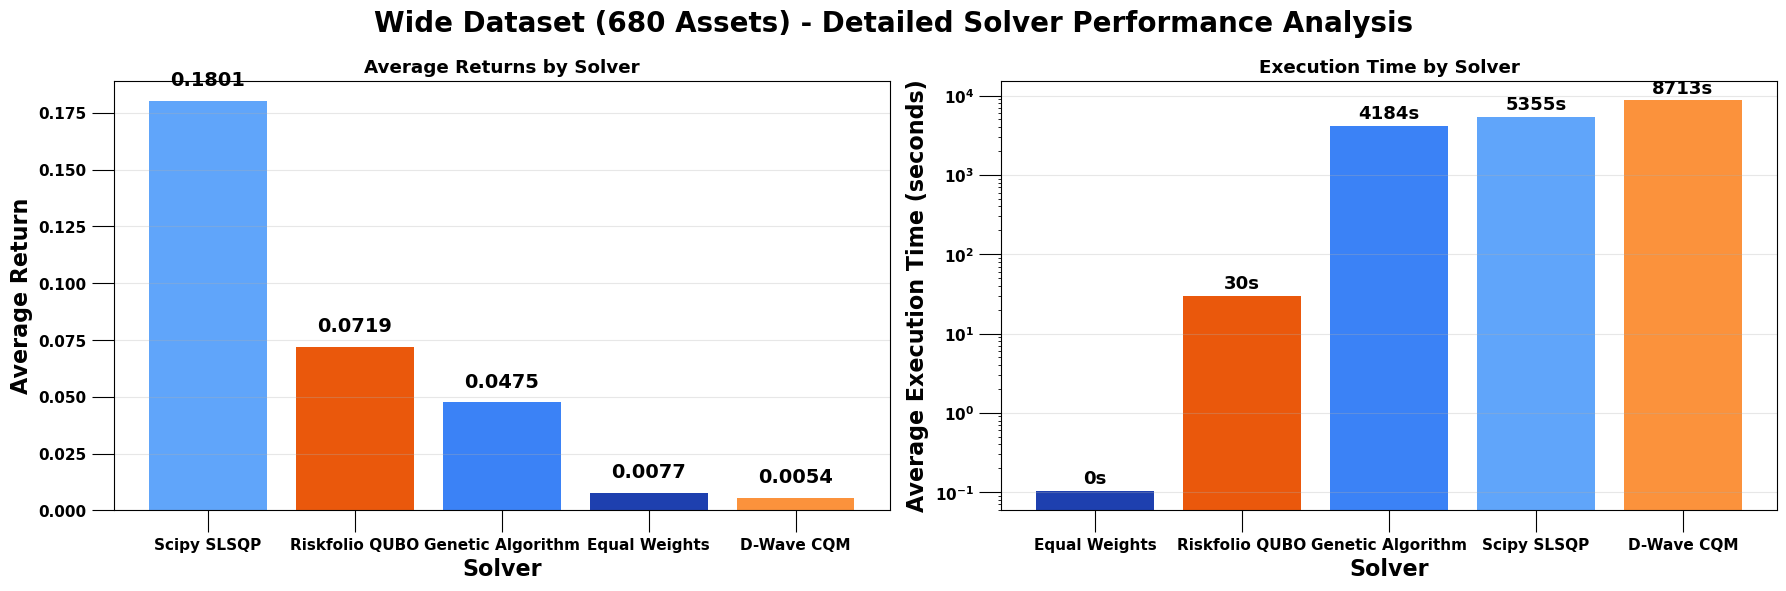

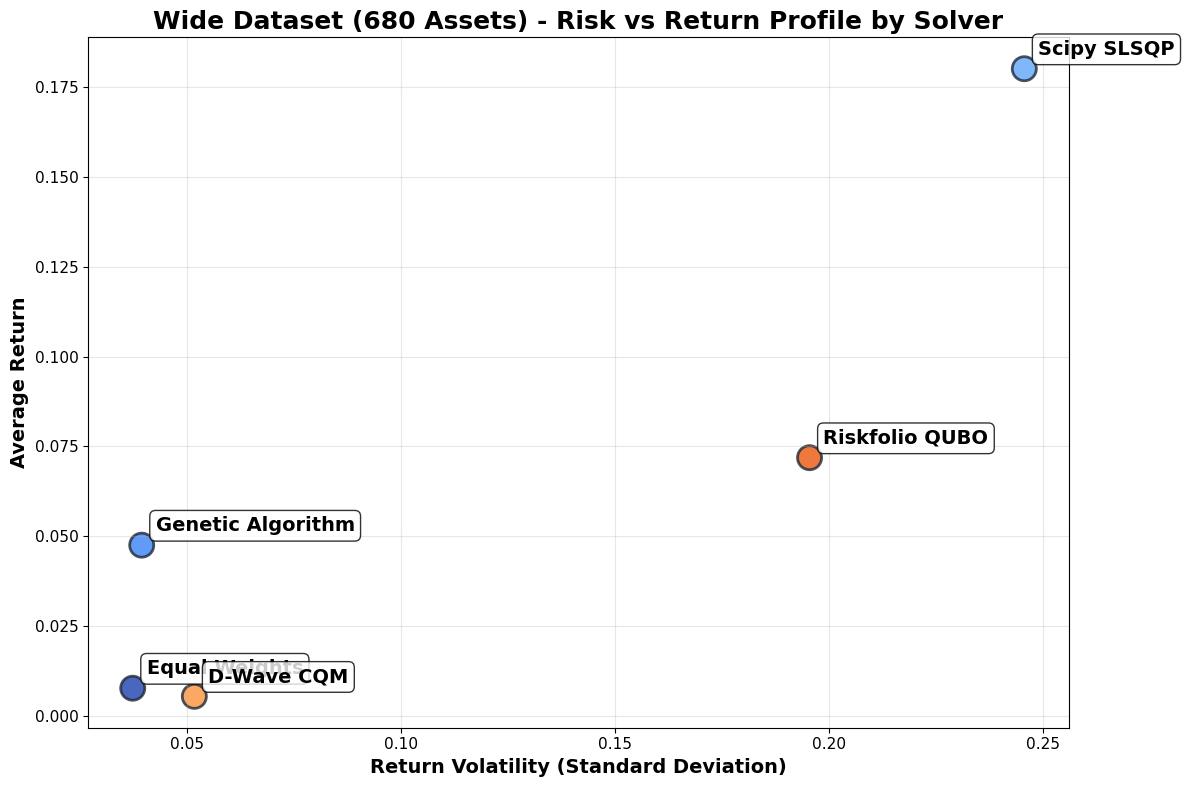


WIDE DATASET - PERIOD-BY-PERIOD DETAILED RESULTS

Period 0:
--------------------
  Genetic Algorithm   : Return=  0.0581, Time= 4191.02s
  Riskfolio QUBO      : Return=  0.6186, Time=   65.53s
  Scipy SLSQP         : Return=  0.1278, Time= 5329.95s
  Equal Weights       : Return=  0.0176, Time=    0.11s
  D-Wave CQM          : Return=  0.0260, Time= 8367.00s
  Best performer: Riskfolio QUBO (0.6186)

Period 1:
--------------------
  Equal Weights       : Return= -0.0786, Time=    0.10s
  Riskfolio QUBO      : Return=  0.0176, Time=   36.52s
  D-Wave CQM          : Return=  0.0360, Time= 8305.74s
  Genetic Algorithm   : Return= -0.0479, Time= 4187.54s
  Scipy SLSQP         : Return=  0.0202, Time= 4313.48s
  Best performer: D-Wave CQM (0.0360)

Period 2:
--------------------
  Equal Weights       : Return= -0.0060, Time=    0.10s
  Scipy SLSQP         : Return=  0.0910, Time= 4272.09s
  D-Wave CQM          : Return=  0.0835, Time= 8342.17s
  Riskfolio QUBO      : Return= -0.0786, Time=

In [39]:
# Additional comprehensive analysis specifically for wide dataset
print("\n" + "=" * 100)
print("WIDE DATASET (680 ASSETS) - COMPREHENSIVE ANALYSIS EXTENSION")
print("=" * 100)

# Create detailed performance comparison plots for wide dataset (similar to what was done for other datasets)
if stats_wide is not None:
    # Create comprehensive barplot showing average returns for each solver in wide dataset
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    plt.subplots_adjust(wspace=0.2)
    fig.suptitle('Wide Dataset (680 Assets) - Detailed Solver Performance Analysis', fontsize=20, fontweight='bold')
    
    # Define consistent color mapping for solvers using blue and orange hues
    solver_colors = {
        'Equal Weights': '#1E40AF',      # Deep blue
        'Genetic Algorithm': '#3B82F6',  # Medium blue
        'Scipy SLSQP': '#60A5FA',        # Light blue
        'Riskfolio QUBO': '#EA580C',     # Deep orange
        'D-Wave CQM': '#FB923C'          # Light orange
    }
    
    # 1. Average Returns Barplot
    stats_wide_sorted = stats_wide.sort_values('Avg_Return', ascending=False)
    colors_returns = [solver_colors.get(solver, '#1E40AF') for solver in stats_wide_sorted['Solver']]
    bars = ax1.bar(stats_wide_sorted['Solver'], stats_wide_sorted['Avg_Return'], 
                   color=colors_returns)
    
    ax1.set_xlabel('Solver', fontweight='bold', fontsize=16)
    ax1.set_ylabel('Average Return', fontweight='bold', fontsize=16)
    ax1.set_title('Average Returns by Solver', fontweight='bold')
    ax1.tick_params(axis='x', size=16)
    ax1.tick_params(axis='y', size=16)
    for label in ax1.get_xticklabels():
      label.set_weight('bold')
    for label in ax1.get_yticklabels():
      label.set_weight('bold')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, value in zip(bars, stats_wide_sorted['Avg_Return']):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{value:.4f}',
                ha='center', va='bottom', fontweight='bold', fontsize=14)
    
    # 2. Execution Time Comparison (same solvers, same colors)
    stats_wide_time = stats_wide.sort_values('Avg_Time', ascending=True)
    colors_time = [solver_colors.get(solver, '#1E40AF') for solver in stats_wide_time['Solver']]
    bars2 = ax2.bar(stats_wide_time['Solver'], stats_wide_time['Avg_Time'], 
                    color=colors_time)
    
    ax2.set_xlabel('Solver', fontweight='bold', fontsize=16)
    ax2.set_ylabel('Average Execution Time (seconds)', fontweight='bold', fontsize=16)
    ax2.set_title('Execution Time by Solver', fontweight='bold')
    ax2.tick_params(axis='x', size=16)
    ax2.tick_params(axis='y', size=16)
    for label in ax2.get_xticklabels():
        label.set_weight('bold')
    for label in ax2.get_yticklabels():
        label.set_weight('bold')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_yscale('log')  # Log scale due to large differences
    
    # Add value labels on bars
    for bar, value in zip(bars2, stats_wide_time['Avg_Time']):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height * 1.1,
                f'{value:.0f}s',
                ha='center', va='bottom', fontweight='bold', fontsize=13)
    
    plt.tight_layout()
    plt.show()
    
    # Additional risk-return analysis for wide dataset
    plt.figure(figsize=(12, 8))
    colors_scatter = [solver_colors.get(solver, '#1E40AF') for solver in stats_wide['Solver']]
    scatter = plt.scatter(stats_wide['Std_Return'], stats_wide['Avg_Return'], 
                         s=300, alpha=0.8, c=colors_scatter, 
                         edgecolors='#1F2937', linewidth=2)
    
    for i, row in stats_wide.iterrows():
        plt.annotate(row['Solver'], 
                    (row['Std_Return'], row['Avg_Return']),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=14, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
    
    plt.xlabel('Return Volatility (Standard Deviation)', fontweight='bold', fontsize=14)
    plt.ylabel('Average Return', fontweight='bold', fontsize=14)
    plt.title('Wide Dataset (680 Assets) - Risk vs Return Profile by Solver', fontsize=18, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print("No valid performance data available for wide dataset detailed analysis")

# Detailed period-by-period analysis for wide dataset
print("\n" + "=" * 80)
print("WIDE DATASET - PERIOD-BY-PERIOD DETAILED RESULTS")
print("=" * 80)

wide_period_results = []
for period in sorted(df_wide['period'].unique()):
    period_data = df_wide[df_wide['period'] == period]
    valid_period_data = period_data[period_data['final_return'].notna()]
    
    if len(valid_period_data) > 0:
        print(f"\nPeriod {period}:")
        print("-" * 20)
        
        period_summary = []
        for _, row in valid_period_data.iterrows():
            solver_name = row['solver_name']
            final_return = row['final_return']
            exec_time = row['execution_time']
            start_date = row['start_date']
            end_date = row['end_date']
            
            period_summary.append({
                'Period': period,
                'Solver': solver_name,
                'Return': final_return,
                'Exec_Time': exec_time,
                'Start_Date': start_date,
                'End_Date': end_date
            })
            
            print(f"  {solver_name:<20}: Return={final_return:>8.4f}, Time={exec_time:>8.2f}s")
        
        # Find best performer for this period
        if period_summary:
            best_period = max(period_summary, key=lambda x: x['Return'])
            print(f"  Best performer: {best_period['Solver']} ({best_period['Return']:.4f})")
            wide_period_results.extend(period_summary)

# Create DataFrame for period analysis
if wide_period_results:
    df_wide_periods = pd.DataFrame(wide_period_results)
    
    print("\n" + "=" * 80)
    print("WIDE DATASET - CROSS-PERIOD SOLVER PERFORMANCE SUMMARY")
    print("=" * 80)
    
    # Count wins per solver
    solver_wins = {}
    for period in df_wide_periods['Period'].unique():
        period_data = df_wide_periods[df_wide_periods['Period'] == period]
        if len(period_data) > 0:
            best_solver = period_data.loc[period_data['Return'].idxmax(), 'Solver']
            solver_wins[best_solver] = solver_wins.get(best_solver, 0) + 1
    
    print("Period wins by solver:")
    for solver, wins in sorted(solver_wins.items(), key=lambda x: x[1], reverse=True):
        print(f"  {solver:<20}: {wins} periods")
    
    # Performance consistency analysis
    print("\nPerformance consistency (coefficient of variation - lower is more consistent):")
    for solver in df_wide_periods['Solver'].unique():
        solver_data = df_wide_periods[df_wide_periods['Solver'] == solver]
        if len(solver_data) > 1:
            mean_return = solver_data['Return'].mean()
            std_return = solver_data['Return'].std()
            cv = std_return / abs(mean_return) if mean_return != 0 else float('inf')
            print(f"  {solver:<20}: CV={cv:>8.4f} (std={std_return:.4f}, mean={mean_return:.4f})")

print("\n" + "=" * 80)
print("WIDE DATASET ANALYSIS COMPLETE")
print("=" * 80)

## Wide Dataset (680 Assets) - Comprehensive Weight Distribution Analysis

This section provides detailed weight distribution analysis for the wide dataset, examining how different solvers allocate weights across the 680 available assets.

WIDE DATASET (680 ASSETS) - COMPREHENSIVE WEIGHT DISTRIBUTION ANALYSIS
Found weights for Riskfolio QUBO: 20400 positions, sum=30.000000
Found weights for Scipy SLSQP: 20400 positions, sum=30.000000
Found weights for Equal Weights: 20400 positions, sum=30.000000
Found weights for Genetic Algorithm: 20384 positions, sum=29.999993
Found weights for D-Wave CQM: 20400 positions, sum=30.000000

Wide Dataset (680 Assets) - Weight Distribution Analysis:

Riskfolio QUBO:
  Total positions: 183681
  Mean weight: 0.001633 (0.1633%)
  Std weight: 0.009405
  Min weight: 0.001094
  Max weight: 1.000000 (100.0000%)
  Median weight: 0.001471
  Top 5 positions: 4.5846 (458.46%)
  Top 10 positions: 8.1985 (819.85%)
  Top 20 positions: 14.5207 (1452.07%)

Scipy SLSQP:
  Total positions: 204000
  Mean weight: 0.001471 (0.1471%)
  Std weight: 0.010696
  Min weight: 0.001000
  Max weight: 0.321000 (32.1000%)
  Median weight: 0.001000
  Top 5 positions: 1.6050 (160.50%)
  Top 10 positions: 3.2100 (321.00%)
 

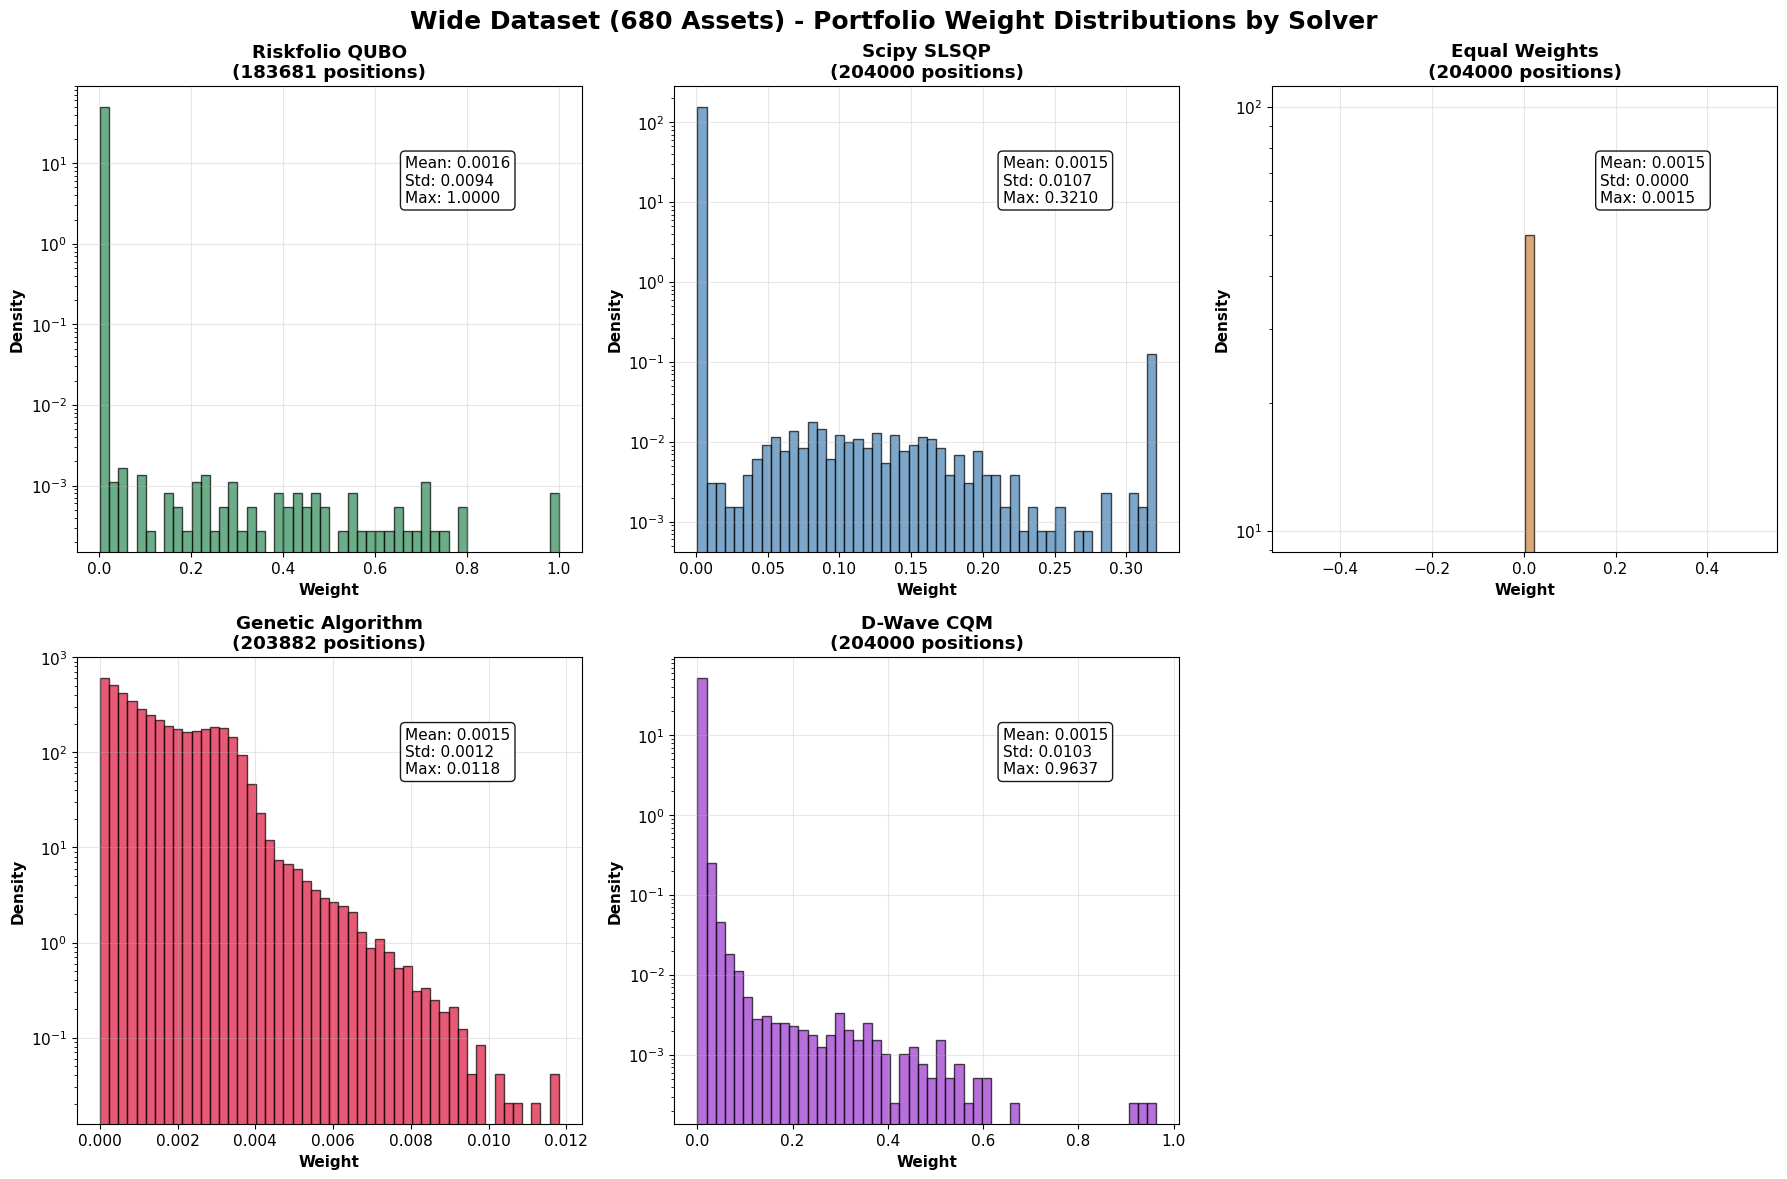


WIDE DATASET - WEIGHT ALLOCATION CONCENTRATION ANALYSIS
\nWeight Concentration Metrics:
--------------------------------------------------------------------------------
\nRiskfolio QUBO:
  Total positions: 183681
  Mean weight: 0.001633 (0.1633%)
  Max weight: 1.000000 (100.0000%)
  Gini coefficient: 0.0996 (0=equal, 1=concentrated)
  Top 1 position: 0.33% of portfolio
  Top 5 positions: 1.53% of portfolio
  Top 10 positions: 2.73% of portfolio
  Top 20 positions: 4.84% of portfolio
  Top 50 positions: 8.74% of portfolio
\nScipy SLSQP:
  Total positions: 204000
  Mean weight: 0.001471 (0.1471%)
  Max weight: 0.321000 (32.1000%)
  Gini coefficient: 0.3194 (0=equal, 1=concentrated)
  Top 1 position: 0.11% of portfolio
  Top 5 positions: 0.54% of portfolio
  Top 10 positions: 1.07% of portfolio
  Top 20 positions: 2.14% of portfolio
  Top 50 positions: 5.35% of portfolio
\nEqual Weights:
  Total positions: 204000
  Mean weight: 0.001471 (0.1471%)
  Max weight: 0.001471 (0.1471%)
  Gini c

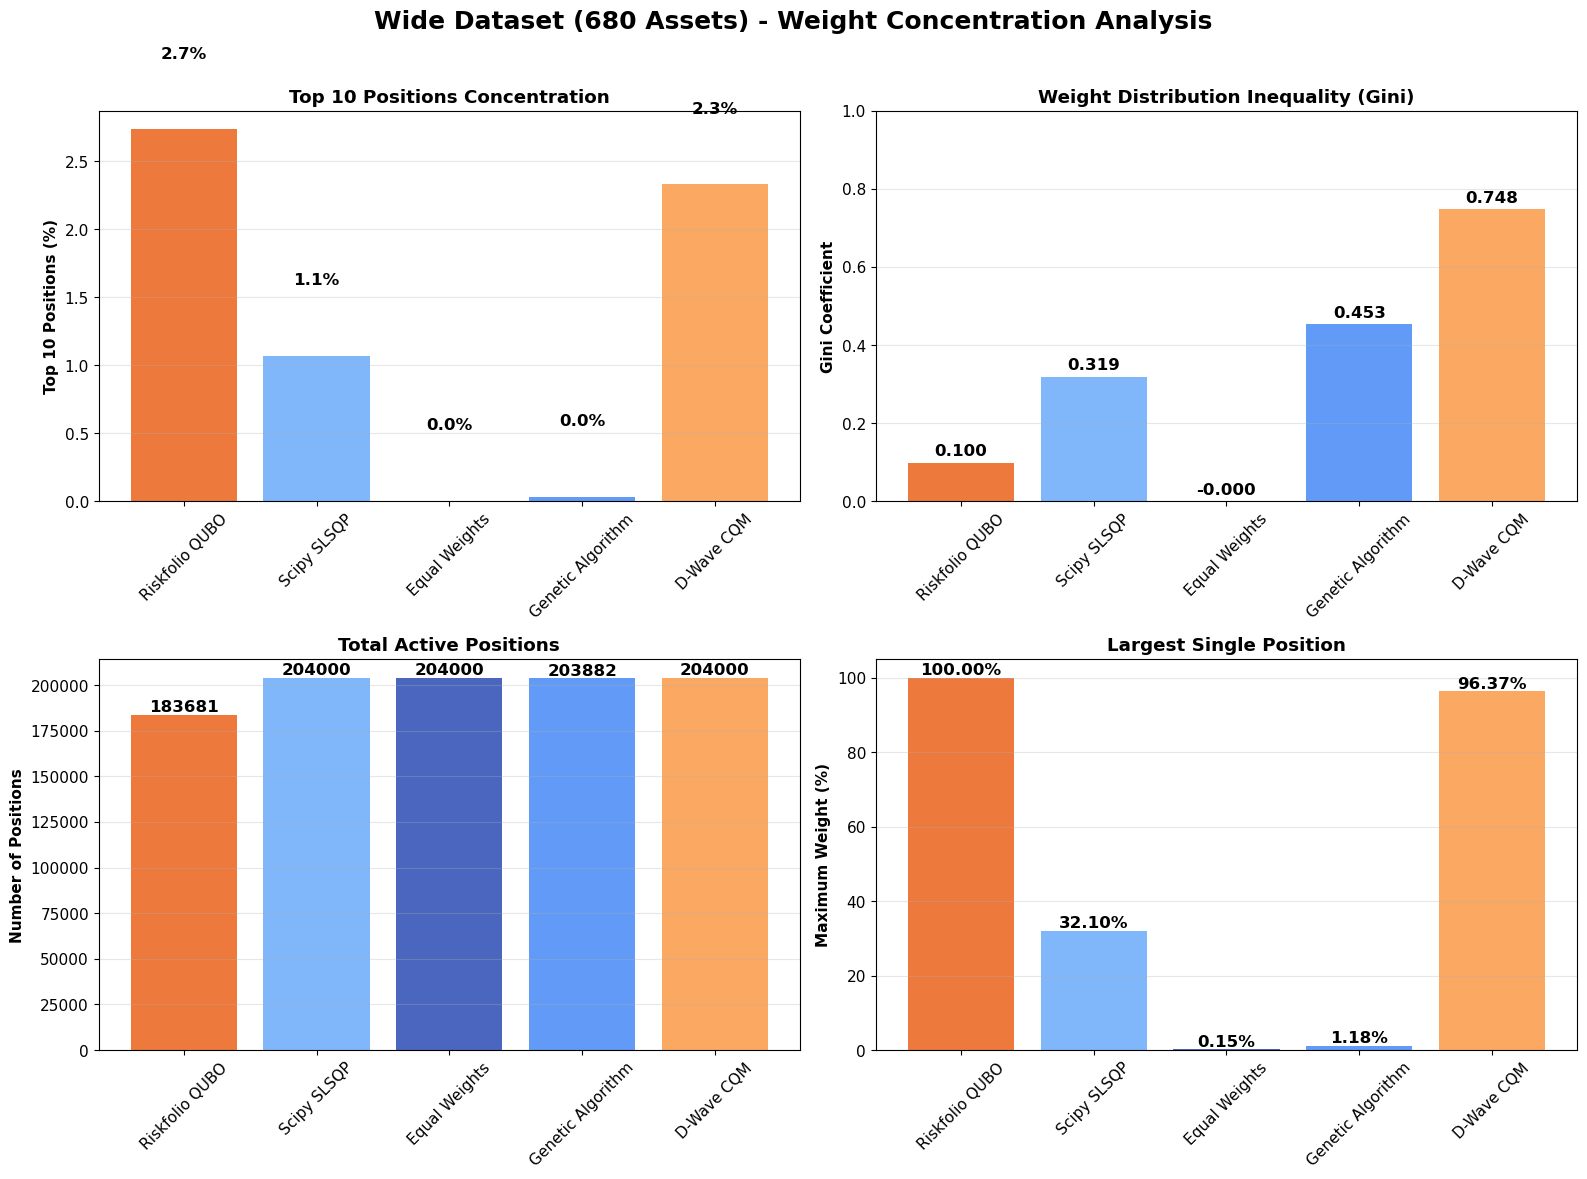

\n====================================================================================================
WIDE DATASET WEIGHT DISTRIBUTION INSIGHTS
Most diversified (lowest Gini): Equal Weights
Most concentrated (highest Gini): D-Wave CQM
Most positions: Scipy SLSQP (204000 positions)
Fewest positions: Riskfolio QUBO (183681 positions)
Lowest top-10 concentration: Equal Weights (0.0%)
Highest top-10 concentration: Riskfolio QUBO (2.7%)
\n========================================================================================================================
WIDE DATASET WEIGHT DISTRIBUTION ANALYSIS COMPLETE


In [18]:
# Comprehensive Weight Distribution Analysis for Wide Dataset
print("=" * 120)
print("WIDE DATASET (680 ASSETS) - COMPREHENSIVE WEIGHT DISTRIBUTION ANALYSIS")
print("=" * 120)

# Use the existing function to create comprehensive weight distribution plots for wide dataset
weights_wide_comprehensive = plot_weight_distribution_histograms(df_wide, "Wide Dataset (680 Assets)", bins=50)

if weights_wide_comprehensive:
    print("\n" + "=" * 100)
    print("WIDE DATASET - WEIGHT ALLOCATION CONCENTRATION ANALYSIS")
    print("=" * 100)
    
    # Analyze concentration of weights for each solver
    concentration_analysis = []
    
    for solver_name, weights in weights_wide_comprehensive.items():
        weights_array = np.array(weights)
        weights_sorted = np.sort(weights_array)[::-1]  # Sort in descending order
        total_weight = np.sum(weights_array)
        n_positions = len(weights_array)
        
        # Calculate concentration metrics
        concentration_metrics = {
            'Solver': solver_name,
            'Total_Positions': n_positions,
            'Total_Weight': total_weight,
            'Mean_Weight': np.mean(weights_array),
            'Median_Weight': np.median(weights_array),
            'Max_Weight': np.max(weights_array),
            'Min_Weight': np.min(weights_array),
            'Std_Weight': np.std(weights_array),
        }
        
        # Top N concentration metrics
        for n in [1, 5, 10, 20, 50, 100]:
            if len(weights_sorted) >= n:
                top_n_sum = np.sum(weights_sorted[:n])
                concentration_metrics[f'Top_{n}_Weight'] = top_n_sum
                concentration_metrics[f'Top_{n}_Percent'] = (top_n_sum / total_weight) * 100 if total_weight > 0 else 0
        
        # Gini coefficient (measure of inequality)
        if len(weights_array) > 1:
            # Sort weights in ascending order for Gini calculation
            weights_asc = np.sort(weights_array)
            n = len(weights_asc)
            index = np.arange(1, n + 1)
            gini = (2 * np.sum(index * weights_asc)) / (n * np.sum(weights_asc)) - (n + 1) / n
            concentration_metrics['Gini_Coefficient'] = gini
        else:
            concentration_metrics['Gini_Coefficient'] = 0
        
        concentration_analysis.append(concentration_metrics)
    
    # Create concentration DataFrame
    df_concentration = pd.DataFrame(concentration_analysis)
    
    # Display concentration analysis
    print("\\nWeight Concentration Metrics:")
    print("-" * 80)
    for _, row in df_concentration.iterrows():
        print(f"\\n{row['Solver']}:")
        print(f"  Total positions: {row['Total_Positions']}")
        print(f"  Mean weight: {row['Mean_Weight']:.6f} ({row['Mean_Weight']*100:.4f}%)")
        print(f"  Max weight: {row['Max_Weight']:.6f} ({row['Max_Weight']*100:.4f}%)")
        print(f"  Gini coefficient: {row['Gini_Coefficient']:.4f} (0=equal, 1=concentrated)")
        
        # Display top N concentrations
        if 'Top_1_Percent' in row:
            print(f"  Top 1 position: {row['Top_1_Percent']:.2f}% of portfolio")
        if 'Top_5_Percent' in row:
            print(f"  Top 5 positions: {row['Top_5_Percent']:.2f}% of portfolio")
        if 'Top_10_Percent' in row:
            print(f"  Top 10 positions: {row['Top_10_Percent']:.2f}% of portfolio")
        if 'Top_20_Percent' in row:
            print(f"  Top 20 positions: {row['Top_20_Percent']:.2f}% of portfolio")
        if 'Top_50_Percent' in row:
            print(f"  Top 50 positions: {row['Top_50_Percent']:.2f}% of portfolio")
    
    # Create concentration comparison visualizations
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Wide Dataset (680 Assets) - Weight Concentration Analysis', fontsize=18, fontweight='bold')
    
    solver_colors = {
        'Equal Weights': '#1E40AF',
        'Genetic Algorithm': '#3B82F6',
        'Scipy SLSQP': '#60A5FA',
        'Riskfolio QUBO': '#EA580C',
        'D-Wave CQM': '#FB923C'
    }
    
    # 1. Top 10 concentration comparison
    if 'Top_10_Percent' in df_concentration.columns:
        colors_top10 = [solver_colors.get(solver, '#000000') for solver in df_concentration['Solver']]
        bars1 = ax1.bar(df_concentration['Solver'], df_concentration['Top_10_Percent'], 
                       color=colors_top10, alpha=0.8)
        ax1.set_ylabel('Top 10 Positions (%)', fontweight='bold')
        ax1.set_title('Top 10 Positions Concentration', fontweight='bold')
        ax1.tick_params(axis='x', rotation=45)
        ax1.grid(True, alpha=0.3, axis='y')
        
        for bar, value in zip(bars1, df_concentration['Top_10_Percent']):
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{value:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    # 2. Gini coefficient comparison
    colors_gini = [solver_colors.get(solver, '#000000') for solver in df_concentration['Solver']]
    bars2 = ax2.bar(df_concentration['Solver'], df_concentration['Gini_Coefficient'], 
                   color=colors_gini, alpha=0.8)
    ax2.set_ylabel('Gini Coefficient', fontweight='bold')
    ax2.set_title('Weight Distribution Inequality (Gini)', fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_ylim(0, 1)
    
    for bar, value in zip(bars2, df_concentration['Gini_Coefficient']):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    # 3. Number of positions comparison
    colors_pos = [solver_colors.get(solver, '#000000') for solver in df_concentration['Solver']]
    bars3 = ax3.bar(df_concentration['Solver'], df_concentration['Total_Positions'], 
                   color=colors_pos, alpha=0.8)
    ax3.set_ylabel('Number of Positions', fontweight='bold')
    ax3.set_title('Total Active Positions', fontweight='bold')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3, axis='y')
    
    for bar, value in zip(bars3, df_concentration['Total_Positions']):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{int(value)}', ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    # 4. Maximum weight comparison
    colors_max = [solver_colors.get(solver, '#000000') for solver in df_concentration['Solver']]
    bars4 = ax4.bar(df_concentration['Solver'], df_concentration['Max_Weight'] * 100, 
                   color=colors_max, alpha=0.8)
    ax4.set_ylabel('Maximum Weight (%)', fontweight='bold')
    ax4.set_title('Largest Single Position', fontweight='bold')
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3, axis='y')
    
    for bar, value in zip(bars4, df_concentration['Max_Weight'] * 100):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{value:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Summary insights
    print("\\n" + "=" * 100)
    print("WIDE DATASET WEIGHT DISTRIBUTION INSIGHTS")
    print("=" * 100)
    
    most_diversified = df_concentration.loc[df_concentration['Gini_Coefficient'].idxmin(), 'Solver']
    most_concentrated = df_concentration.loc[df_concentration['Gini_Coefficient'].idxmax(), 'Solver']
    most_positions = df_concentration.loc[df_concentration['Total_Positions'].idxmax(), 'Solver']
    least_positions = df_concentration.loc[df_concentration['Total_Positions'].idxmin(), 'Solver']
    
    print(f"Most diversified (lowest Gini): {most_diversified}")
    print(f"Most concentrated (highest Gini): {most_concentrated}")
    print(f"Most positions: {most_positions} ({df_concentration.loc[df_concentration['Total_Positions'].idxmax(), 'Total_Positions']} positions)")
    print(f"Fewest positions: {least_positions} ({df_concentration.loc[df_concentration['Total_Positions'].idxmin(), 'Total_Positions']} positions)")
    
    if 'Top_10_Percent' in df_concentration.columns:
        lowest_top10 = df_concentration.loc[df_concentration['Top_10_Percent'].idxmin(), 'Solver']
        highest_top10 = df_concentration.loc[df_concentration['Top_10_Percent'].idxmax(), 'Solver']
        print(f"Lowest top-10 concentration: {lowest_top10} ({df_concentration.loc[df_concentration['Top_10_Percent'].idxmin(), 'Top_10_Percent']:.1f}%)")
        print(f"Highest top-10 concentration: {highest_top10} ({df_concentration.loc[df_concentration['Top_10_Percent'].idxmax(), 'Top_10_Percent']:.1f}%)")

else:
    print("No weight distribution data available for wide dataset")

print("\\n" + "=" * 120)
print("WIDE DATASET WEIGHT DISTRIBUTION ANALYSIS COMPLETE")
print("=" * 120)